### Unsupervised Learning

Most of this book concerns **supervised learning** methods such as regression and classification. In the supervised learning setting, we typically have access to a set of p features $X_1, X_2, \ldots, X_p$ and observations $y$ and a response $Y$ also measured on those same observations.

This chapter will introduce tools on **unsupervised learning**, a set of statistical tools intended for the setting in which we have only a set of features $X_1, X_2, \ldots, X_p$ measured on n observations. We are not directly interested in $y$ because we do not have answers to our questions. Rather, the goal is to discover insights about the measurements on $X_1, X_2, \ldots, X_p$.

Unsupervised learning refers to situations in which we are looking for underlying structures among the variables or among the observations. Unsupervised learning has many applications, and we will cover two types of unsupervised learning: **principal components analysis**, which is used for data visualization or for data pre-processing, and **supervised techniques** are applied, for example, to discover unknown subgroups in data.



#### The Challenge of Unsupervised Learning

Supervised learning is a well-understood area. In fact, if you have read the preceding chapters in this book, then you should by now have a good grasp of supervised learning. For instance, if you are asked to predict a binary outcome from a data set, you have a very well developed set of tools
at your disposal (such as logistic regression, linear discriminant analysis, classification trees, support vector machines, and more) as well as a clear Understanding how to assess the quality of the results obtained (using cross-validation, validation on an independent test set, and so forth) is crucial. In contrast, **unsupervised learning** is often much more challenging. The exercise tends to be more subjective, and there is no simple goal for the analysis, such as prediction of a response. Unsupervised learning is often performed as part of an exploratory data analysis.

Furthermore, it can be hard to assess the results obtained from unsupervised learning methods since there is no universally accepted mechanism for performing cross-validation or validating results on an independent data set. The reason for this difference is simple: if we fit a predictive model using a supervised learning technique, we can check our work by seeing how well our model predicts the response $ Y $ on observations not used in fitting the model. However, in unsupervised learning, there is no way to check our work because we don’t know the true answer—the problem is unsupervised.

Techniques for unsupervised learning are of growing importance in a number of fields. A cancer researcher might assay gene expression levels in 100 patients with breast cancer. They might then look for subgroups among the breast cancer samples or among the genes to obtain a better understanding of the disease. An online shopping site might try to identify groups of shoppers with similar browsing and purchase histories, as well as items of particular interest to the shoppers within each group. Then, an individual shopper can be preferentially shown the items in which they are particularly likely to be interested, based on the purchase histories of similar shoppers. A search engine might choose which search results to display to a particular individual based on the click histories of others with similar search patterns. These statistical learning tasks, and many more, can be performed via unsupervised learning techniques.



#### Principal Components Analysis

Principal components are discussed in Section 6.3.1 in the context of principal components regression. When faced with a large set of correlated variables, principal components allow us to summarize this set with a smaller number of representative variables that collectively explain most of the variability in the original set. The principal component directions are presented in Section 6.3.1 as directions in feature space along which the original data are highly variable. These directions also define lines and subspaces that are as close as possible to the data cloud. To perform principal components regression, we simply use principal components as predictors in a regression model in place of the original larger set of variables.

Principal Components Analysis (PCA) refers to the process by which principal components are computed and the subsequent use of these components in understanding the data. PCA is an unsupervised approach, since it involves only a set of features $ X_1, X_2, \ldots, X_p $, and no associated response $ Y $. Apart from producing derived variables for use in supervised learning problems, PCA also serves as a tool for data visualization of the observations or visualization of the variables can also be used as a tool for data imputation—that is, for filling in missing values in a data matrix. We now discuss PCA in greater detail, focusing on the use of PCA as a tool for unsupervised data exploration, in keeping with the topic of this chapter.


##### What Are Principal Components?



Suppose that we wish to visualize $ n $ observations with measurements on a set of $ p $ features, $ X_1, X_2, \ldots, X_p $, as part of an exploratory data analysis. We could do this by examining two-dimensional scatterplots of the data, each of which contains the $ n $ observations’ measurements on two of the features. However, there are 

$$
\frac{p(p - 1)}{2}
$$

such scatterplots; for example, with $ p = 10 $, there are 45 plots! If $ p $ is large, it will certainly not be possible to look at all of them; moreover, most likely none of them will be informative since they each contain just a small fraction of the total information present in the data set. Clearly, a better method is required to visualize the $ n $ observations when $ p $ is large. In particular, we would like to find a low-dimensional representation of the data that captures as much of the information as possible. For instance, if we can obtain a two-dimensional representation of the data that captures most of the information, then we can plot the observations in this low-dimensional space.

PCA provides a tool to do just this. It finds a low-dimensional representation of a data set that contains as much as possible of the variation. The idea is that each of the $ n $ observations lives in $ p $-dimensional space, but not all of these dimensions are equally interesting. PCA seeks a small number of dimensions that are as interesting as possible, where the concept of "interesting" is measured by the amount that the observations vary along each dimension. Each of the dimensions found by PCA is a linear combination of the $ p $ features. We now explain how these dimensions, or principal components, are found.

The first principal component of a set of features $ X_1, X_2, \ldots, X_p $ is the normalized linear combination of the features

$$
Z_1 = \phi_{11}X_1 + \phi_{21}X_2 + \cdots + \phi_{p1}X_p
$$

that has the largest variance. By "normalized," we mean that 

$$
\sum_{j=1}^p \phi_{j1}^2 = 1.
$$

We refer to the elements $ \phi_{11}, \ldots, \phi_{p1} $ as the loadings of the first principal component; together, the loadings make up the principal component loading vector, $ \boldsymbol{\phi_1} = (\phi_{11}, \phi_{21}, \ldots, \phi_{p1})^T $. We constrain the loadings so that their sum of squares is equal to one since otherwise setting these elements to be arbitrarily large in absolute value could result in an arbitrarily large variance.

Given an $ n \times p $ data set $ X $, how do we compute the first principal component? Since we are only interested in variance, we assume that each of the variables in $ X $ has been centered to have mean zero (that is, the column means of $ X $ are zero). We then look for the linear combination of the sample feature values of the form

$$
z_{i1} = \phi_{11}x_{i1} + \phi_{21}x_{i2} + \cdots + \phi_{p1}x_{ip}.
$$

that has the largest sample variance, subject to the constraint that 

$$
\sum_{j=1}^p \phi_{j1}^2 = 1.
$$

In other words, the first principal component loading vector solves the optimization problem:

$$
\begin{array}{rl}
\text{maximize} & \phi_{11}, \ldots, \phi_{p1} \\
\text{subject to} & \sum_{j=1}^p \phi_{j1}^2 = 1.
\end{array}
$$

From (12.2), we can write the objective in (12.3) as 

$$
\frac{1}{n} \sum_{i=1}^n z_{i1}^2.
$$

Since 

$$
\frac{1}{n} \sum_{i=1}^n x_{ij} = 0,
$$

the average of the $ z_{11}, \ldots, z_{n1} $ will be zero as well. Hence, the objective that we are maximizing in (12.3) is just the sample variance of the $ n $ values of $ z_{i1} $. We refer to $ z_{11}, \ldots, z_{n1} $ as the scores of the first principal component. Problem (12.3) can be solved via an eigen decomposition, a standard technique in linear algebra, but the details are outside the scope of this book.

There is a nice geometric interpretation of the first principal component. The loading vector $ \boldsymbol{\phi_1} $ with elements $ \phi_{11}, \phi_{21}, \ldots, \phi_{p1} $ defines a direction in feature space along which the data vary the most. If we project the $ n $ data points $ \boldsymbol{x_1}, \ldots, \boldsymbol{x_n} $ onto this direction, the projected values are the principal component scores $ z_{11}, \ldots, z_{n1} $ themselves. For instance, Figure 6.14 on page 254 displays the first principal component loading vector (green solid line) on an advertising data set. In these data, there are only two features, and so the observations, as well as the first principal component loading vector, can be easily displayed. As can be seen from (6.19), in that data set $ \phi_{11} = 0.839 $ and $ \phi_{21} = 0.544 $.

After the first principal component $ Z_1 $ of the features has been determined, we can find the second principal component $ Z_2 $. The second principal component is the linear combination of $ X_1, \ldots, X_p $ that has maximal variance out of all linear combinations that are uncorrelated with $ Z_1 $. The second principal component scores $ z_{12}, z_{22}, \ldots, z_{n2} $ take the form

$$
z_{i2} = \phi_{12} x_{i1} + \phi_{22} x_{i2} + \cdots + \phi_{p2} x_{ip},
$$

where $ \boldsymbol{\phi_2} $ is the second principal component loading vector, with elements $ \phi_{12}, \phi_{22}, \ldots, \phi_{p2} $. It turns out that constraining $ Z_2 $ to be uncorrelated with $ Z_1 $ is equivalent to constraining the direction $ \boldsymbol{\phi_2} $ to be orthogonal (perpendicular) to the direction $ \boldsymbol{\phi_1} $. In the example in Figure 6.14, the observations lie in two-dimensional space (since $ p = 2 $), and so once we have found $ \boldsymbol{\phi_1} $, there is only one possibility for $ \boldsymbol{\phi_2} $, which is shown as a blue dashed line. (From Section 6.3.1, we know that $ \phi_{12} = 0.544 $ and $ \phi_{22} = 0.839 $.) But in a larger data set with $ p > 2 $ variables, there are multiple distinct principal components, and they are defined in a similar manner. To find $ \boldsymbol{\phi_2} $, we solve a problem similar to (12.3) with $ \boldsymbol{\phi_2} $ replacing $ \boldsymbol{\phi_1} $, and with the additional constraint that $ \boldsymbol{\phi_2} $ is orthogonal to $ \boldsymbol{\phi_1} $.

Once we have computed the principal components, we can plot them against each other in order to produce low-dimensional views of the data. For instance, we can plot the score vector $ Z_1 $ against $ Z_2 $, $ Z_1 $ against $ Z_3 $, $ Z_2 $ against $ Z_3 $, and so forth. Geometrically, this amounts to projecting the original data down onto the subspace spanned by $ \phi_1, \phi_2, $ and $ \phi_3 $, and plotting the projected points.

We illustrate the use of PCA on the **USArrests** data set. For each of the 50 states in the United States, the data set contains the number of arrests per 100,000 residents for each of three crimes: Assault, Murder, and Rape. We also record UrbanPop (the percent of the population in each state living in urban areas). The principal component score vectors have length $ n = 50 $, and the principal component loading vectors have length $ p = 4 $. PCA was performed after standardizing each variable to have mean zero and standard deviation one deviation one. Figure 12.1 plots the first two principal components of these data. The figure represents both the principal component scores and the loading vectors in a single biplot display. The loadings are also given in biplot Table 12.2.1.

|             |     $PC1$    |     $PC2$    |
|-------------|------------|------------|
| `Murder`      | 0.5358995  | -0.4181809 |
| `Assault`     | 0.5831836  | -0.1879856 |
| `UrbanPop`    | 0.2781909  |  0.8728062 |
| `Rape`        | 0.5434321  |  0.1673186 |

**TABLE 12.1.** The principal component loading vectors, $ \phi_1 $ and $ \phi_2 $, for the **USArrests** data. These are also displayed in Figure 12.1.



In Figure 12.1, we see that the first loading vector places approximately equal weight on Assault, Murder, and Rape, but with much less weight on UrbanPop. Hence, this component roughly corresponds to a measure of overall rates of serious crimes. The second loading vector places most of its weight on UrbanPop and much less weight on the other three features. Hence, this component roughly corresponds to the level of urbanization of the state.

Overall, we see that the crime-related variables (Murder, Assault, and Rape) are located close to each other, and that the UrbanPop variable is far from the other three. This indicates that the crime-related variables are correlated with each other—states with high murder rates tend to have high assault and rape rates—and that the UrbanPop variable is less correlated with the other three.

We can examine differences between the states via the two principal component score vectors shown in Figure 12.1. Our discussion of the loading vectors suggests that states with large positive scores on the first component, such as California, Nevada, and Florida, have high crime rates, while states like North Dakota, with negative scores on the first component, have low crime rates. California also has a high score on the second component, indicating a high level of urbanization, while the opposite is true for states like Mississippi. States close to zero on both components, such as Indiana, have approximately average levels of both crime and urbanization.



##### Another Interpretation of Principal Components



The first two principal component loading vectors in a simulated three-dimensional data set are shown in the left-hand panel of Figure 12.2; these two loading vectors span a plane along which the observations have the highest variance.

In the previous section, we described the principal component loading vectors as the directions in feature space along which the data vary the most, and the principal component scores as projections along these directions. However, an alternative interpretation of principal components can also be useful: principal components provide low-dimensional linear surfaces that are closest to the observations. We expand upon that interpretation here. 

The first principal component loading vector has a very special property: it is the line in $ p $-dimensional space that is closest to the $ n $ observations (using average squared Euclidean distance as a measure of closeness). This interpretation can be seen in the left-hand panel of Figure 6.15; the dashed lines indicate the distance between each observation and the line defined by the first principal component loading vector. The appeal of this interpretation is clear: we seek a single dimension of the data that lies as close as possible to all of the data points, since such a line will likely provide a good summary of the data.

The notion of principal components as the dimensions that are closest to the $ n $ observations extends beyond just the first principal component. For instance, the first two principal components of a data set span the plane that is closest to the $ n $ observations, in terms of average squared Euclidean distance. An example is shown in the left-hand panel of Figure 12.2. The first three principal components of a data set span the three-dimensional hyperplane that is closest to the $ n $ observations, and so forth.

Using this interpretation, together the first $ M $ principal component score vectors and the first $ M $ principal component loading vectors provide the best $ M $-dimensional approximation (in terms of Euclidean distance) to The $ i $ th observation $ x_{ij} $. This representation can be written as 

$$
x_{ij} = \sum_{m=1}^M z_{im} \gamma_{jm}.
$$

We can state this more formally by writing down an optimization problem. Suppose the data matrix $ X $ is column-centered. Out of all approximations of the form 

$$
x_{ij} = \sum_{m=1}^M a_{im} b_{jm},
$$

we could ask for the one with the smallest residual sum of squares:

$$
\min_{A \in \mathbb{R}^{n \times M}, B \in \mathbb{R}^{p \times M}} \sum_{j=1}^p \sum_{i=1}^n \left( x_{ij} - \sum_{m=1}^M a_{im} b_{jm} \right)^2.
$$

Here, $ A $ is an $ n \times M $ matrix whose $ (i,m) $ element is $ a_{im} $, and $ B $ is a $ p \times M $ matrix whose $ (j,m) $ element is $ b_{jm} $.

It can be shown that for any value of $ M $, the columns of the matrices $ \hat{A} $ and $ \hat{B} $ that solve the above optimization problem are in fact the first $ M $ principal components score and loading vectors. In other words, if $ \hat{A} $ and $ \hat{B} $ solve the optimization problem, then $ \hat{a}_{im} = z_{im} $ and $ \hat{b}_{jm} = \gamma_{jm} $. This means that the smallest possible value of the objective is 

$$
\sum_{j=1}^p \sum_{i=1}^n \left( x_{ij} - \sum_{m=1}^M z_{im} \gamma_{jm} \right)^2.
$$

In summary, together the $ M $ principal component score vectors and $ M $ principal component loading vectors can give a good approximation to the data when $ M $ is sufficiently large. When $ M = \min(n-1, p) $, then the representation is exact: 

$$
x_{ij} = \sum_{m=1}^M z_{im} \gamma_{jm}.
$$



##### The Proportion of Variance Explained



In Figure 12.2, we performed PCA on a three-dimensional data set (left-hand panel) and projected the data onto the first two principal component loading vectors in order to obtain a two-dimensional view of the data (i.e., the principal component score vectors; right-hand panel). We see that this two-dimensional representation of the three-dimensional data does successfully capture the major patterns in the data: the orange, green, and cyan observations that are near each other in three-dimensional space remain nearby in the two-dimensional representation. Similarly, we have seen in the **USArrests** data set that we can summarize the 50 observations and 4 variables using just the first two principal component score vectors and the first two principal component loading vectors.

We can now ask a natural question: how much of the information in a given data set is lost by projecting the observations onto the first few principal components? That is, how much of the variance in the data is not contained in the first few principal components? More generally, we are interested in knowing the proportion of variance explained (PVE) by each ## Principal Component

The total variance present in a dataset (assuming that the variables have been centered to have mean zero) is defined as 

$$
\sum_{j=1}^p \text{Var}(X_j) = \sum_{j=1}^p \frac{1}{n} \sum_{i=1}^n x_{ij}^2. \tag{12.8}
$$

The variance explained by the $ m $-th principal component is 

$$
\frac{1}{n} \sum_{i=1}^n z_{im}^2 = \frac{1}{n} \sum_{i=1}^n \left( \sum_{j=1}^p \gamma_{jm} x_{ij} \right)^2. \tag{12.9}
$$

Therefore, the PVE of the $ m $-th principal component is given by 

$$
\frac{\sum_{i=1}^n z_{im}^2}{\sum_{j=1}^p \sum_{i=1}^n x_{ij}^2} = \frac{\sum_{i=1}^n \left( \sum_{j=1}^p \gamma_{jm} x_{ij} \right)^2}{\sum_{j=1}^p \sum_{i=1}^n x_{ij}^2}. \tag{12.10}
$$

The PVE of each principal component is a positive quantity. In order to compute the cumulative PVE of the first $ M $ principal components, we can simply sum (12.10) over each of the first $ M $ PVEs. In total, there are $ \min(n-1, p) $ principal components, and their PVEs sum to one.

In Section 12.2.2, we showed that the first $ M $ principal component loading and score vectors can be interpreted as the best $ M $-dimensional approximation to the data, in terms of residual sum of squares. It turns out that the variance of the data can be decomposed into the variance of the first $ M $ principal components plus the mean squared error of this $ M $-dimensional approximation, as follows:

$$
\sum_{j=1}^p \frac{1}{n} \sum_{i=1}^n x_{ij}^2 = \sum_{m=1}^M \frac{1}{n} \sum_{i=1}^n z_{im}^2 + \frac{1}{n} \sum_{j=1}^p \sum_{i=1}^n \left( x_{ij} - \sum_{m=1}^M z_{im} \gamma_{jm} \right)^2. \tag{12.11}
$$

The three terms in this decomposition are discussed in (12.8), (12.9), and (12.7), respectively. Since the first term is fixed, we see that by maximizing the variance of the first $ M $ principal components, we minimize the mean squared error of the $ M $-dimensional approximation, and vice versa. This explains why principal components can be equivalently viewed as minimizing the approximation error (as in Section 12.2.2) or maximizing the variance (as in Section 12.2.1).

Moreover, we can use (12.11) to see that the PVE defined in (12.10) equals 

$$
\frac{\sum_{j=1}^p \sum_{i=1}^n x_{ij} - \sum_{m=1}^M z_{im} \gamma_{jm}}{\sum_{j=1}^p \sum_{i=1}^n x_{ij}^2} = 1 - \frac{\text{RSS}}{\text{TSS}},
$$

where TSS represents the total sum of squared elements of $ X $, and RSS represents the residual sum of squares of the $ M $-dimensional approximation given by the principal components. Recalling the definition of $ R^2 $ from (3.17), this means that we can interpret the PVE as the $ R^2 $ of the approximation for $ X $ given by the first $ M $ principal components.

In the `USArrests` data, the first principal component explains 62.0% of the variance in the data, and the next principal component explains 24.7% of the variance. Together, the first two principal components explain almost 87% of the variance in the data, while the last two principal components explain only 13% of the variance. This means that Figure 12.1 provides a pretty accurate summary of the data using just two dimensions. The PVE of each principal component, as well as the cumulative PVE, is shown in Figure 12.3. The left-hand panel is known as a scree plot, which will be discussed later in this chapter.


##### More on PCA


Scaling the Variables

We have already mentioned that before PCA is performed, the variables should be centered to have mean zero. Furthermore, the results obtained when we perform PCA will also depend on whether the variables have been individually scaled (each multiplied by a different constant). This contrasts with some other supervised and unsupervised learning techniques, such as linear regression, in which scaling the variables has no effect. (In linear regression, multiplying a variable by a factor of $c$ will simply lead to multiplication of the corresponding coefficient estimate by a factor of $1/c$, thus having no substantive effect on the model obtained.)

For instance, Figure 12.1 was obtained after scaling each of the variables to have standard deviation one. This is reproduced in the left-hand plot in Figure 12.4. Why does it matter that we scaled the variables? In these data, the variables are measured in different units; `Murder`, `Rape`, and `Assault` are reported as the number of occurrences per 100,000 people, and `UrbanPop` is the percentage of the state’s population that lives in an urban area. These four variables have variances of 18.97, 87.73, 6945.16, and 209.5, respectively. Consequently, if we perform PCA on the unscaled variables, then The first principal component loading vector will have a very large loading for Assault, since that variable has by far the highest variance. The right-hand plot in Figure 12.4 displays the first two principal components for the `USArrests` data set, without scaling the variables to have standard deviation one. As predicted, the first principal component loading vector places almost all of its weight on Assault, while the second principal component loading vector places almost all of its weight on UrbanPop. Comparing this to the left-hand plot, we see that scaling does indeed have a substantial effect on the results obtained.

However, this result is simply a consequence of the scales on which the variables were measured. For instance, if Assault were measured in units of the number of occurrences per 100 people (rather than the number of occurrences per 100,000 people), then this would amount to dividing all of the elements of that variable by 1,000. The variance of the variable would be tiny, and thus the first principal component loading vector would have a very small value for that variable. Because it is undesirable for the principal components obtained to depend on an arbitrary choice of scaling, we typically scale each variable to have standard deviation one before we perform PCA.

In certain settings, however, the variables may be measured in the same units. In this case, we might not wish to scale the variables to have standard deviation one before performing PCA. For instance, suppose that the variables in a given data set correspond to expression levels for $ p $ genes. Then, since expression is measured in the same "units" for each gene, we might choose not to scale the genes to each have standard deviation one.

Uniqueness of the Principal Components

While in theory the principal components need not be unique, in almost all practical settings they are (up to sign flips). This means that two different software packages will yield the same principal component loading vectors, although the signs of those loading vectors may differ. The signs may differ because each principal component loading vector specifies a direction in $ p $-dimensional space: flipping the sign has no effect as the direction does not change. (Consider Figure 6.14—the principal component loading vector is a line that extends in either direction, and flipping its sign would have no effect.) Similarly, the score vectors are unique up to a sign flip since the variance of $ Z $ is the same as the variance of $ Z $. It is worth noting that when we use (12.5) to approximate $ x_{ij} $, we multiply $ z_{im} $ by $ \gamma_{jm} $. Hence, if the sign is flipped on both the loading and score vectors, the final product of the two quantities is unchanged.

Deciding How Many Principal Components to Use

In general, an $ n \times p $ data matrix $ X $ has $ \min(n-1, p) $ distinct principal components. However, we usually are not interested in all of them; rather, we would like to use just the first few principal components in order to visualize or interpret the data. In fact, we would like to use the smallest number of principal components required to get a good understanding of the data. How many principal components are needed? Unfortunately, there is no single (or simple!) answer to this question.

We typically decide on the number of principal components required to visualize the data by examining a scree plot, such as the one shown in the left-hand panel of Figure 12.3. We choose the smallest number of principal components that are required in order to explain a sizable amount of the variation in the data. This is done by eyeballing the scree plot and looking for a point at which the proportion of variance explained by each subsequent principal component drops off. This drop is often referred to as an elbow in the scree plot. For instance, by inspection of Figure 12.3, one might conclude that a fair amount of variance is explained by the first two principal components, and that there is an elbow after the second component. After all, the third principal component explains less than ten percent of the variance in the data, and the fourth principal component explains less than half that and so is essentially worthless.

However, this type of visual analysis is inherently ad hoc. Unfortunately, there is no well-accepted objective way to decide how many principal components are enough. In fact, the question of how many principal components are enough is inherently ill-defined and will depend on the specific area of application and the specific data set. In practice, we tend to look at the first few principal components in order to find interesting patterns in the data. If no interesting patterns are found in the first few principal components, then further principal components are unlikely to be of interest. Conversely, if the first few principal components are interesting, then we typically continue to look at subsequent principal components until no further interesting patterns are found. This is admittedly a subjective approach, and is reflective of the fact that PCA is generally used as a tool for exploratory data analysis.

On the other hand, if we compute principal components for use in a supervised analysis, such as the principal components regression presented in Section 6.3.1, then there is a simple and objective way to determine how many principal components to use: we can treat the number of principal component score vectors to be used in the regression as a tuning parameter to be selected via cross-validation or a related approach. The comparative simplicity of selecting the number of principal components for a supervised analysis is one manifestation of the fact that supervised analyses tend to be more clearly defined and more objectively evaluated than unsupervised analyses.



##### Other Uses for Principal Components



We saw in Section 6.3.1 that we can perform regression using the principal component score vectors as features. In fact, many statistical techniques, such as regression, classification, and clustering, can be easily adapted to use the $ n \times M $ matrix whose columns are the first $ M $ principal component score vectors, rather than using the full $ n \times p $ data matrix. This can lead to less noisy results, since it is often the case that the signal (as opposed to the noise) in a data set is concentrated in its first few principal components.



#### Missing Values and Matrix Completion



Often datasets have missing values, which can be a nuisance. For example, suppose that we wish to analyze the **USArrests** data and discover that 20 of the 200 values have been randomly corrupted and marked as missing. Unfortunately, the statistical learning methods that we have seen in this book cannot handle missing values. How should we proceed?

We could remove the rows that contain missing observations and perform our data analysis on the complete rows. But this seems wasteful, and depending on the fraction missing, unrealistic. Alternatively, if $ x_{ij} $ is missing, then we could replace it by the mean of the $ j $-th column (using the non-missing entries to compute the mean). Although this is a common and convenient strategy, often we can do better by exploiting the correlation between the variables.

In this section, we show how principal components can be used to impute the missing values through a process known as matrix completion. The completed matrix can then be used in a statistical learning method, such as linear regression or LDA.

This approach for imputing missing data is appropriate if the missingness is random. For example, it is suitable if a patient’s weight is missing because the battery of the electronic scale was flat at the time of his exam. By contrast, if the weight is missing because the patient was too heavy to climb on the scale, then this is not missing at random; the missingness is informative, and the approach described here for handling missing data is not suitable.

Sometimes data is missing by necessity. For example, if we form a matrix of the ratings (on a scale from 1 to 5) that $ n $ customers have given to the entire Netflix catalog of $ p $ movies, then most of the matrix will be missing, since no customer will have seen and rated more than a tiny fraction of the catalog. If we can impute the missing values well, then we will have an idea of what each customer will think of movies they have not yet seen. Hence, matrix completion can be used to power recommender systems.


Principal Components with Missing Values

In Section 12.2.2, we showed that the first $ M $ principal component score and loading vectors provide the “best” approximation to the data matrix $ X $, in the sense of (12.6). Suppose that some of the observations $ x_{ij} $ are missing. We now show how one can both impute the missing values and solve the principal component problem at the same time. We return to a modified form of the optimization problem (12.6),

$$
\min_{A \in \mathbb{R}^{n \times M}, B \in \mathbb{R}^{p \times M}} \sum_{(i,j) \in O} (x_{ij} - \sum_{m=1}^{M} a_{im} b_{jm})^2, \tag{12.12}
$$

where $ O $ is the set of all observed pairs of indices $ (i,j) $, a subset of the possible $ n \times p $ pairs.

Once we solve this problem:

- we can estimate a missing observation $ x_{ij} $ using 
  $$
  \hat{x}_{ij} = \sum_{m=1}^{M} \hat{a}_{im} \hat{b}_{jm},
  $$
  where $ \hat{a}_{im} $ and $ \hat{b}_{jm} $ are the $ (i,m) $ and $ (j,m) $ elements, respectively, of the matrices $ \hat{A} $ and $ \hat{B} $ that solve (12.12); and

- we can (approximately) recover the $ M $ principal component scores and loadings, as we did when the data were complete.

It turns out that solving (12.12) exactly is difficult, unlike in the case of complete data; the eigen decomposition no longer applies. But the simple iterative approach in Algorithm 12.1, which is demonstrated in Section 12.5.2, typically provides a good solution.

We illustrate Algorithm 12.1 on the **USArrests** data. There are $ p = 4 $ variables and $ n = 50 $ observations (states). We first standardized the data so each variable has mean zero and standard deviation one. We then randomly selected 20 of the 50 states, and then for each of these, we randomly set one of the four variables to be missing. Thus, 10% of the elements of the data matrix were missing. We applied Algorithm 12.1 with $ M = 1 $ principal component. Figure 12.5 shows that the recovery of the missing elements is pretty accurate. Over 100 random runs of this experiment, the average correlation between the true and imputed values of the missing elements is 0.63, with a standard deviation of 0.11. Is this good performance? To answer this question, we can compare this correlation to what we would have gotten if we had estimated these 20 values using the complete data—that is, if we had simply computed 
$\hat{x}_{ij} = z_{i_1 j_1}$, where $ z_{i_1} $ and $ j_1 $ are elements of the first principal component score and loading vectors of the complete data. Using the complete data in this way results in an average correlation of 0.79 between the true and estimated values for these 20 elements, with a standard deviation of 0.08. Thus, our imputation method does worse than the method that uses all of the data (0.63 ± 0.11 versus 0.79 ± 0.08), but its performance is still pretty good. (And of course, the method that uses all of the data cannot be applied in a real-world setting with missing data.) 

**Algorithm 12.1** $\text{Iterative Algorithm for Matrix Completion}$

---

1. Create a complete data matrix $ \tilde{X} $ of dimension $ n \times p $ of which the $ (i, j) $ element equals
   $$
   \tilde{x}_{ij} = 
   \begin{cases} 
   x_{ij} & \text{if } (i,j) \in O \\ 
   \bar{x}_j & \text{if } (i, j) \notin O,
   \end{cases}
   $$
   where $ \bar{x}_j $ is the average of the observed values for the $ j $-th variable in the incomplete data matrix $ X $. Here, $ O $ indexes the observations that are observed in $ X $.

2. Repeat steps (a)–(c) until the objective (12.14) fails to decrease:
   
   (a) Solve 
   $$
   \min_{A \in \mathbb{R}^{n \times M}, B \in \mathbb{R}^{p \times M}} \sum_{j=1}^{p} \sum_{i=1}^{n} \left( \tilde{x}_{ij} - \sum_{m=1}^{M} a_{im} b_{jm} \right)^2
   $$
     by computing the principal components of $ \tilde{X} $.
   
   (b) For each element $ (i,j) \notin O $, set 
   $$
   \tilde{x}_{ij} = \sum_{m=1}^{M} a_{im} b_{jm}.
   $$

   (c) Compute the objective 
   $$
   \sum_{(i,j) \in O} \sum_{m=1}^{M} \left( x_{ij} - \hat{a}_{im} \hat{b}_{jm} \right)^2.
   $$

3. Return the estimated missing entries $ \tilde{x}_{ij}, (i,j) \notin O $.
---


Figure 12.6 further indicates that Algorithm 12.1 performs fairly well on this dataset.

We close with a few observations:

- The `USArrests` data has only four variables, which is on the low end for methods like Algorithm 12.1 to work well. For this reason, for this demonstration we randomly set at most one variable per state to be missing, and only used $ M = 1 $ principal component.

- In general, in order to apply Algorithm 12.1, we must select $ M $, the number of principal components to use for the imputation. One approach is to randomly leave out a few additional elements from the matrix, and select $ M $ based on how well those known values are recovered. This is closely related to the validation-set approach seen in Chapter 5.


Recommender Systems

Digital streaming services like Netflix and Amazon use data about the content that a customer has viewed in the past, as well as data from other customers, to suggest other content for the customer. As a concrete example, some years back, Netflix had customers rate each movie that they had seen with a score from 1–5. This resulted in a very big $ n \times p $ matrix for which the $ (i,j) $ element is the rating given by the $ i $-th customer to the The  $\text{jth}$ movie. One specific early example of this matrix had $ n = 480,189 $ customers and $ p = 17,770 $ movies. However, on average each customer had seen around 200 movies, so 99% of the matrix had missing elements. Table 12.2 illustrates the setup.

In order to suggest a movie that a particular customer might like, Netflix needed a way to impute the missing values of this data matrix. The key idea is as follows: the set of movies that the $ i $-th customer has seen will overlap with those that other customers have seen. Furthermore, some of those other customers will have similar movie preferences to the $ i $-th customer. Thus, it should be possible to use similar customers’ ratings of movies that the $ i $-th customer has not seen to predict whether the $ i $-th customer will like those movies.

More concretely, by applying Algorithm 12.1, we can predict the $ i $-th customer’s rating for the $ j $-th movie using 
$$
\hat{x}_{ij} = \sum_{m=1}^{M} \hat{a}_{im} \hat{b}_{jm}.
$$
Furthermore, we can interpret the $ M $ components in terms of “cliques” and “genres”:

- $ \hat{a}_{im} $ represents the strength with which the $ i $-th user belongs to the $ m $-th clique, where a clique is a group of customers that enjoys movies of the $ m $-th genre;
- $ \hat{b}_{jm} $ represents the strength with which the $ j $-th movie belongs to the $ m $-th genre.

Examples of genres include Romance, Western, and Action.

Principal component models similar to Algorithm 12.1 are at the heart of many recommender systems. Although the data matrices involved are typically massive, algorithms have been developed that can exploit the high level of missingness in order to perform efficient computations.

|            | Jerry Maguire Oceans Road to Perdition | 
|------------|------------------------|
| Customer 1 | • • • • 4 • • • • • | 
| Customer 2 | • • 3 • • • 3 • • 3 | 
| Customer 3 | • 2 • 4 • • • • 2 • |  
| Customer 4 | 3 • • • • • • • • • |  
| Customer 5 | 5 1 • • 4 • • • • • |  
| Customer 6 | • • • • • 2 4 • • • |  
| Customer 7 | • • 5 • • • • 3 • • |  
| Customer 8 | • • • • • • • • • • |  
| Customer 9 | 3 • • • 5 • • 1 • • |  


TABLE 12.2. Excerpt of the Netflix movie rating data. The movies are rated from 1 (worst) to 5 (best). The symbol • represents a missing value: a movie that was not rated by the corresponding customer.




#### Clustering Methods



Clustering refers to a very broad set of techniques for finding subgroups, or clusters, in a data set. When we cluster the observations of a data set, we seek to partition them into distinct groups so that the observations within each group are quite similar to each other, while observations in different groups are quite different from each other. Of course, to make this concrete, we must define what it means for two or more observations to be similar or different. Indeed, this is often a domain-specific consideration that must be made based on knowledge of the data being studied.

For instance, suppose that we have a set of $ n $ observations, each with $ p $ features. The $ n $ observations could correspond to tissue samples for patients with breast cancer, and the $ p $ features could correspond to measurements collected for each tissue sample; these could be clinical measurements, such as tumor stage or grade, or they could be gene expression measurements. We may have a reason to believe that there is some heterogeneity among the $ n $ tissue samples; for instance, perhaps there are a few different unknown subtypes of breast cancer. Clustering could be used to find these subgroups. This is an unsupervised problem because we are trying to discover structure—in this case, distinct clusters—on the basis of a data set. The goal in supervised problems, on the other hand, is to try to predict some outcome vector such as survival time or response to drug treatment. 

Both clustering and PCA seek to simplify the data via a small number of summaries, but their mechanisms are different:
- PCA looks to find a low-dimensional representation of the observations that explain a good fraction of the variance;

- Clustering looks to find homogeneous subgroups among the observations.

Another application of clustering arises in marketing. We may have access to a large number of measurements (e.g., median household income, occupation, distance from nearest urban area, and so forth) for a large number of people. Our goal is to perform market segmentation by identifying subgroups of people who might be more receptive to a particular form of advertising, or more likely to purchase a particular product. The task of performing market segmentation amounts to clustering the people in the data set.

Since clustering is popular in many fields, there exist a great number of clustering methods. In this section, we focus on perhaps the two best-known clustering approaches: K-means clustering and hierarchical clustering. In K-means clustering, we seek to partition the observations into a pre-specified number of clusters. On the other hand, in hierarchical clustering, we do not know in advance how many clusters we want; in fact, we end up with a tree-like visual representation of the observations, called a dendrogram, that allows us to view at once the clusterings obtained for each possible number of clusters, from 1 to $ n $. There are advantages and disadvantages to each of these clustering approaches, which we highlight in this chapter.

In general, we can cluster observations on the basis of the features in order to identify subgroups among the observations, or we can cluster features on the basis of the observations in order to discover subgroups among the features. In what follows, for simplicity, we will discuss clustering observations on the basis of the features, though the converse can be performed by simply transposing the data matrix.



##### K-Means Clustering

K-means clustering is a simple and elegant approach for partitioning a data set into $ K $ distinct, non-overlapping clusters. To perform K-means clustering, we must first specify the desired number of clusters $ K $; then the K-means algorithm will assign each observation to exactly one of the $ K $ clusters. 

The K-means clustering procedure results from a simple and intuitive mathematical problem. We begin by defining some notation. Let $ C_1, \ldots, C_K $ denote sets containing the indices of the observations in each cluster. These sets satisfy two properties:
1. $ C_1 \cup C_2 \cup \ldots \cup C_K = \{1,\ldots,n\} $. In other words, each observation belongs to at least one of the $ K $ clusters.
2. $ C_k \cap C_k' = \emptyset $ for all $ k \neq k' $. In other words, the clusters are non-overlapping: no observation belongs to more than one cluster.

For instance, if the $ i $-th observation is in the $ k $-th cluster, then $ i \in C_k $. The idea behind K-means clustering is that a good clustering is one for which the within-cluster variation is as small as possible. The within-cluster variation for cluster $ C_k $ is a measure $ W(C_k) $ of the amount by which the observations within a cluster differ from each other. Hence we want to solve the problem:

$$
\min_{C_1,\ldots,C_K} \sum_{k=1}^{K} W(C_k).
$$

In words, this formula says that we want to partition the observations into $ K $ clusters such that the total within-cluster variation, summed over all $ K $ clusters, is as small as possible.

Solving the above optimization problem seems like a reasonable idea, but in order to make it actionable, we need to define the within-cluster variation. There are many possible ways to define this concept, but by far the most common choice involves squared Euclidean distance. That is, we define

$$
W(C_k) = \frac{1}{|C_k|} \sum_{i,j \in C_k} \sum_{p=1}^{p} (x_{ij} - x_{ij})^2,
$$

where $ |C_k| $ denotes the number of observations in the $ k $-th cluster. In other words, the within-cluster variation for the $ k $-th cluster is the sum of all of the pairwise squared Euclidean distances between the observations in the $ k $-th cluster, divided by the total number of observations in the $ k $-th cluster. Combining the above equations gives the optimization problem that defines K-means clustering,

$$
\min_{C_1,\ldots,C_K} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{i,j \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{ij})^2 \tag{12.17}
$$

Now, we would like to find an algorithm to solve (12.17)—that is, a method to partition the observations into $ K $ clusters such that the objective of (12.17) is minimized. This is, in fact, a very difficult problem to solve precisely, since there are almost $ K^n $ ways to partition $ n $ observations into $ K $ clusters. This is a huge number unless $ K $ and $ n $ are tiny! Fortunately, a very simple algorithm can be shown to provide a local optimum—a pretty good solution—to the K-means optimization problem (12.17). This approach is laid out in Algorithm 12.2.


**Algorithm 12.2** $\text{K-Means Clustering}$

---

1. Randomly assign a number, from 1 to $ K $, to each of the observations. These serve as initial cluster assignments for the observations.
2. Iterate until the cluster assignments stop changing:
   
   (a) For each of the $ K $ clusters, compute the cluster centroid. The $ k $-th cluster centroid is the vector of the $ p $ feature means for the observations in the $ k $-th cluster.
   (b) Assign each observation to the cluster whose centroid is closest (where closest is defined using Euclidean distance).

---



Algorithm 12.2 is guaranteed to decrease the value of the objective (12.17) at each step. To understand why, the following identity is illuminating:

$$
\frac{1}{|C_k|} \sum_{i,j \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2 = 2 \sum_{i \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2 \tag{12.18}
$$

where $ \bar{x}_{kj} $ is the mean for feature $ j $ in cluster $ C_k $. In Step 2(a), the cluster means for each feature are the constants that minimize the sum of squared deviations, and in Step 2(b), reallocating the observations can only improve (12.18). This means that as the algorithm is run, the clustering obtained will continually improve until the result no longer changes; the objective of (12.17) will never increase. When the result no longer changes, a local optimum has been reached. K-means clustering derives its name from the fact that in Step 2(a), the cluster centroids are computed as the mean of the observations assigned to each cluster.

Because the K-means algorithm finds a local rather than a global optimum, the results obtained will depend on the initial (random) cluster assignment of each observation in Step 1 of Algorithm 12.2. For this reason, it is important to run the algorithm multiple times from different random initial configurations. Then one selects the best solution, i.e., that for which the objective (12.17) is smallest. Figure 12.9 shows the local optima obtained by running K-means clustering six times using six different initial cluster assignments, using the toy data from Figure 12.7. In this case, the best clustering is the one with an objective value of 235.8.

As we have seen, to perform K-means clustering, we must decide how many clusters we expect in the data. The problem of selecting $ K $ is far from simple. This issue, along with other practical considerations that arise in performing K-means clustering, is addressed in Section 12.4.3.

##### Hierarchical Clustering

One potential disadvantage of K-means clustering is that it requires us to pre-specify the number of clusters $ K $. Hierarchical clustering is an alternative approach that does not require us to commit to a particular choice of $ K $. Hierarchical clustering has an added advantage over K-means clustering in that it results in an attractive tree-based representation of the observations, called a dendrogram.

In this section, we describe bottom-up or agglomerative clustering. This is the most common type of hierarchical clustering and refers to the fact that a dendrogram (generally depicted as an upside-down tree; see Figure 12.11) is built starting from the leaves and combining clusters up to the trunk. We will begin with a discussion of how to interpret a dendrogram and then discuss how hierarchical clustering is actually performed—that is, how the dendrogram is built.

Interpreting a Dendrogram

We begin with the simulated data set shown in Figure 12.10, consisting of 45 observations in two-dimensional space. The data were generated from a three-class model; the true class labels for each observation are shown in distinct colors. However, suppose that the data were observed without the class labels, and that we wanted to perform hierarchical clustering of the data. Hierarchical clustering (with complete linkage, to be discussed later) yields the result shown in the left-hand panel of Figure 12.11. How can we interpret this dendrogram?

In the left-hand panel of Figure 12.11, each leaf of the dendrogram represents one of the 45 observations in Figure 12.10. However, as we move up the tree, some leaves begin to fuse into branches. These correspond to observations that are similar to each other. As we move higher up the tree, branches themselves fuse, either with leaves or other branches. The earlier (lower in the tree) fusions occur, the more similar the groups of observations are to each other. On the other hand, observations that fuse later (near the top of the tree) can be quite different. 

In fact, this statement can be made precise: for any two observations, we can look for the point in the tree where branches containing those two observations are first fused. The height of this fusion, as measured on the vertical axis, indicates how different the two observations are. Thus, observations that fuse at the very bottom of the tree are quite similar to each other, whereas observations that fuse close to the top of the tree will tend to be quite different.

This highlights a very important point in interpreting dendrograms that is often misunderstood. Consider the left-hand panel of Figure 12.12, which shows a simple dendrogram obtained from hierarchically clustering nine observations. One can see that observations 5 and 7 are quite similar to each other, since they fuse at the lowest point on the dendrogram. Observations 1 and 6 are also quite similar to each other. However, it is tempting but incorrect to conclude from the figure that observations 9 and 2 are quite similar to each other on the basis that they are located near each other on the dendrogram. In fact, based on the information contained in the dendrogram, observation 9 is no more similar to observation 2 than it is to observations 8, 5, and 7. (This can be seen from the right-hand panel of Figure 12.12, in which the raw data are displayed.)

To put it mathematically, there are $2^{n-1}$ possible reorderings of the dendrogram, where $n$ is the number of leaves. This is because at each of the $n-1$ points where fusions occur, the positions of the two fused branches could be swapped without affecting the meaning of the dendrogram. Therefore, we cannot draw conclusions about the similarity of two observations based on their proximity along the horizontal axis. Rather, we draw conclusions about the similarity of two observations based on the location on the vertical axis where branches containing those two observations first are fused.

Now that we understand how to interpret the left-hand panel of Figure 12.11, we can move on to the issue of identifying clusters on the basis of a dendrogram. In order to do this, we make a horizontal cut across the dendrogram, as shown in the center and right-hand panels of Figure 12.11. The distinct sets of observations beneath the cut can be interpreted as clusters. In the center panel of Figure 12.11, cutting the dendrogram at a height of nine results in two clusters, shown in distinct colors. In the right-hand panel, cutting the dendrogram at a height of five results in three clusters. Further cuts can be made as one descends the dendrogram in order to obtain any number of clusters, between 1 (corresponding to no cut) and $ n $ (corresponding to a cut at height 0, so that each observation is in its own cluster). In other words, the height of the cut to the dendrogram serves the same role as the $ K $ in K-means clustering: it controls the number of clusters obtained.

Figure 12.11 therefore highlights a very attractive aspect of hierarchical clustering: one single dendrogram can be used to obtain any number of clusters. In practice, people often look at the dendrogram and select by eye a sensible number of clusters, based on the heights of the fusion and the number of clusters desired. In the case of Figure 12.11, one might choose to select either two or three clusters. However, often the choice of where to cut the dendrogram is not so clear.

The term hierarchical refers to the fact that clusters obtained by cutting the dendrogram at a given height are necessarily nested within the clusters obtained by cutting the dendrogram at any greater height. However, on an arbitrary data set, this assumption of hierarchical structure might be unrealistic. For instance, suppose that our observations correspond to a group of men and women, evenly split among Americans, Japanese, and French. We can imagine a scenario in which the best division into two groups might split these people by gender, and the best division into three groups might split them by nationality. In this case, the true clusters are not nested, in the sense that the best division into three groups does not result from taking the best division into two groups and splitting up one of those groups. Consequently, this situation could not be well-represented by hierarchical clustering. Due to situations such as this one, hierarchical clustering can sometimes yield worse (i.e., less accurate) results than K-means clustering for a given number of clusters.

**Algorithm 12.3** $\text{Hierarchical Clustering}$

1. Begin with $ n $ observations and a measure (such as Euclidean distance) of all the $\binom{n}{2} = \frac{n(n - 1)}{2}$ pairwise dissimilarities. Treat each observation as its own cluster.
2. For $ i = n, n - 1, \ldots, 2 $:
   
   (a) Examine all pairwise inter-cluster dissimilarities among the $ i $ clusters and identify the pair of clusters that are least dissimilar (that is, most similar). Fuse these two clusters. The dissimilarity between these two clusters indicates the height in the dendrogram at which the fusion should be placed.
   
   (b) Compute the new pairwise inter-cluster dissimilarities among the $ i - 1 $ remaining clusters.


The Hierarchical Clustering Algorithm

The hierarchical clustering dendrogram is obtained via an extremely simple algorithm. We begin by defining some sort of dissimilarity measure between each pair of observations. Most often, Euclidean distance is used; we will discuss the choice of dissimilarity measure later in this chapter. The algorithm proceeds iteratively. 

Starting out at the bottom of the dendrogram, each of the $ n $ observations is treated as its own cluster. The two clusters that are most similar to each other are then fused so that there are now $ n - 1 $ clusters. Next, the two clusters that are most similar to each other are fused again, resulting in $ n - 2 $ clusters. The algorithm proceeds in this fashion until all of the observations belong to one single cluster, and the dendrogram is complete. Figure 12.13 depicts the first few steps of the algorithm, for the data from Figure 12.12. 

To summarize, the hierarchical clustering algorithm is given in Algorithm 12.3.

This algorithm seems simple enough, but one issue has not been addressed. Consider the bottom right panel in Figure 12.13. How did we determine that the cluster $\{5, 7\}$ should be fused with the cluster $\{8\}$? We have a concept of the dissimilarity between pairs of observations, but how do we define the dissimilarity between two clusters if one or both of the clusters contains multiple observations? 

The concept of dissimilarity between a pair of observations needs to be extended to a pair of groups of observations. This extension is achieved by developing the notion of linkage, which defines the dissimilarity between two groups of observations. The four most common types of linkage—complete, average, single, and centroid—are briefly described in Table 12.3. Average, complete, and single linkage are most popular among statisticians. Average and complete linkage are generally preferred over single linkage, as they tend to yield more balanced dendrograms. 

Centroid linkage is often used in genomics, but suffers from a major drawback in that an inversion can occur, whereby two clusters are fused at a height below either of the individual clusters in the dendrogram. This can lead to difficulties in visualization as well as in interpretation of the dendrogram. The dissimilarities computed in Step 2(b) of the hierarchical clustering algorithm will depend on the type of linkage used, as well as on the choice of dissimilarity measure. Hence, the resulting dendrogram typically depends quite strongly on the type of linkage used, as is shown in Figure 12.14.



## Linkage Types in Hierarchical Clustering

| $Linkage $ | $Description$                                                                                                                                              |
|----------|----------------------------------------------------------------------------------------------------------------------------------------------------------|
| $Complete$ | Maximal intercluster dissimilarity. Compute all pairwise dissimilarities between the observations in cluster A and the observations in cluster B, and record the largest of these dissimilarities.      |
| $Single$   | Minimal intercluster dissimilarity. Compute all pairwise dissimilarities between the observations in cluster A and the observations in cluster B, and record the smallest of these dissimilarities. Single linkage can result in extended, trailing clusters in which single observations are fused one-at-a-time. |
| $Average$  | Mean intercluster dissimilarity. Compute all pairwise dissimilarities between the observations in cluster A and the observations in cluster B, and record the average of these dissimilarities.     |
| $Centroid$ | Dissimilarity between the centroid for cluster A (a mean vector of length $ p $) and the centroid for cluster B. Centroid linkage can result in undesirable inversions.                                 |

**TABLE 12.3** A summary of the four most commonly-used types of linkage in hierarchical clustering.


Choice of Dissimilarity Measure

Thus far, the examples in this chapter have used Euclidean distance as the dissimilarity measure. However, sometimes other dissimilarity measures might be preferred. For example, correlation-based distance considers two observations to be similar if their features are highly correlated, even though the observed values may be far apart in terms of Euclidean distance. This is an unusual use of correlation, which is normally computed between variables; here, it is computed between the observation profiles for each pair of observations. 

Figure 12.15 illustrates the difference between Euclidean and correlation-based distance. Correlation-based distance focuses on the shapes of observation profiles rather than their magnitudes.

The choice of dissimilarity measure is very important, as it has a strong effect on the resulting dendrogram. In general, careful attention should be paid to the type of data being clustered and the scientific question at hand. These considerations should determine what type of dissimilarity measure is used for hierarchical clustering.

For instance, consider an online retailer interested in clustering shoppers based on their past shopping histories. The goal is to identify subgroups of similar shoppers, so that shoppers within each subgroup can be shown items and advertisements that are particularly likely to interest them. Suppose the data takes the form of a matrix where the rows are the shoppers and the columns are the items available for purchase; the elements of the data matrix indicate the number of times a given shopper has purchased a Given an item (i.e., a $0$ if the shopper has never purchased this item, a $1$ if the shopper has purchased it once, etc.), what type of dissimilarity measure should be used to cluster the shoppers? If Euclidean distance is used, then shoppers who have bought very few items overall (i.e., infrequent users of the online shopping site) will be clustered together. This may not be desirable. 

On the other hand, if correlation-based distance is used, then shoppers with similar preferences (e.g., shoppers who have bought items A and B but never items C or D) will be clustered together, even if some shoppers with these preferences are higher-volume shoppers than others. Therefore, for this application, correlation-based distance may be a better choice.

In addition to carefully selecting the dissimilarity measure used, one must also consider whether or not the variables should be scaled to have standard deviation one before the dissimilarity between the observations is computed. To illustrate this point, we continue with the online shopping example just described. Some items may be purchased more frequently than others; for instance, a shopper might buy ten pairs of socks a year, but a computer very rarely. High-frequency purchases like socks therefore tend to have a much larger effect on the inter-shopper dissimilarities, and hence on the clustering ultimately obtained, than rare purchases like computers. This may not be desirable. 

If the variables are scaled to have standard deviation one before the inter-observation dissimilarities are computed, then each variable will in effect be given equal importance in the hierarchical clustering performed. We might also want to scale the variables to have standard deviation one if they are measured on different scales; otherwise, the choice of units (e.g., centimeters versus kilometers) for a particular variable will greatly affect the dissimilarity measure obtained. 

It should come as no surprise that whether or not it is a good decision to scale the variables before computing the dissimilarity measure depends on the application at hand. An example is shown in Figure 12.16. We note that the issue of whether or not to scale the variables before performing clustering applies to K-means clustering as well.



##### Practical Issues in Clustering



Clustering can be a very useful tool for data analysis in the unsupervised setting. However, there are a number of issues that arise in performing clustering. We describe some of these issues here.


Small Decisions with Big Consequences

In order to perform clustering, some decisions must be made.

- Should the observations or features first be standardized in some way? For instance, maybe the variables should be scaled to have standard deviation one.
- In the case of hierarchical clustering:
  - What dissimilarity measure should be used?
  - What type of linkage should be used?
  - Where should we cut the dendrogram in order to obtain clusters?
- In the case of K-means clustering, how many clusters should we look for in the data?

Each of these decisions can have a strong impact on the results obtained. In practice, we try several different choices and look for the one with the most useful or interpretable solution. With these methods, there is no single right answer—any solution that exposes some interesting aspects of the data should be considered.

Validating the Clusters Obtained

Any time clustering is performed on a data set, we will find clusters. But we really want to know whether the clusters that have been found represent true subgroups in the data, or whether they are simply a result of clustering the noise. For instance, if we were to obtain an independent set of observations, then would those observations also display the same set of clusters? 

This is a hard question to answer. There exist a number of techniques for assigning a p-value to a cluster in order to assess whether there is more Evidence for the cluster than one would expect due to chance. However, there has been no consensus on a single best approach. More details can be found in ESL.

Other Considerations in Clustering

Both K-means and hierarchical clustering will assign each observation to a cluster. However, sometimes this might not be appropriate. For instance, suppose that most of the observations truly belong to a small number of (unknown) subgroups, and a small subset of the observations are quite different from each other and from all other observations. Then since K-means and hierarchical clustering force every observation into a cluster, the clusters found may be heavily distorted due to the presence of outliers that do not belong to any cluster. 

Mixture models are an attractive approach for accommodating the presence of such outliers. These amount to a soft version of K-means clustering, and are described in ESL.

In addition, clustering methods generally are not very robust to perturbations to the data. For instance, suppose that we cluster $ n $ observations, and then cluster the observations again after removing a subset of the $ n $ observations at random. One would hope that the two sets of clusters obtained would be quite similar, but often this is not the case!


A Tempered Approach to Interpreting the Results of Clustering


We have described some of the issues associated with clustering. However, clustering can be a very useful and valid statistical tool if used properly. We mentioned that small decisions in how clustering is performed, such as how the data are standardized and what type of linkage is used, can have a large effect on the results. 

Therefore, we recommend performing clustering with different choices of these parameters, and looking at the full set of results in order to see what patterns consistently emerge. Since clustering can be non-robust, we recommend clustering subsets of the data in order to get a sense of the robustness of the clusters obtained. Most importantly, we must be careful about how the results of a clustering analysis are reported. These results should not be taken as the absolute truth about a data set. Rather, they should constitute a starting point for the development of a scientific hypothesis and further study, preferably on an independent data set.

####  Lab: Unsupervised Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

In [2]:
from sklearn.cluster import \
    (KMeans,
     AgglomerativeClustering)
from scipy.cluster.hierarchy import \
    (dendrogram,
     cut_tree)
from ISLP.cluster import compute_linkage

##### Principal Components Analysis

In [3]:
USArrests = get_rdataset('USArrests').data
USArrests

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


In [4]:
USArrests.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [5]:
USArrests.mean()

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

In [6]:
USArrests.var()

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

In [7]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
USArrests_scaled = scaler.fit_transform(USArrests)

In [8]:
pcaUS = PCA()

In [9]:
pcaUS.fit(USArrests_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [10]:
pcaUS.mean_

array([-7.10542736e-17,  1.38777878e-16, -4.39648318e-16,  8.59312621e-16])

In [11]:
scores = pcaUS.transform(USArrests_scaled)

In [12]:
pcaUS.components_

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

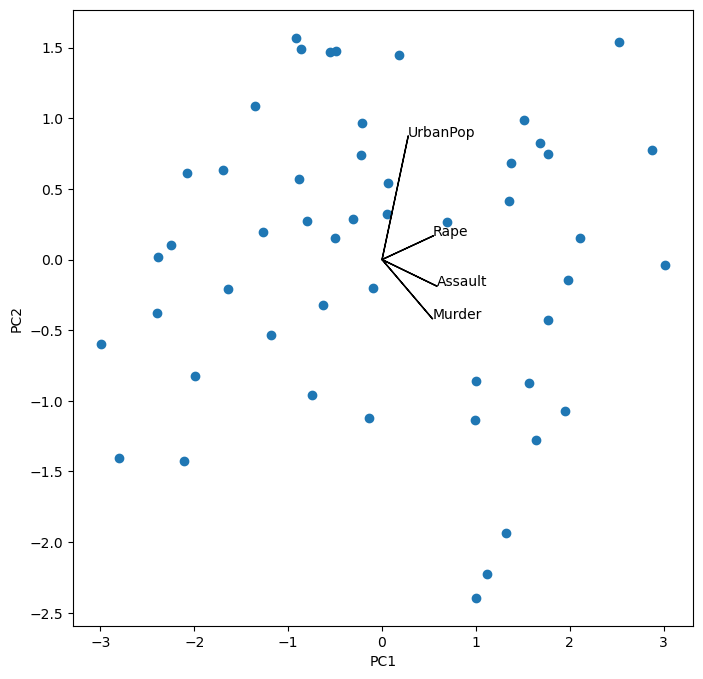

In [13]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, pcaUS.components_[i,k], pcaUS.components_[j,k])
    ax.text(pcaUS.components_[i,k],
            pcaUS.components_[j,k],
            USArrests.columns[k])

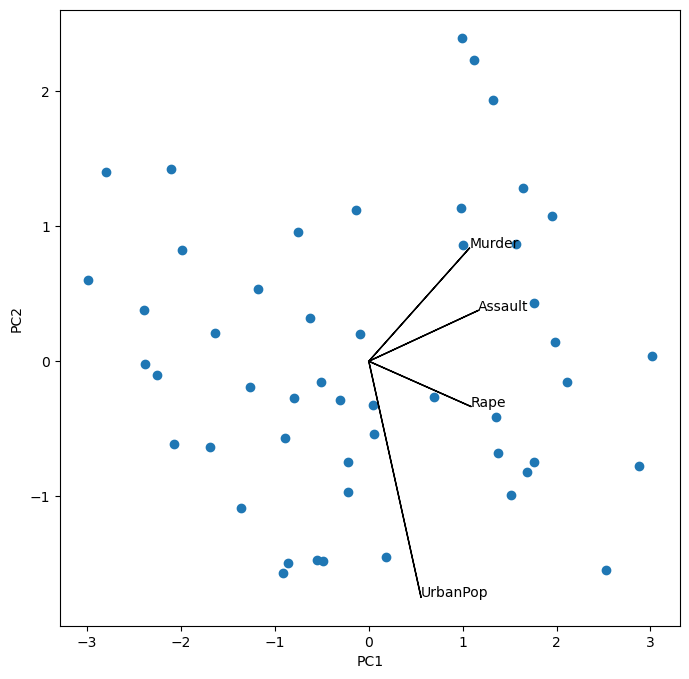

In [14]:
scale_arrow = s_ = 2
scores[:,1] *=-1
pcaUS.components_[1] *=-1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaUS.components_[i,k], s_*pcaUS.components_[
        j,k])
    ax.text(s_*pcaUS.components_[i,k],
            s_*pcaUS.components_[j,k],
            USArrests.columns[k])

In [15]:
scores.std(0, ddof=1)

array([1.5908673 , 1.00496987, 0.6031915 , 0.4206774 ])

In [16]:
pcaUS.explained_variance_

array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

In [17]:
pcaUS.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

In [18]:
%%capture
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaUS.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

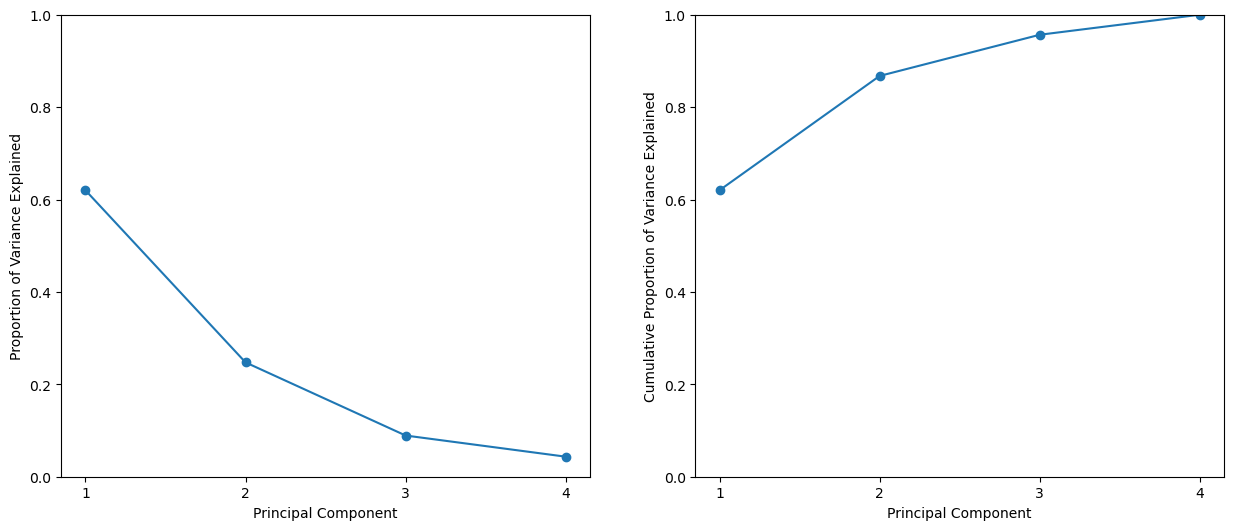

In [19]:
ax = axes[1]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

In [20]:
a = np.array([1,2,8,-3])
np.cumsum(a)

array([ 1,  3, 11,  8])

##### Matrix Completion

In [21]:
X = USArrests_scaled
U, D, V = np.linalg.svd(X, full_matrices=False)
U.shape, D.shape, V.shape

((50, 4), (4,), (4, 4))

In [22]:
V

array([[-0.53589947, -0.58318363, -0.27819087, -0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [ 0.34123273,  0.26814843,  0.37801579, -0.81777791],
       [ 0.6492278 , -0.74340748,  0.13387773,  0.08902432]])

In [23]:
pcaUS.components_

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [ 0.41818087,  0.1879856 , -0.87280619, -0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

In [24]:
(U * D[None,:])[:3]

array([[-0.98556588, -1.13339238,  0.44426879,  0.15626714],
       [-1.95013775, -1.07321326, -2.04000333, -0.43858344],
       [-1.76316354,  0.74595678, -0.05478082, -0.83465292]])

In [25]:
scores[:3]

array([[ 0.98556588,  1.13339238, -0.44426879, -0.15626714],
       [ 1.95013775,  1.07321326,  2.04000333,  0.43858344],
       [ 1.76316354, -0.74595678,  0.05478082,  0.83465292]])

In [26]:
n_omit = 20
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)
Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

In [27]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])

In [28]:
Xhat = Xna.copy()
Xbar = np.nanmean(Xhat, axis=0)
Xhat[r_idx, c_idx] = Xbar[c_idx]

In [29]:
thresh = 1e-7
rel_err = 1
count = 0
ismiss = np.isnan(Xna)
mssold = np.mean(Xhat[ ismiss]**2)
mss0 = np.mean(Xna[ ismiss]**2)

In [30]:
while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=1)
    # # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna- Xapp)[ ismiss])**2)
    rel_err = (mssold- mss) / mss0
    mssold = mss
    print("Iteration: {0}, MSS:{1:.3f}, Rel.Err {2:.2e}"
          .format(count, mss, rel_err))

Iteration: 1, MSS:nan, Rel.Err nan


In [31]:
np.corrcoef(Xapp[ismiss], X[ismiss])[0,1]

np.float64(0.7359490211820904)

##### Clustering


K-Means Clustering

In [32]:
np.random.seed(0);
X = np.random.standard_normal((50,2));
X[:25,0] += 3;
X[:25,1]-= 4;

In [33]:
kmeans = KMeans(n_clusters=2,
                random_state=2,
                n_init=20).fit(X)

c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [34]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

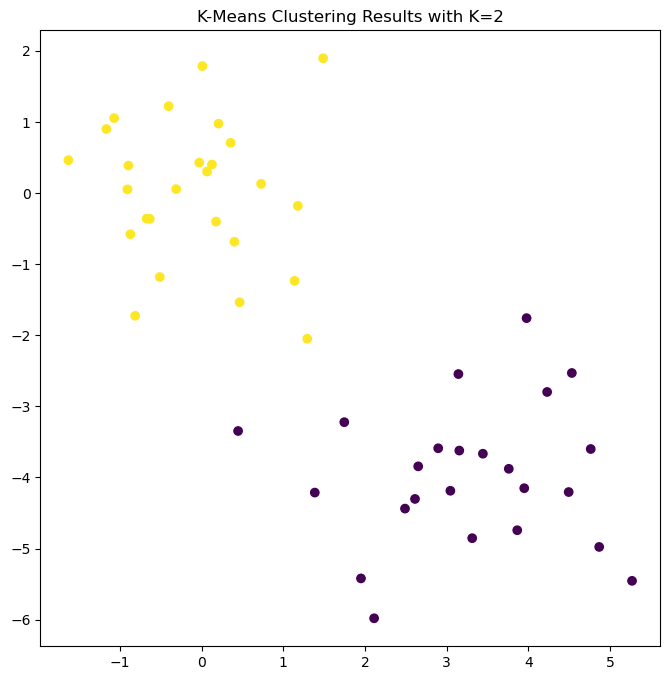

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=2");

c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


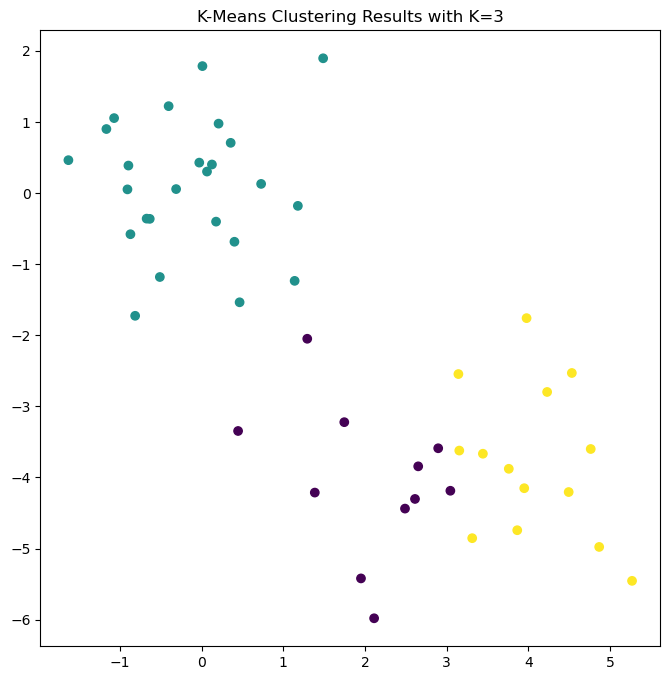

In [36]:
kmeans = KMeans(n_clusters=3,
                random_state=3,
                n_init=20).fit(X)
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3");

In [37]:
kmeans1 = KMeans(n_clusters=3,
                 random_state=3,
                 n_init=1).fit(X)
kmeans20 = KMeans(n_clusters=3,
                  random_state=3,
                  n_init=20).fit(X);
kmeans1.inertia_, kmeans20.inertia_

c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(76.85131986999251, 75.06261242745384)

Hierarchical Clustering

In [38]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')
hc_comp.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [39]:
hc_avg = HClust(distance_threshold=0,
                n_clusters=None,
                linkage='average');
hc_avg.fit(X)
hc_sing = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='single');
hc_sing.fit(X);

In [40]:
D  = np.zeros((X.shape[0], X.shape[0]));
for i in range(X.shape[0]):
    x_ = np.multiply.outer(np.ones(X.shape[0]), X[i])
    D[i] = np.sqrt(np.sum((X- x_)**2, 1));
hc_sing_pre = HClust(distance_threshold=0,
                     n_clusters=None,
                     metric='precomputed',
                     linkage='single')
hc_sing_pre.fit(D)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'precomputed'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'single'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


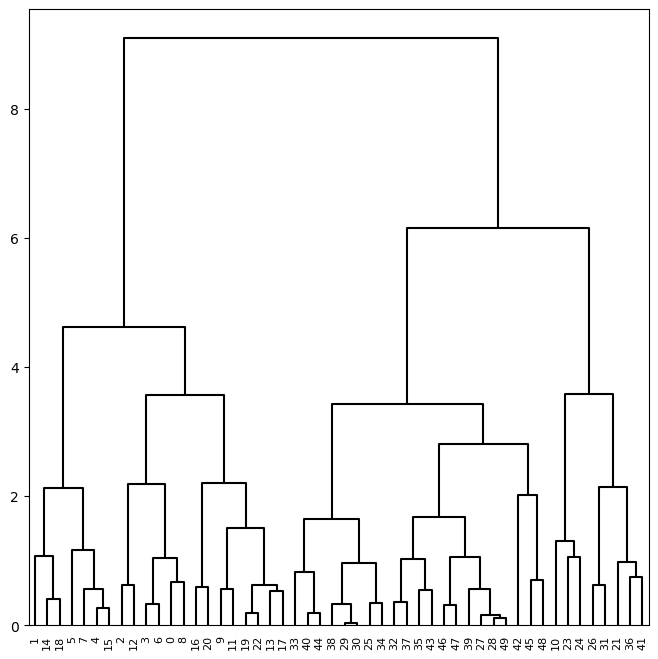

In [41]:
cargs = {'color_threshold':-np.inf,
         'above_threshold_color':'black'}
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           **cargs);

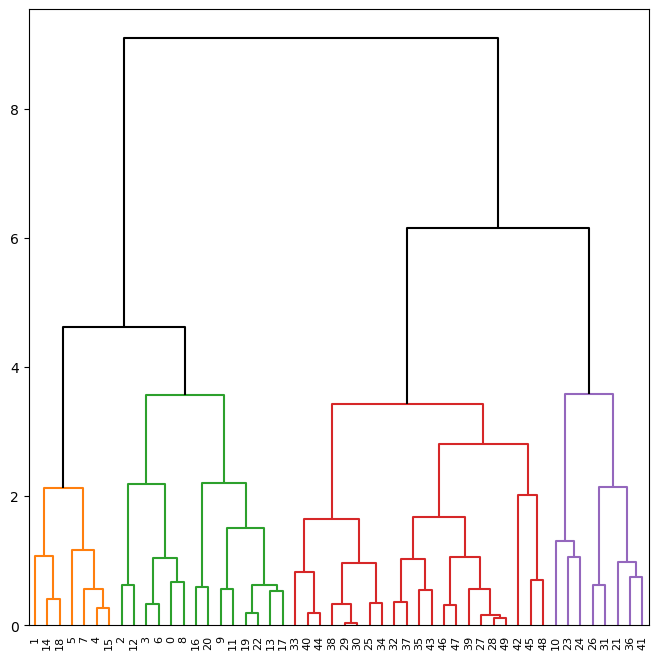

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

In [43]:
cut_tree(linkage_comp, n_clusters=4).T

array([[0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 2,
        0, 2, 2, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3,
        3, 3, 3, 3, 3, 3]])

In [44]:
cut_tree(linkage_comp, height=5)

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [2],
       [1],
       [2],
       [2],
       [2],
       [2],
       [1],
       [2],
       [2],
       [2],
       [2],
       [1],
       [2],
       [2],
       [2],
       [2],
       [1],
       [2],
       [2],
       [2],
       [2],
       [2],
       [2],
       [2],
       [2]])

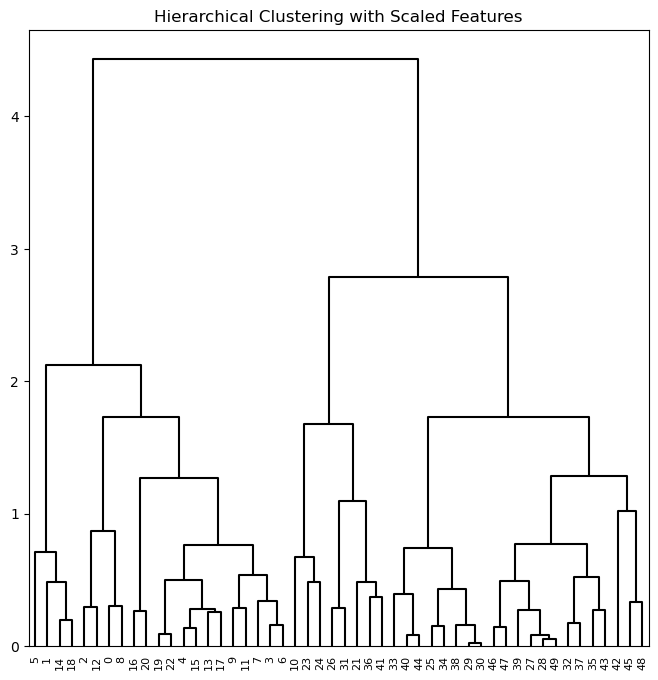

In [45]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)
hc_comp_scale = HClust(distance_threshold=0,
                       n_clusters=None,
                       linkage='complete').fit(X_scale)
linkage_comp_scale = compute_linkage(hc_comp_scale)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp_scale, ax=ax, **cargs)
ax.set_title("Hierarchical Clustering with Scaled Features");

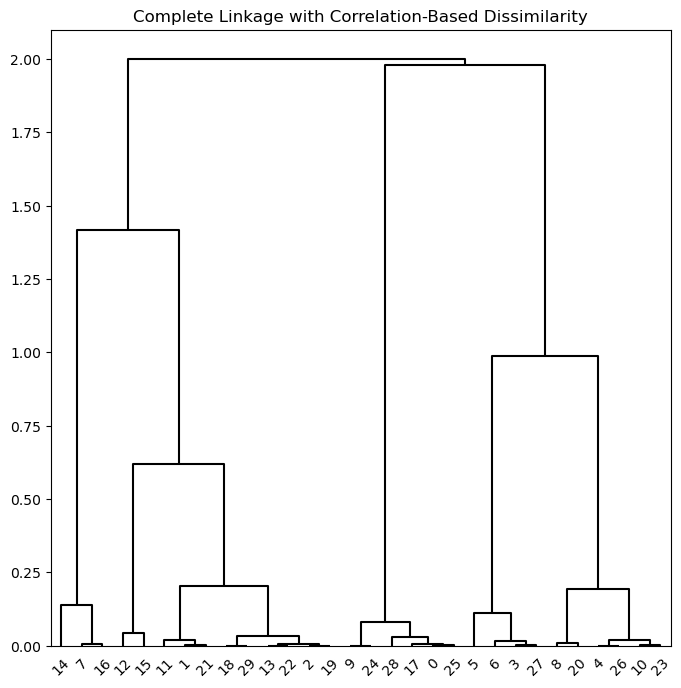

In [46]:
X = np.random.standard_normal((30, 3))
corD = 1- np.corrcoef(X)
hc_cor = HClust(linkage='complete',
                distance_threshold=0,
                n_clusters=None,
                metric='precomputed')
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_cor, ax=ax, **cargs)
ax.set_title("Complete Linkage with Correlation-Based Dissimilarity");

##### NCI60 Data Example

In [47]:
NCI60 = load_data('NCI60')
nci_labs = NCI60['labels']
nci_data = NCI60['data']

In [48]:
nci_data.shape

(64, 6830)

In [49]:
nci_labs.value_counts()

label      
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
LEUKEMIA       6
OVARIAN        6
CNS            5
PROSTATE       2
K562A-repro    1
K562B-repro    1
MCF7D-repro    1
MCF7A-repro    1
UNKNOWN        1
Name: count, dtype: int64

PCA on the NCI60 Data

In [50]:
scaler = StandardScaler()
nci_scaled = scaler.fit_transform(nci_data)
nci_pca = PCA()
nci_scores = nci_pca.fit_transform(nci_scaled)

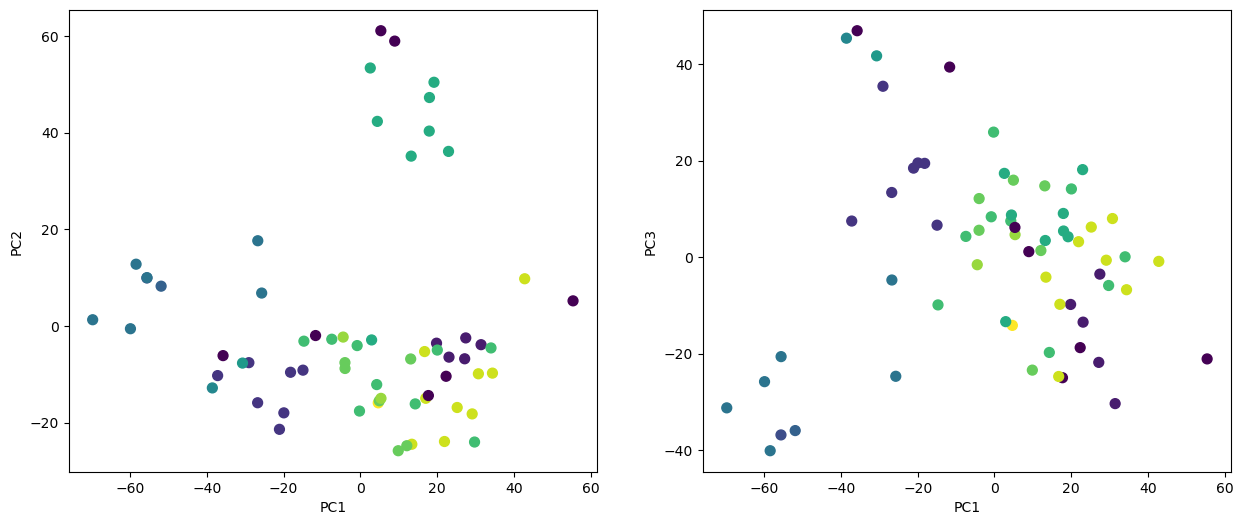

In [51]:
cancer_types = list(np.unique(nci_labs))
nci_groups = np.array([cancer_types.index(lab)
                       for lab in nci_labs.values])
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ax.scatter(nci_scores[:,0],
           nci_scores[:,1],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax = axes[1]
ax.scatter(nci_scores[:,0],
           nci_scores[:,2],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC3');

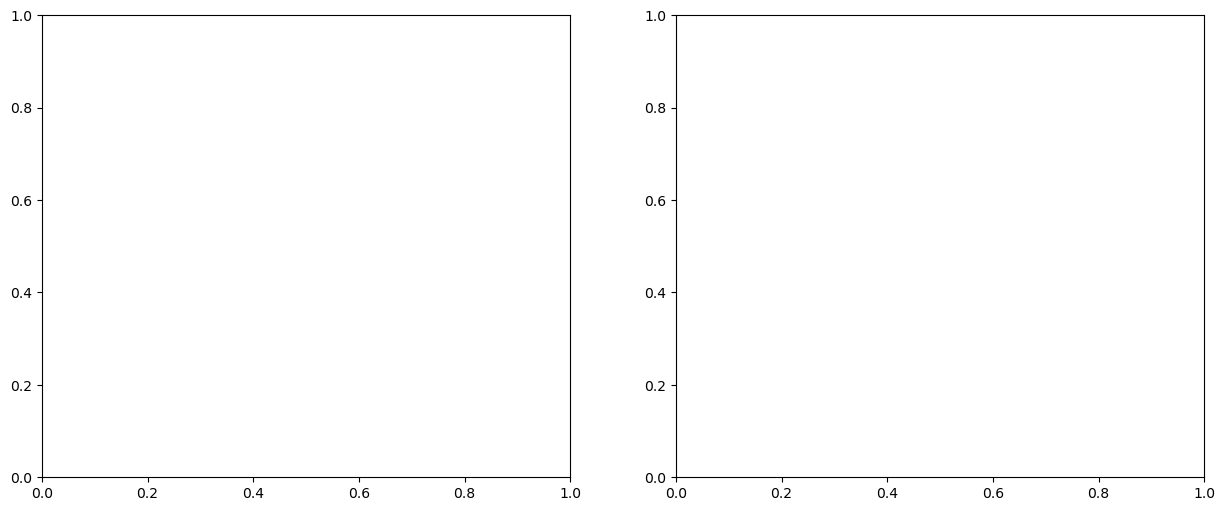

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ticks = np.arange(nci_pca.n_components_)+1

In [53]:
ax.plot(ticks,
        nci_pca.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('PVE')
ax = axes[1]
ax.plot(ticks,
        nci_pca.explained_variance_ratio_.cumsum(),
        marker='o');
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative PVE');

In [54]:
def plot_nci(linkage, ax, cut=-np.inf):
    cargs = {'above_threshold_color':'black',
             'color_threshold':cut}
    hc = HClust(n_clusters=None,
                distance_threshold=0,
                linkage=linkage.lower()).fit(nci_scaled)
    linkage_ = compute_linkage(hc)
    dendrogram(linkage_,
            ax=ax,
            labels=np.asarray(nci_labs),
            leaf_font_size=10,
            **cargs)
    ax.set_title('%s Linkage' % linkage)
    return hc

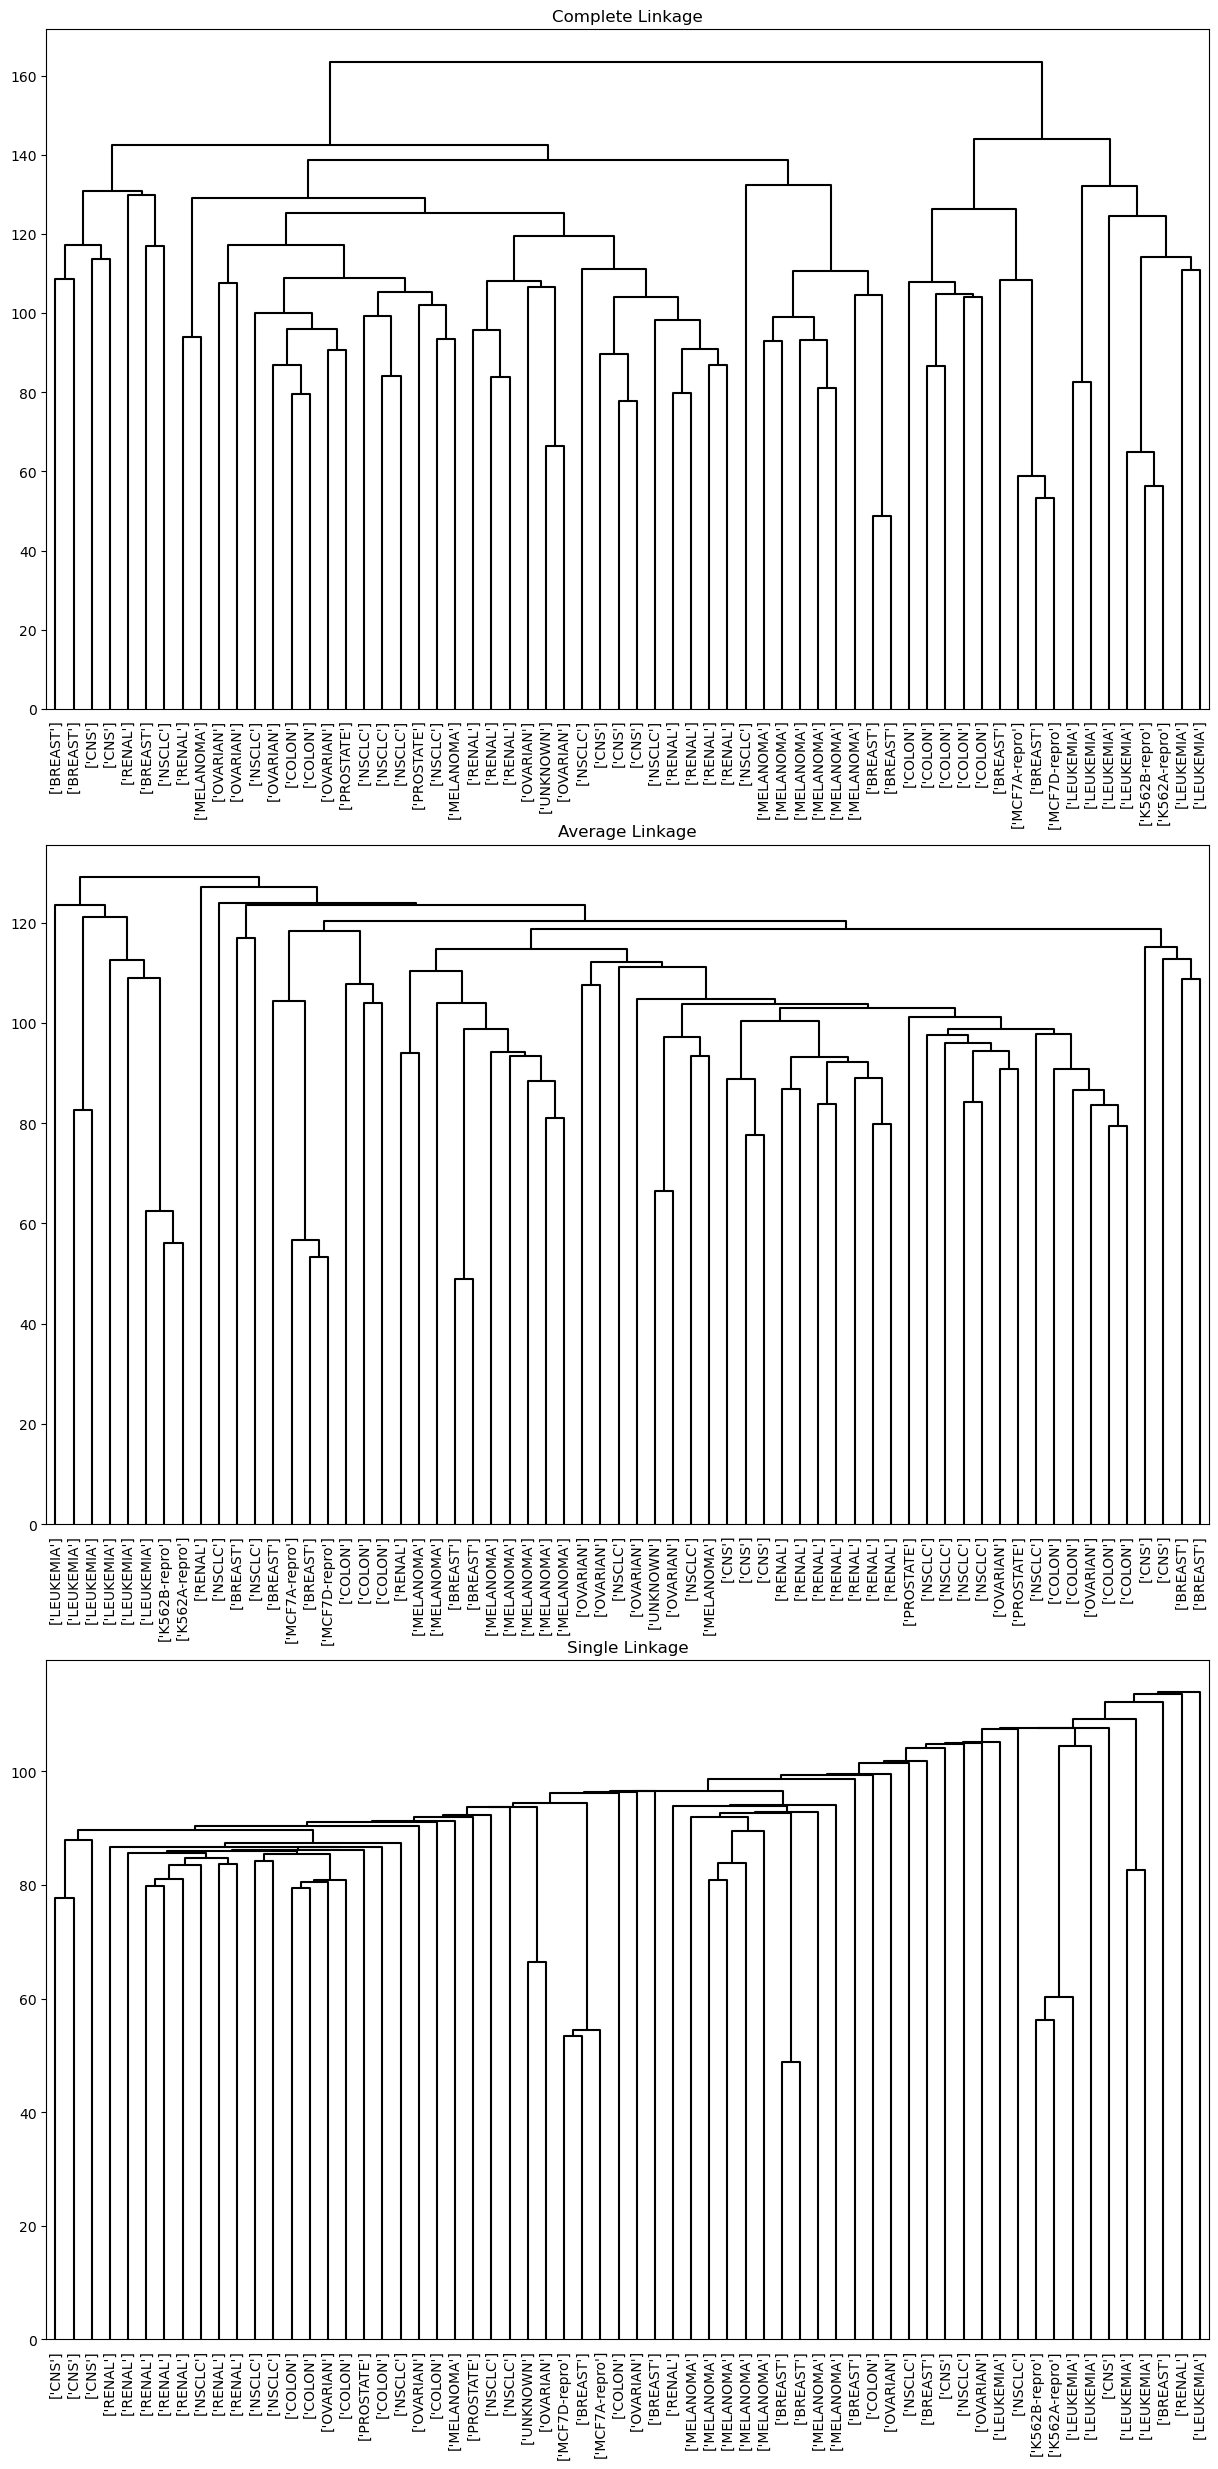

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(15,30))
ax = axes[0]; hc_comp = plot_nci('Complete', ax)
ax = axes[1]; hc_avg = plot_nci('Average', ax)
ax = axes[2]; hc_sing = plot_nci('Single', ax)

In [56]:
linkage_comp = compute_linkage(hc_comp)
comp_cut = cut_tree(linkage_comp, n_clusters=4).reshape(-1)
pd.crosstab(nci_labs['label'],
            pd.Series(comp_cut.reshape(-1), name='Complete'))

Complete,0,1,2,3
label,,,,
BREAST,2,3,0,2
CNS,3,2,0,0
COLON,2,0,0,5
K562A-repro,0,0,1,0
K562B-repro,0,0,1,0
LEUKEMIA,0,0,6,0
MCF7A-repro,0,0,0,1
MCF7D-repro,0,0,0,1
MELANOMA,8,0,0,0


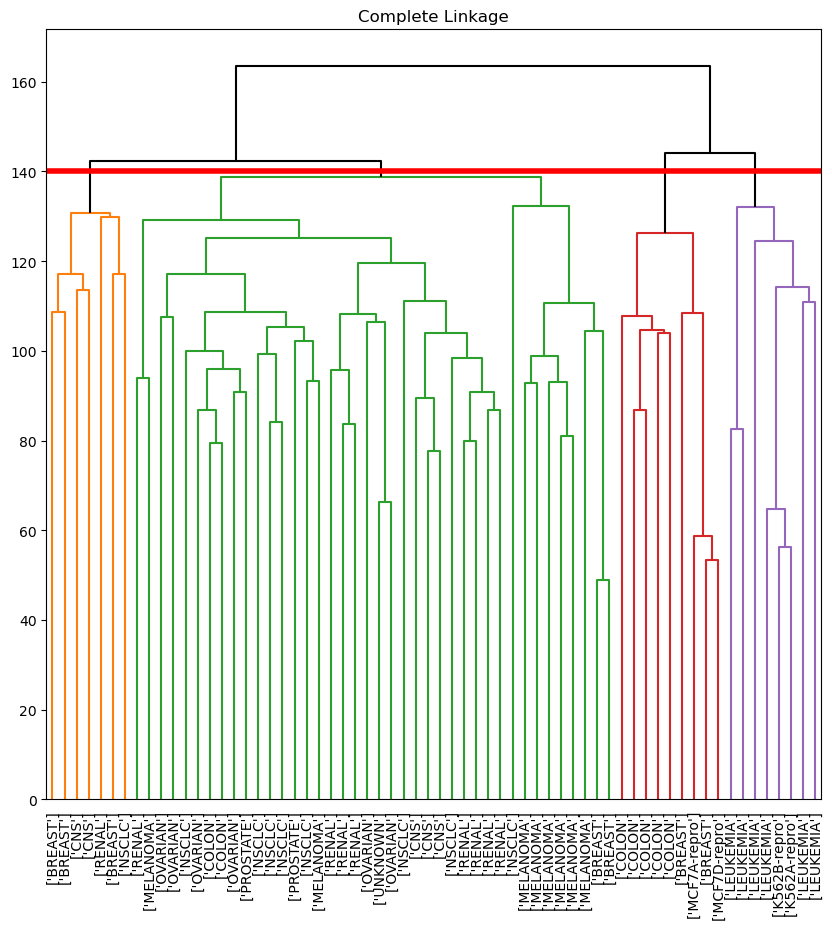

In [57]:
fig, ax = plt.subplots(figsize=(10,10))
plot_nci('Complete', ax, cut=140)
ax.axhline(140, c='r', linewidth=4);

In [58]:
nci_kmeans = KMeans(n_clusters=4,
                    random_state=0,
                    n_init=20).fit(nci_scaled)
pd.crosstab(pd.Series(comp_cut, name='HClust'),
            pd.Series(nci_kmeans.labels_, name='K-means'))

c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-means,0,1,2,3
HClust,,,,
0,1,20,10,9
1,0,7,0,0
2,8,0,0,0
3,0,0,9,0


Complete-PCA,0,1,2,3
label,,,,
BREAST,0,5,0,2
CNS,2,3,0,0
COLON,7,0,0,0
K562A-repro,0,0,1,0
K562B-repro,0,0,1,0
LEUKEMIA,2,0,4,0
MCF7A-repro,0,0,0,1
MCF7D-repro,0,0,0,1
MELANOMA,1,7,0,0


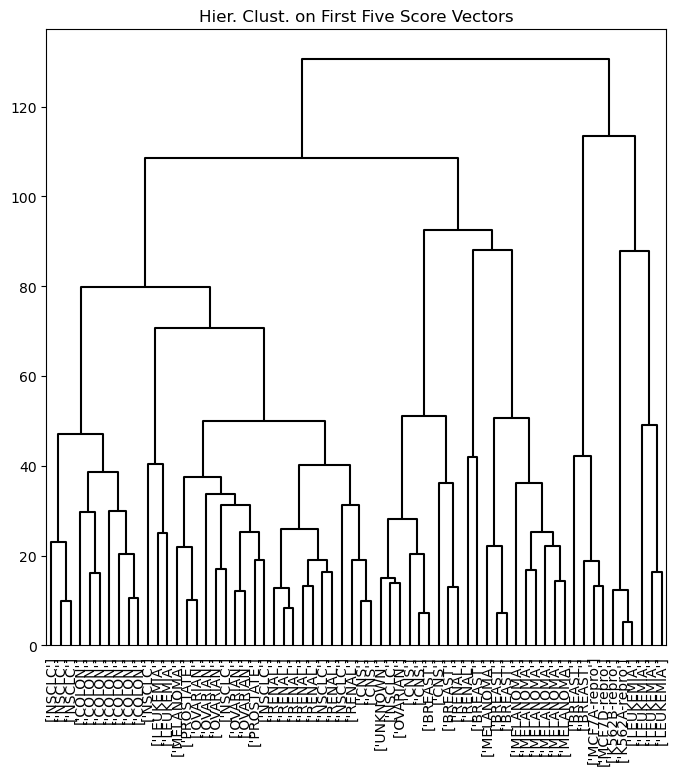

In [59]:
hc_pca = HClust(n_clusters=None,
                distance_threshold=0,
                linkage='complete'
                ).fit(nci_scores[:,:5])
linkage_pca = compute_linkage(hc_pca)
fig, ax = plt.subplots(figsize=(8,8))
dendrogram(linkage_pca,
           labels=np.asarray(nci_labs),
           leaf_font_size=10,
           ax=ax,
           **cargs)
ax.set_title("Hier. Clust. on First Five Score Vectors")
pca_labels = pd.Series(cut_tree(linkage_pca,
                                n_clusters=4).reshape(-1),
                                name='Complete-PCA')
pd.crosstab(nci_labs['label'], pca_labels)

#### Exercises

$Conceptual$

1. This problem involves the K-means clustering algorithm.
   
   (a) Prove $\frac{1}{|C_k|} \sum_{i,j \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2 = 2 \sum_{i \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2 $ (12.18).  
   
   (b) On the basis of this identity, argue that the K-means clustering algorithm (Algorithm 12.2) decreases the objective $\min_{C_1,\ldots,C_K} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{i,j \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{ij})^2 $ (12.17) at each iteration.


**(a): Prove the Identity (12.18)**

**Claim:**

$$\frac{1}{|C_k|} \sum_{i,i' \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{i'j})^2 = 2 \sum_{i \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2$$

where $\bar{x}_{kj} = \frac{1}{|C_k|}\sum_{i \in C_k} x_{ij}$ is the mean of feature $j$ in cluster $C_k$.



**Proof:**

Start with the left-hand side. For a fixed $j$, expand the squared difference:

$$\sum_{i,i' \in C_k}(x_{ij} - x_{i'j})^2 = \sum_{i,i' \in C_k}\left(x_{ij}^2 - 2x_{ij}x_{i'j} + x_{i'j}^2\right)$$

Split the sum into three parts:

$$= \sum_{i,i' \in C_k} x_{ij}^2 - 2\sum_{i,i' \in C_k} x_{ij}x_{i'j} + \sum_{i,i' \in C_k} x_{i'j}^2$$

Since summing over all pairs $(i, i')$, the first and third terms are symmetric:

$$\sum_{i,i' \in C_k} x_{ij}^2 = |C_k|\sum_{i \in C_k} x_{ij}^2 \quad \text{(each } i \text{ appears } |C_k| \text{ times)}$$

and similarly for the third term. The cross term factorises:

$$\sum_{i,i' \in C_k} x_{ij}x_{i'j} = \left(\sum_{i \in C_k} x_{ij}\right)^2 = \left(|C_k|\,\bar{x}_{kj}\right)^2 = |C_k|^2\,\bar{x}_{kj}^2$$

Therefore:

$$\sum_{i,i' \in C_k}(x_{ij} - x_{i'j})^2 = 2|C_k|\sum_{i \in C_k}x_{ij}^2 - 2|C_k|^2\bar{x}_{kj}^2$$

Dividing by $|C_k|$:

$$\frac{1}{|C_k|}\sum_{i,i' \in C_k}(x_{ij} - x_{i'j})^2 = 2\sum_{i \in C_k}x_{ij}^2 - 2|C_k|\bar{x}_{kj}^2$$

Now, using the standard bias–variance decomposition of the sum of squares:

$$\sum_{i \in C_k}(x_{ij} - \bar{x}_{kj})^2 = \sum_{i \in C_k}x_{ij}^2 - |C_k|\,\bar{x}_{kj}^2$$

So the right-hand side becomes:

$$2\sum_{i \in C_k}x_{ij}^2 - 2|C_k|\bar{x}_{kj}^2 = 2\sum_{i \in C_k}(x_{ij} - \bar{x}_{kj})^2$$

Summing over all $j = 1, \ldots, p$:

$$\frac{1}{|C_k|}\sum_{i,i'\in C_k}\sum_{j=1}^{p}(x_{ij} - x_{i'j})^2 = 2\sum_{i \in C_k}\sum_{j=1}^{p}(x_{ij} - \bar{x}_{kj})^2 \qquad \blacksquare$$


**(b): K-Means Decreases the Objective at Each Iteration**

**Objective (12.17):**

$$\underset{C_1,\ldots,C_K}{\min} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{i,i' \in C_k}\sum_{j=1}^{p}(x_{ij} - x_{i'j})^2$$

By identity (12.18), this equals:

$$\sum_{k=1}^{K} 2\sum_{i \in C_k}\sum_{j=1}^{p}(x_{ij} - \bar{x}_{kj})^2$$

i.e. minimising (12.17) is equivalent to minimising the **total within-cluster sum of squares from cluster centroids**. We now show both steps of Algorithm 12.2 cannot increase this quantity.


**Step 2(a) — Recompute Centroids:**

Given a fixed assignment of observations to clusters $C_1, \ldots, C_K$, we minimise over the choice of centre $m_{kj}$ for each cluster $k$ and feature $j$:

$$\sum_{i \in C_k}\sum_{j=1}^p (x_{ij} - m_{kj})^2$$

This is minimised by setting $m_{kj} = \bar{x}_{kj}$, the feature mean of the cluster. Any other choice of centre would yield a strictly larger sum of squares. Thus, updating centroids to the cluster means **cannot increase** the objective.


**Step 2(b) — Reassign Observations:**

Given fixed centroids $\{\bar{x}_{kj}\}$, each observation $i$ is reassigned to cluster $k^*$ such that:

$$k^* = \underset{k}{\arg\min}\sum_{j=1}^p (x_{ij} - \bar{x}_{kj})^2$$

This is exactly choosing the assignment that minimises that observation's contribution to the total within-cluster sum of squares. Since each observation is moved only if doing so strictly reduces its squared distance to the nearest centroid, the total objective **cannot increase**.


**Conclusion:**

Each iteration of Algorithm 12.2 consists of two steps, each of which leaves the objective (12.17) unchanged or strictly decreased. Since the number of possible cluster assignments of $n$ observations into $K$ groups is finite, the algorithm must converge in a finite number of steps to a **local minimum** of the within-cluster variation objective. $\blacksquare$


2. Suppose that we have four observations, for which we compute a dissimilarity matrix, given by 

   $$
   \begin{bmatrix}
   - & 0.3 & 0.4 & 0.7 \\
   0.3 & - & 0.5 & 0.8 \\
   0.4 & 0.5 & - & 0.45 \\
   0.7 & 0.8 & 0.45 & - 
   \end{bmatrix}
   $$

   For instance, the dissimilarity between the first and second observations is 0.3, and the dissimilarity between the second and fourth observations is 0.8.

   (a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observations using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.  
   (b) Repeat (a), this time using single linkage clustering.  
   (c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?  
   (d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?
   
   (e) It is mentioned in this chapter that at each fusion in the dendrogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

**Dissimilarity Matrix**

$$
\begin{bmatrix}
- & 0.30 & 0.40 & 0.70 \\
0.30 & - & 0.50 & 0.80 \\
0.40 & 0.50 & - & 0.45 \\
0.70 & 0.80 & 0.45 & -
\end{bmatrix}
$$



**(a) Complete Linkage Dendrogram**

**Complete linkage** defines the distance between two clusters as the **maximum** pairwise dissimilarity between their members.

**Fusion Steps**

| Step | Clusters Merged | Linkage Calculation | Height |
|------|----------------|---------------------|--------|
| 1 | $\{1\} + \{2\}$ | $d(1,2) = 0.30$ | **0.30** |
| 2 | $\{3\} + \{4\}$ | $d(3,4) = 0.45$ | **0.45** |
| 3 | $\{1,2\} + \{3,4\}$ | $\max(d_{13}, d_{14}, d_{23}, d_{24}) = \max(0.4, 0.7, 0.5, 0.8)$ | **0.80** |

**Dendrogram structure:**
```
0.80 ─────────────┬─────────────
                  │
0.45 ─────┐       ├─────┐
          │       │     │
0.30 ──┬──┘       │   [3] [4]
       │          │
     [1] [2]      │
```
*(See plot panel (a))*



**(b) Single Linkage Dendrogram**

**Single linkage** defines the distance between two clusters as the **minimum** pairwise dissimilarity between their members.

**Fusion Steps**

| Step | Clusters Merged | Linkage Calculation | Height |
|------|----------------|---------------------|--------|
| 1 | $\{1\} + \{2\}$ | $d(1,2) = 0.30$ | **0.30** |
| 2 | $\{1,2\} + \{3\}$ | $\min(d_{13}, d_{23}) = \min(0.4, 0.5)$ | **0.40** |
| 3 | $\{1,2,3\} + \{4\}$ | $\min(d_{14}, d_{24}, d_{34}) = \min(0.7, 0.8, 0.45)$ | **0.45** |

**Dendrogram structure:**
```
0.45 ─────────────────┬──────
                      │
0.40 ───────┬──────   │    [4]
            │
0.30 ──┬──  │   [3]
       │
     [1] [2]
```
*(See plot panel (b))*



**(c) Two Clusters — Complete Linkage**

Cut the complete linkage dendrogram **above $h = 0.45$** and **below $h = 0.80$**:

$$
\boxed{\text{Cluster A} = \{1,\, 2\} \qquad \text{Cluster B} = \{3,\, 4\}}
$$

The cut separates the two internal nodes (fused at 0.30 and 0.45) before they merge at 0.80.



**(d) Two Clusters — Single Linkage**

Cut the single linkage dendrogram **above $h = 0.40$** and **below $h = 0.45$**:

$$
\boxed{\text{Cluster A} = \{1,\, 2,\, 3\} \qquad \text{Cluster B} = \{4\}}
$$

Observation 4 is the last to join, remaining isolated until the final fusion at 0.45.


**(e) Equivalent Dendrogram (Repositioned Leaves)**

At any internal node, the left and right subtrees can be **swapped** without changing the dendrogram's meaning — only the drawing order changes.

For the complete linkage dendrogram, swapping:
- Observations **1 ↔ 2** within their pair (fused at 0.30)
- Observations **3 ↔ 4** within their pair (fused at 0.45)

produces an equivalent dendrogram with leaf order **2, 1, 4, 3** instead of 1, 2, 3, 4. All fusion heights remain identical:

| Pair | Original order | Swapped order | Fusion height |
|------|---------------|---------------|---------------|
| First pair | 1, 2 | 2, 1 | 0.30 |
| Second pair | 3, 4 | 4, 3 | 0.45 |
| Root merge | {1,2} ∪ {3,4} | {2,1} ∪ {4,3} | 0.80 |

*(See plot panel (e))*

Saved dendrograms.png


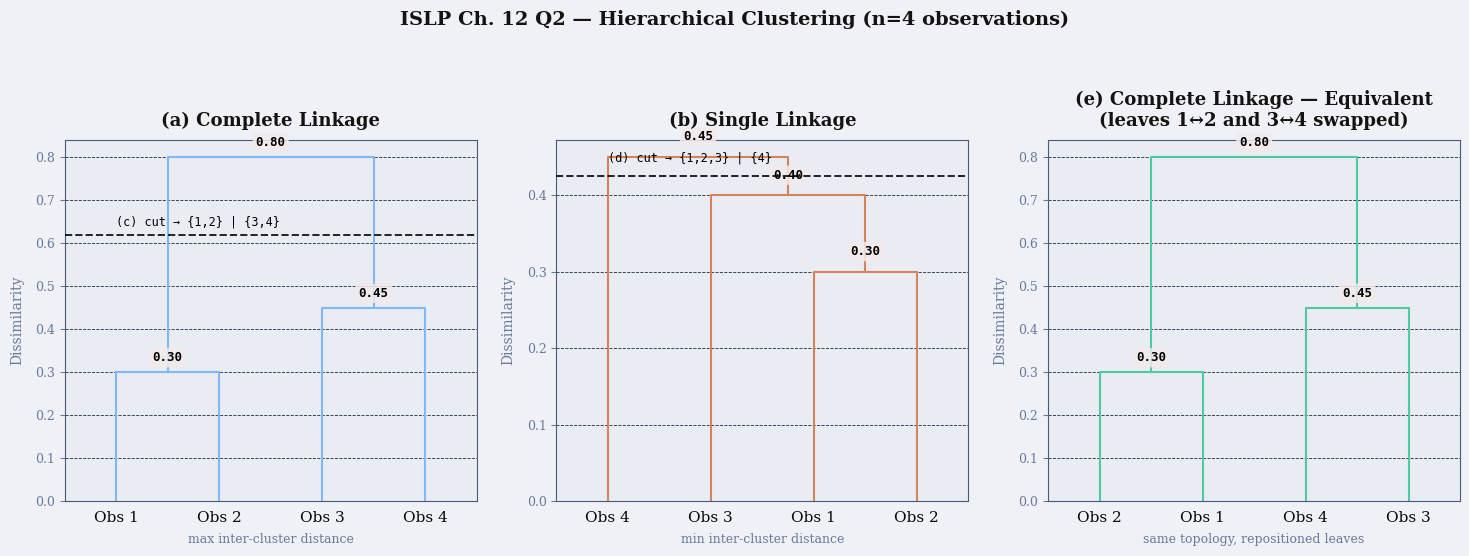

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# ── Dissimilarity matrix ──────────────────────────────────────
D = np.array([
    [0.00, 0.30, 0.40, 0.70],
    [0.30, 0.00, 0.50, 0.80],
    [0.40, 0.50, 0.00, 0.45],
    [0.70, 0.80, 0.45, 0.00],
])

condensed = squareform(D)

# ── Style ─────────────────────────────────────────────────────
BG       = "#eff1f7"
PANEL    = "#eaecf3"
GRID     = "#1e2840"
TITLE    = "#141311"
AXIS     = "#4a5a7a"
TICK     = "#6a7a9a"
LABEL    = "#080808"

COLORS   = {
    "complete": "#7eb8f7",
    "single":   "#d4845a",
    "alt":      "#50c8a0",
}
HEIGHTS  = {"complete": "#000000", "single": "#000000", "alt": "#000000"}

plt.rcParams.update({
    "font.family":      "serif",
    "axes.facecolor":   PANEL,
    "figure.facecolor": BG,
    "axes.edgecolor":   AXIS,
    "axes.labelcolor":  TICK,
    "xtick.color":      TICK,
    "ytick.color":      TICK,
    "grid.color":       GRID,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "text.color":       LABEL,
})

labels_orig = ["Obs 1", "Obs 2", "Obs 3", "Obs 4"]
labels_alt  = ["Obs 2", "Obs 1", "Obs 4", "Obs 3"]   # swapped pairs for (e)


def draw_dendrogram(ax, Z, leaf_labels, color, title, subtitle):
    ddata = dendrogram(
        Z,
        labels=leaf_labels,
        ax=ax,
        color_threshold=0,
        above_threshold_color=color,
        link_color_func=lambda k: color,
    )

    # annotate fusion heights
    seen = set()
    for xs, ys in zip(ddata["icoord"], ddata["dcoord"]):
        h = ys[1]
        xm = (xs[1] + xs[2]) / 2
        key = round(h, 4)
        if key not in seen:
            ax.annotate(
                f"{h:.2f}",
                xy=(xm, h), xytext=(xm, h + 0.018),
                ha="center", va="bottom",
                fontsize=9, fontweight="bold",
                color=HEIGHTS["complete"],
                fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.25", fc="#f3eaea", ec="none", alpha=0.85),
            )
            seen.add(key)

    ax.set_title(title, fontsize=13, fontweight="bold", color=TITLE, pad=10)
    ax.set_xlabel(subtitle, fontsize=9, color=TICK, labelpad=6)
    ax.set_ylabel("Dissimilarity", fontsize=10, color=TICK, labelpad=8)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=11, colors=LABEL)
    ax.tick_params(axis="y", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(AXIS)


# ── Build linkage matrices ────────────────────────────────────
Z_complete = linkage(condensed, method="complete")
Z_single   = linkage(condensed, method="single")

# ── Figure: 3 dendrograms ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "ISLP Ch. 12 Q2 — Hierarchical Clustering (n=4 observations)",
    fontsize=14, fontweight="bold", color=TITLE, y=1.02,
)

draw_dendrogram(axes[0], Z_complete, labels_orig, COLORS["complete"],
                "(a) Complete Linkage", "max inter-cluster distance")

draw_dendrogram(axes[1], Z_single, labels_orig, COLORS["single"],
                "(b) Single Linkage", "min inter-cluster distance")

draw_dendrogram(axes[2], Z_complete, labels_alt, COLORS["alt"],
                "(e) Complete Linkage — Equivalent\n(leaves 1↔2 and 3↔4 swapped)",
                "same topology, repositioned leaves")

# ── Cut annotations on (a) and (b) ───────────────────────────
for ax, cut_h, note in [
    (axes[0], 0.62, "(c) cut → {1,2} | {3,4}"),
    (axes[1], 0.425, "(d) cut → {1,2,3} | {4}"),
]:
    ax.axhline(cut_h, color="#000000", linewidth=1.4,
               linestyle="--", alpha=0.85, zorder=5)
    ax.text(5, cut_h + 0.015, note, color="#000000",
            fontsize=8.5, fontfamily="monospace", va="bottom")

plt.tight_layout(pad=1.8)
plt.savefig("dendrograms.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
print("Saved dendrograms.png")
plt.show()

3. In this problem, you will perform K-means clustering manually, with $ K = 2 $, on a small example with $ n = 6 $ observations and $ p = 2 $ features. The observations are as follows.

| $Obs.$ | $X_1$ | $X_2$ |
|--------|-------|-------|
| 1    | 1  | 4  |
| 2    | 1  | 3  |
| 3    | 0  | 4  |
| 4    | 5  | 1  |
| 5    | 6  | 2  |
| 6    | 4  | 0  |

(a) Plot the observations.  
(b) Randomly assign a cluster label to each observation. You can use the `np.random.choice()` function to do this. Report the cluster labels for each observation.
(c) Compute the centroid for each cluster.  
(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.  
(e) Repeat (c) and (d) until the answers obtained stop changing.
(f) In your plot from (a), color the observations according to the cluster labels obtained.


**Setup**

**Observations** ($n=6$, $p=2$, $K=2$):

| Obs. | $X_1$ | $X_2$ |
|------|-------|-------|
| 1    | 1     | 4     |
| 2    | 1     | 3     |
| 3    | 0     | 4     |
| 4    | 5     | 1     |
| 5    | 6     | 2     |
| 6    | 4     | 0     |



**(a) Initial Plot**

Observations plotted in the $(X_1, X_2)$ plane — see panel **(a)** in the figure. Observations 1–3 cluster near the top-left; observations 4–6 near the bottom-right, suggesting $K=2$ is a natural choice.



**(b) Random Initial Cluster Assignment (`np.random.seed(42)`)**

```python
labels = np.random.choice([0, 1], size=6)
# → [1, 2, 1, 1, 1, 2]
```

| Obs. | $X_1$ | $X_2$ | Initial Cluster |
|------|-------|-------|-----------------|
| 1    | 1     | 4     | **1** |
| 2    | 1     | 3     | **2** |
| 3    | 0     | 4     | **1** |
| 4    | 5     | 1     | **1** |
| 5    | 6     | 2     | **1** |
| 6    | 4     | 0     | **2** |



**(c) & (d) Iteration 1 — Compute Centroids, Reassign**

**Centroids from initial assignment**

$$\mu_1 = \frac{1}{4}\bigl((1,4)+(0,4)+(5,1)+(6,2)\bigr) = (3.00,\ 2.75)$$

$$\mu_2 = \frac{1}{2}\bigl((1,3)+(4,0)\bigr) = (2.50,\ 1.50)$$

**Reassignment (Euclidean distance to each centroid)**

| Obs. | $d(\mu_1)$ | $d(\mu_2)$ | New Cluster |
|------|-----------|-----------|-------------|
| 1    | 2.358     | 2.915     | **1** |
| 2    | 2.016     | 2.121     | **1** |
| 3    | 3.250     | 3.536     | **1** |
| 4    | 2.658     | 2.550     | **2** |
| 5    | 3.092     | 3.536     | **1** |
| 6    | 2.926     | 2.121     | **2** |

New labels: `[1, 1, 1, 2, 1, 2]`



**(e) Subsequent Iterations**

**Iteration 2 — Compute Centroids, Reassign**

$$\mu_1 = \frac{1}{4}\bigl((1,4)+(1,3)+(0,4)+(6,2)\bigr) = (2.00,\ 3.25)$$

$$\mu_2 = \frac{1}{2}\bigl((5,1)+(4,0)\bigr) = (4.50,\ 0.50)$$

| Obs. | $d(\mu_1)$ | $d(\mu_2)$ | New Cluster |
|------|-----------|-----------|-------------|
| 1    | 1.250     | 4.950     | **1** |
| 2    | 1.031     | 4.301     | **1** |
| 3    | 2.136     | 5.701     | **1** |
| 4    | 3.750     | 0.707     | **2** |
| 5    | 4.191     | 2.121     | **2** |
| 6    | 3.816     | 0.707     | **2** |

New labels: `[1, 1, 1, 2, 2, 2]`



**Iteration 3 — Compute Centroids, Reassign**

$$\mu_1 = \frac{1}{3}\bigl((1,4)+(1,3)+(0,4)\bigr) = (0.667,\ 3.667)$$

$$\mu_2 = \frac{1}{3}\bigl((5,1)+(6,2)+(4,0)\bigr) = (5.00,\ 1.00)$$

| Obs. | $d(\mu_1)$ | $d(\mu_2)$ | New Cluster |
|------|-----------|-----------|-------------|
| 1    | 0.471     | 5.000     | **1** |
| 2    | 0.745     | 4.472     | **1** |
| 3    | 0.745     | 5.831     | **1** |
| 4    | 5.088     | 0.000     | **2** |
| 5    | 5.588     | 1.414     | **2** |
| 6    | 4.955     | 1.414     | **2** |

New labels: `[1, 1, 1, 2, 2, 2]` — **same as previous iteration.**

$$\boxed{\text{Converged after 3 iterations.}}$$


**(f) Final Cluster Labels**

| Obs. | $X_1$ | $X_2$ | Final Cluster |
|------|-------|-------|---------------|
| 1    | 1     | 4     | **1** (blue)  |
| 2    | 1     | 3     | **1** (blue)  |
| 3    | 0     | 4     | **1** (blue)  |
| 4    | 5     | 1     | **2** (orange)|
| 5    | 6     | 2     | **2** (orange)|
| 6    | 4     | 0     | **2** (orange)|

**Final centroids:**

$$\mu_1 = (0.667,\ 3.667) \qquad \mu_2 = (5.000,\ 1.000)$$

The algorithm cleanly separates the top-left group $\{1,2,3\}$ from the bottom-right group $\{4,5,6\}$, which matches the visual intuition from part (a). See panel **(f)** in the figure.


  ISLP Ch.12 Q3 — Manual K-Means (K=2, n=6)

(b) Initial random labels: [1 2 1 1 1 2]

  Iteration 1
  Centroids: C1=[3.   2.75], C2=[2.5 1.5]
  New labels: [1 1 1 2 1 2]
    Obs 1 (np.int64(1), np.int64(4)): d(C1)=2.358  d(C2)=2.915  → Cluster 1
    Obs 2 (np.int64(1), np.int64(3)): d(C1)=2.016  d(C2)=2.121  → Cluster 1
    Obs 3 (np.int64(0), np.int64(4)): d(C1)=3.250  d(C2)=3.536  → Cluster 1
    Obs 4 (np.int64(5), np.int64(1)): d(C2)=2.550  d(C1)=2.658  → Cluster 2
    Obs 5 (np.int64(6), np.int64(2)): d(C1)=3.092  d(C2)=3.536  → Cluster 1
    Obs 6 (np.int64(4), np.int64(0)): d(C2)=2.121  d(C1)=2.926  → Cluster 2

  Iteration 2
  Centroids: C1=[2.   3.25], C2=[4.5 0.5]
  New labels: [1 1 1 2 2 2]
    Obs 1 (np.int64(1), np.int64(4)): d(C1)=1.250  d(C2)=4.950  → Cluster 1
    Obs 2 (np.int64(1), np.int64(3)): d(C1)=1.031  d(C2)=4.301  → Cluster 1
    Obs 3 (np.int64(0), np.int64(4)): d(C1)=2.136  d(C2)=5.701  → Cluster 1
    Obs 4 (np.int64(5), np.int64(1)): d(C2)=0.707  d(C1)=3.7

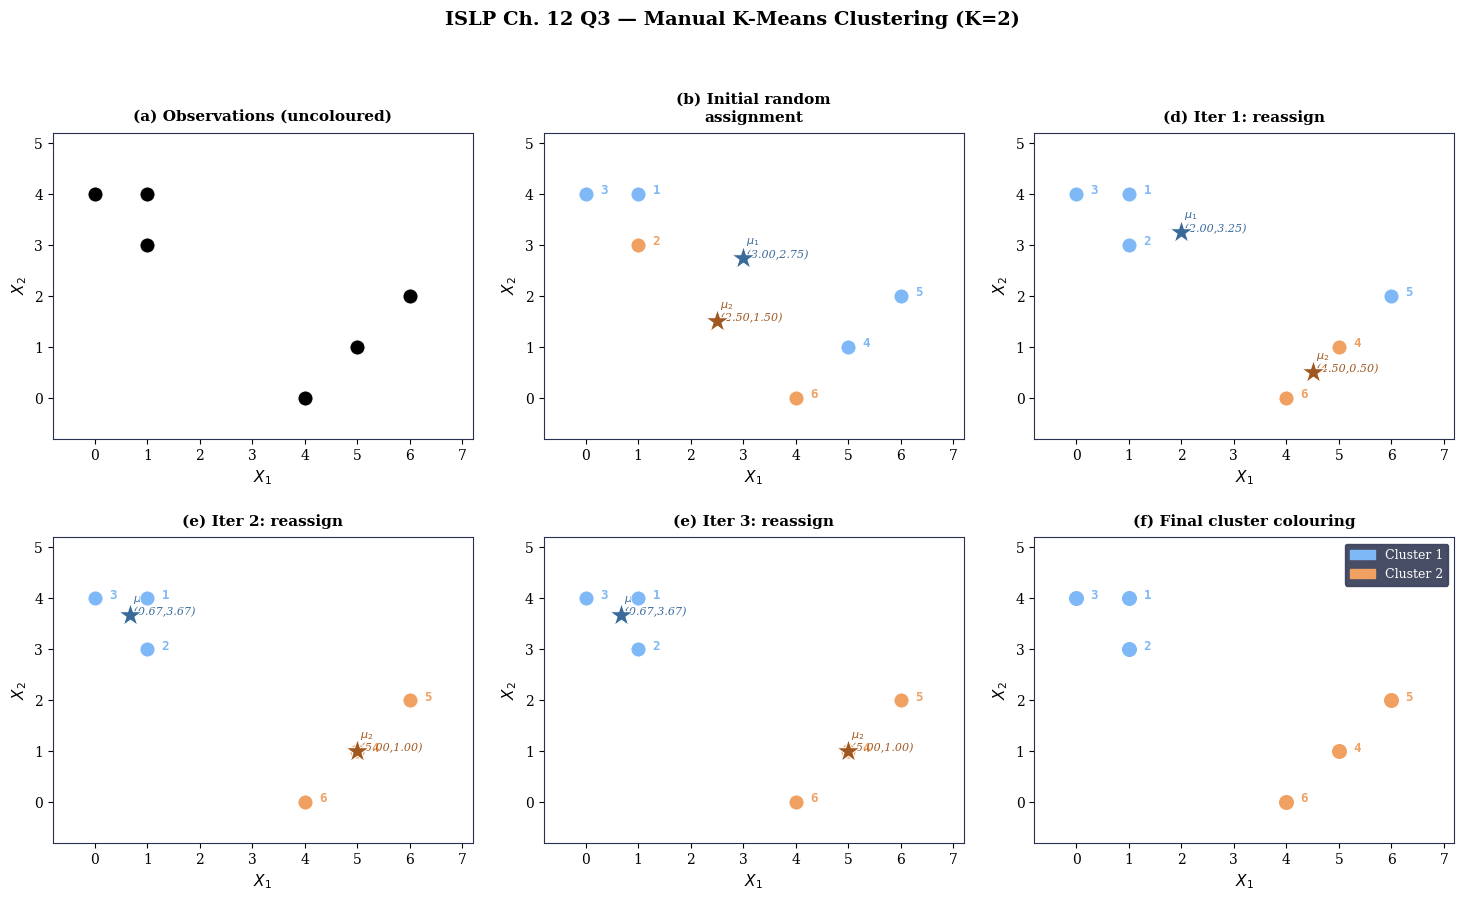

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)

# ── Data ──────────────────────────────────────────────────────
X = np.array([[1,4],[1,3],[0,4],[5,1],[6,2],[4,0]], dtype=float)
n = len(X)

# ── Style ─────────────────────────────────────────────────────
BG, PANEL, GRID = "#ffffff", "#ffffff", "#ffffff"
TITLE, TICK, LABEL = "#000000", "#000000", "#FFFFFF"
C = ["#7eb8f7", "#f0a060"]          # cluster colours
C_DARK = ["#3a6a9a", "#a05820"]     # darker shades for centroids

plt.rcParams.update({
    "font.family": "serif",
    "axes.facecolor": PANEL, "figure.facecolor": BG,
    "axes.edgecolor": "#2a3050", "axes.labelcolor": TICK,
    "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": LABEL,
})

def style_ax(ax, title):
    ax.set_title(title, fontsize=11, fontweight="bold", color="#000000", pad=8)
    ax.set_xlabel("$X_1$", fontsize=11, color=TICK)
    ax.set_ylabel("$X_2$", fontsize=11, color=TICK)
    ax.set_xlim(-0.8, 7.2); ax.set_ylim(-0.8, 5.2)
    ax.grid(True, alpha=0.5); ax.set_axisbelow(True)

def plot_state(ax, labels, centroids, title, show_centroids=True):
    style_ax(ax, title)
    for i, (x, lab) in enumerate(zip(X, labels)):
        ax.scatter(*x, color=C[lab], s=120, zorder=5,
                   edgecolors="white", linewidths=0.8)
        ax.annotate(f"  {i+1}", x, fontsize=9,
                    color=C[lab], fontfamily="monospace", fontweight="bold")
    if show_centroids and centroids is not None:
        for k, cent in enumerate(centroids):
            ax.scatter(*cent, marker="*", s=320, color=C_DARK[k],
                       edgecolors="white", linewidths=0.8, zorder=6)
            ax.annotate(f" $\\mu_{k+1}$\n ({cent[0]:.2f},{cent[1]:.2f})",
                        cent, fontsize=8, color=C_DARK[k], fontstyle="italic")

def compute_centroids(X, labels, K=2):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

def assign_labels(X, centroids):
    dists = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
    return np.argmin(dists, axis=1)

# ── (b) Random initial labels ─────────────────────────────────
labels = np.random.choice([0, 1], size=n)
# ensure both clusters non-empty
while len(np.unique(labels)) < 2:
    labels = np.random.choice([0, 1], size=n)

print("=" * 52)
print("  ISLP Ch.12 Q3 — Manual K-Means (K=2, n=6)")
print("=" * 52)
print(f"\n(b) Initial random labels: {labels + 1}")

# ── Run iterations, record history ───────────────────────────
history = []   # (labels, centroids, iteration_name)

centroids = compute_centroids(X, labels)
history.append((labels.copy(), centroids.copy(), "(b) Initial random\nassignment"))

iteration = 1
while True:
    new_labels = assign_labels(X, centroids)
    new_centroids = compute_centroids(X, new_labels)

    tag = f"(d) Iter {iteration}: reassign" if iteration == 1 else f"(e) Iter {iteration}: reassign"
    history.append((new_labels.copy(), new_centroids.copy(), tag))

    print(f"\n  Iteration {iteration}")
    print(f"  Centroids: C1={centroids[0]}, C2={centroids[1]}")
    print(f"  New labels: {new_labels + 1}")
    for i, (x, lab, d) in enumerate(zip(
            X, new_labels,
            [np.linalg.norm(x - centroids[l]) for x, l in zip(X, new_labels)])):
        other = 1 - lab
        d_other = np.linalg.norm(x - centroids[other])
        print(f"    Obs {i+1} {tuple(x.astype(int))}: "
              f"d(C{lab+1})={np.linalg.norm(x-centroids[lab]):.3f}  "
              f"d(C{other+1})={d_other:.3f}  → Cluster {lab+1}")

    if np.array_equal(new_labels, labels):
        print(f"\n  ✓ Converged after {iteration} iteration(s).")
        break
    labels = new_labels
    centroids = new_centroids
    iteration += 1

final_labels = new_labels
final_centroids = new_centroids

# ── Figure ────────────────────────────────────────────────────
n_panels = min(len(history) + 1, 6)   # +1 for final coloured panel (f)
ncols = 3
nrows = -(-( len(history) + 1 ) // ncols)   # ceiling div

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

# (a) uncoloured initial plot
style_ax(axes[0], "(a) Observations (uncoloured)")
for i, x in enumerate(X):
    axes[0].scatter(*x, color="#000000", s=120, zorder=5,
                    edgecolors="white", linewidths=0.8)
    axes[0].annotate(f"  {i+1}", x, fontsize=9,
                     color=LABEL, fontfamily="monospace", fontweight="bold")

# iteration panels
for idx, (lbl, cent, title) in enumerate(history):
    plot_state(axes[idx + 1], lbl, cent, title)

# (f) final coloured plot — no centroid markers, just clean colours
ax_f = axes[len(history) + 1]
style_ax(ax_f, "(f) Final cluster colouring")
for i, (x, lab) in enumerate(zip(X, final_labels)):
    ax_f.scatter(*x, color=C[lab], s=140, zorder=5,
                 edgecolors="white", linewidths=1.0)
    ax_f.annotate(f"  {i+1}", x, fontsize=9,
                  color=C[lab], fontfamily="monospace", fontweight="bold")
legend_patches = [
    mpatches.Patch(color=C[0], label="Cluster 1"),
    mpatches.Patch(color=C[1], label="Cluster 2"),
]
ax_f.legend(handles=legend_patches, fontsize=9,
            facecolor="#1a2040", edgecolor="#2a3050", labelcolor=LABEL)

# hide unused axes
for ax in axes[len(history) + 2:]:
    ax.set_visible(False)

fig.suptitle("ISLP Ch. 12 Q3 — Manual K-Means Clustering (K=2)",
             fontsize=14, fontweight="bold", color="#000000", y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig("kmeans_q3.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
print("\nSaved kmeans_q3.png")
plt.show()

4. Suppose that for a particular data set, we perform hierarchical clustering using single linkage and using complete linkage. We obtain two dendrograms.

(a) At a certain point on the single linkage dendrogram, the clusters {1, 2, 3} and {4, 5} fuse. On the complete linkage dendrogram, the clusters {1, 2, 3} and {4, 5} also fuse at a certain point. Which fusion will occur higher on the tree, or will they fuse at the same height, or is there not enough information to tell? 

(b) At a certain point on the single linkage dendrogram, the clusters {5} and {6} fuse. On the complete linkage dendrogram, the clusters {5} and {6} also fuse at a certain point. Which fusion will occur higher on the tree, or will they fuse at the same height, or is there not enough information to tell?


**Background**

Recall the two linkage definitions for the distance between clusters $A$ and $B$:

$$d_{\text{single}}(A, B) = \min_{i \in A,\, j \in B} d(i, j)$$

$$d_{\text{complete}}(A, B) = \max_{i \in A,\, j \in B} d(i, j)$$

Since we are taking the **max** over the same set of pairwise distances that the **min** is taken over, it always holds that:

$$d_{\text{single}}(A, B) \leq d_{\text{complete}}(A, B)$$

with equality only when $|A| = |B| = 1$ (singleton clusters, where min = max).

In a dendrogram, **height = the linkage distance at which two clusters fuse**, so a higher fusion means a larger linkage value.



**(a) Fusion of $\{1,2,3\}$ and $\{4,5\}$**

Both clusters have more than one member, so there are **multiple** cross-cluster pairwise distances. The single linkage distance picks the **minimum** of these, while complete linkage picks the **maximum**:

$$d_{\text{single}}(\{1,2,3\},\{4,5\}) = \min_{\substack{i \in \{1,2,3\} \\ j \in \{4,5\}}} d(i,j)$$

$$d_{\text{complete}}(\{1,2,3\},\{4,5\}) = \max_{\substack{i \in \{1,2,3\} \\ j \in \{4,5\}}} d(i,j)$$

Since there are at least $3 \times 2 = 6$ cross-cluster pairs and the observations are not all identical, the max strictly exceeds the min:

$$d_{\text{single}}(\{1,2,3\},\{4,5\}) < d_{\text{complete}}(\{1,2,3\},\{4,5\})$$

$$\boxed{\text{The fusion of } \{1,2,3\} \text{ and } \{4,5\} \text{ occurs } \textbf{higher} \text{ on the complete linkage dendrogram.}}$$



**(b) Fusion of $\{5\}$ and $\{6\}$**

Both clusters are **singletons** — each contains exactly one observation. There is only a single cross-cluster pairwise distance, namely $d(5, 6)$. The minimum and maximum of a single value are equal:

$$d_{\text{single}}(\{5\},\{6\}) = d(5,6) = d_{\text{complete}}(\{5\},\{6\})$$

$$\boxed{\{5\} \text{ and } \{6\} \text{ fuse at the } \textbf{same height} \text{ on both dendrograms.}}$$

This makes intuitive sense: single and complete linkage can only differ when there are multiple inter-cluster pairs to choose between. With two singletons, there is nothing to choose — the linkage distance is uniquely determined by $d(5,6)$ regardless of the linkage method used.

5. In words, describe the results that you would expect if you performed K-means clustering of the eight shoppers in Figure 12.16, on the basis of their sock and computer purchases, with $ K = 2 $. Give three answers, one for each of the variable scalings displayed. Explain.

**Setup**

Eight shoppers are described by two features: **socks purchased** and **computers purchased**. We apply K-means with $K=2$ under three different variable scalings. The key principle is that K-means uses **Euclidean distance**, so whichever feature has the larger numerical variance will dominate the cluster assignments.



**Scaling 1: Raw Units (Left Panel)**

**Expected result:** The two clusters split shoppers by **number of socks purchased**.

**Explanation:** Socks are purchased in quantities of tens or hundreds of pairs, while computers are purchased in quantities of 0, 1, or 2. The variance of the sock variable vastly exceeds the variance of the computer variable in raw counts. When Euclidean distances are computed, differences in sock purchases will dominate, and differences in computer purchases will contribute almost nothing. K-means will therefore partition shoppers into a **high-sock-purchase group** and a **low-sock-purchase group**, largely ignoring whether a shopper bought 0 or 1 computers.



**Scaling 2: Standardised by Standard Deviation (Centre Panel)**

**Expected result:** The two clusters reflect a **combination of sock and computer purchasing behaviour**, with both features contributing roughly equally.

**Explanation:** Dividing each variable by its standard deviation places both on a common scale with unit variance. Neither feature automatically dominates. K-means will now separate shoppers whose overall purchasing profile — across both products — differs most. Intuitively, one cluster is likely to capture **high-engagement shoppers** (more socks *and* more computers) and another **low-engagement shoppers**, or alternatively split on a joint pattern that neither raw variable alone would reveal. This is generally the most **balanced and informative** clustering of the three.



**Scaling 3: Dollars Spent (Right Panel)**

**Expected result:** The two clusters split shoppers by **amount spent on computers**.

**Explanation:** A single computer costs hundreds or thousands of dollars, whereas a pair of socks costs a few dollars. Expressing purchases in dollar terms dramatically inflates the variance of the computer variable relative to socks. Euclidean distances are now almost entirely driven by computer spending. K-means will therefore partition shoppers into a **computer-buyer group** and a **non-computer-buyer group**, largely ignoring differences in sock purchases.



**Summary Table**

| Scaling | Dominant Feature | Expected Cluster Split |
|---------|-----------------|----------------------|
| Raw counts | Socks (high variance in units) | High vs. low sock purchasers |
| Standardised (÷ SD) | Both equally | Joint sock + computer profile |
| Dollar spend | Computers (high unit cost) | Computer buyers vs. non-buyers |

**Key Takeaway**

The choice of scaling is **not merely technical** — it encodes a substantive judgement about which feature matters more. For a retailer more interested in computer sales, dollar scaling or raw counts may be appropriate. For an unbiased view of shopper behaviour, standardisation is preferable. This illustrates why **there is no universally correct answer** to the scaling question; it depends on the goal of the analysis.

6. We saw in Section 12.2.2 that the principal component loading and score vectors provide an approximation to a matrix, in the sense of $ x_{ij} \approx \sum_{m=1}^{M} z_{im} \phi_{jm}$ (12.5). Specifically, the principal component score and loading vectors solve the optimization problem given in 
$$
\begin{aligned}
\min_{A \in \mathbb{R}^{p \times M},\, B \in \mathbb{R}^{p \times M}}
\quad
\sum_{j=1}^{p} \sum_{i=1}^{n}
\left(
x_{ij} - \sum_{m=1}^{M} a_{im} b_{jm}
\right)^2
\end{aligned}
\tag{12.6}.
$$
Now, suppose that the $ M $ principal component score vectors $ z_{im} $ for $ m = 1, \ldots, M $ are known. Using (12.6), explain that each of the first $ M $ principal component loading vectors $ \phi_jm $ for $ m = 1, \ldots, M $ can be obtained by performing $ p $ separate least squares linear regressions. In each regression, the principal component score vectors are the predictors, and one of the features of the data matrix is the response.


**Setup**

The rank-$M$ matrix approximation problem is:

$$\min_{A \in \mathbb{R}^{n \times M},\, B \in \mathbb{R}^{p \times M}} \sum_{j=1}^{p} \sum_{i=1}^{n} \left( x_{ij} - \sum_{m=1}^{M} a_{im} b_{jm} \right)^2 \tag{12.6}$$

where $a_{im}$ are the score vectors (collected in $A$) and $b_{jm}$ are the loading vectors (collected in $B$).



**Argument**

**Suppose the $M$ score vectors are known**, i.e. $A$ is fixed with columns $\mathbf{z}_1, \ldots, \mathbf{z}_M \in \mathbb{R}^n$, where $z_{im}$ denotes the score of observation $i$ on component $m$. Then (12.6) becomes an optimisation over $B$ alone:

$$\min_{B \in \mathbb{R}^{p \times M}} \sum_{j=1}^{p} \sum_{i=1}^{n} \left( x_{ij} - \sum_{m=1}^{M} z_{im} b_{jm} \right)^2$$

**The double sum separates by $j$.** Since the term inside the square depends on $j$ only through $b_{jm}$, we can move the outer sum outside and optimise each $j$ independently:

$$= \sum_{j=1}^{p} \underbrace{\sum_{i=1}^{n} \left( x_{ij} - \sum_{m=1}^{M} z_{im} b_{jm} \right)^2}_{\mathcal{L}_j(b_{j1}, \ldots, b_{jM})}$$

Each sub-problem $\min_{b_{j\cdot}} \mathcal{L}_j$ is **entirely decoupled** from all other $j' \neq j$.



**Recognising the Least Squares Form**

Fix a particular feature $j$. Define:

$$\mathbf{x}_j = \begin{pmatrix} x_{1j} \\ \vdots \\ x_{nj} \end{pmatrix} \in \mathbb{R}^n, \qquad Z = \begin{pmatrix} z_{11} & \cdots & z_{1M} \\ \vdots & & \vdots \\ z_{n1} & \cdots & z_{nM} \end{pmatrix} \in \mathbb{R}^{n \times M}, \qquad \boldsymbol{\phi}_j = \begin{pmatrix} b_{j1} \\ \vdots \\ b_{jM} \end{pmatrix} \in \mathbb{R}^M$$

Then $\mathcal{L}_j$ becomes:

$$\mathcal{L}_j = \sum_{i=1}^{n}\left(x_{ij} - \sum_{m=1}^{M} z_{im}\, b_{jm}\right)^2 = \|\mathbf{x}_j - Z\boldsymbol{\phi}_j\|^2$$

This is precisely the **ordinary least squares (OLS) objective** for regressing the response vector $\mathbf{x}_j \in \mathbb{R}^n$ onto the predictor matrix $Z \in \mathbb{R}^{n \times M}$, with coefficient vector $\boldsymbol{\phi}_j$.

The minimiser is the OLS estimator:

$$\hat{\boldsymbol{\phi}}_j = (Z^\top Z)^{-1} Z^\top \mathbf{x}_j$$


**The $p$ Regressions**

Repeating this for every $j = 1, \ldots, p$ yields **$p$ separate least squares regressions**, each sharing the same design matrix $Z$ (the $M$ score vectors) but with a different response:

| Regression | Response | Predictors | Coefficients recovered |
|-----------|----------|------------|----------------------|
| $j = 1$ | $\mathbf{x}_1$ (feature 1) | $\mathbf{z}_1, \ldots, \mathbf{z}_M$ | $\phi_{1m}$ for $m=1,\ldots,M$ |
| $j = 2$ | $\mathbf{x}_2$ (feature 2) | $\mathbf{z}_1, \ldots, \mathbf{z}_M$ | $\phi_{2m}$ for $m=1,\ldots,M$ |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |
| $j = p$ | $\mathbf{x}_p$ (feature $p$) | $\mathbf{z}_1, \ldots, \mathbf{z}_M$ | $\phi_{pm}$ for $m=1,\ldots,M$ |

The estimated coefficient on $\mathbf{z}_m$ in regression $j$ is exactly the $(j,m)$ loading $\hat{\phi}_{jm}$ — i.e. the contribution of the $m$-th principal component to feature $j$.


**Summary**

$$\boxed{\hat{\boldsymbol{\phi}}_j = (Z^\top Z)^{-1} Z^\top \mathbf{x}_j, \quad j = 1, \ldots, p}$$

When the $M$ score vectors are treated as **known predictors**, minimising (12.6) over the loadings $B$ decomposes into $p$ **independent OLS problems** — one per feature of the data matrix. The loading vector $\boldsymbol{\phi}_j = (\phi_{j1}, \ldots, \phi_{jM})^\top$ is simply the vector of regression coefficients obtained by regressing the $j$-th feature $\mathbf{x}_j$ on all $M$ score vectors simultaneously. This duality between scores and loadings underlies iterative algorithms (such as the power method) for computing PCA when a full SVD is computationally expensive.

$Applied$

7. In this chapter, we mentioned the use of correlation-based distance and Euclidean distance as dissimilarity measures for hierarchical clustering. It turns out that these two measures are almost equivalent: if each observation has been centered to have mean zero and standard deviation one, and if we let $ r_{ij} $ denote the correlation between the $\text{ith}$ and $\text{jth}$ observations, then the quantity $ 1 - r_{ij} $ is proportional to the squared Euclidean distance between the $\text{ith}$ and $\text{jth}$ observations.

On the `USArrests` data, show that this proportionality holds.  

$Hint:$ The Euclidean distance can be calculated using the `pairwise_distances()` function from the `sklearn.metrics` module, and pairwise correlations can be calculated using the `np.corrcoef()` function.


**Theoretical Result**

The claim is: if each observation has been **centred to mean zero and standard deviation one** (across its $p$ features), and $r_{ij}$ denotes the Pearson correlation between observations $i$ and $j$, then:

$$d^2_{ij} \propto (1 - r_{ij})$$

**Proof of the exact proportionality constant**

Let $\mathbf{x}_i \in \mathbb{R}^p$ be the feature vector of observation $i$, row-standardised so that:

$$\frac{1}{p}\sum_{k=1}^{p} x_{ik} = 0 \qquad \text{and} \qquad \frac{1}{p}\sum_{k=1}^{p} x_{ik}^2 = 1$$

The squared Euclidean distance between observations $i$ and $j$ is:

$$d^2_{ij} = \sum_{k=1}^{p}(x_{ik} - x_{jk})^2 = \sum_{k=1}^{p}x_{ik}^2 - 2\sum_{k=1}^{p}x_{ik}x_{jk} + \sum_{k=1}^{p}x_{jk}^2$$

Since each observation is standardised to $\sum_k x_{ik}^2 = p$ and $\sum_k x_{jk}^2 = p$, and the Pearson correlation between two zero-mean, unit-variance vectors is:

$$r_{ij} = \frac{1}{p}\sum_{k=1}^{p}x_{ik}x_{jk}$$

we obtain:

$$d^2_{ij} = p - 2p\,r_{ij} + p = 2p(1 - r_{ij})$$

$$\boxed{d^2_{ij} = 2p\,(1 - r_{ij})}$$

The proportionality constant is $c = 2p$.

> **Note on standardisation:** The identity holds exactly when **each observation (row)** is standardised to mean $= 0$, SD $= 1$ across its $p$ features. This is *row-wise* standardisation, distinct from the usual *column-wise* (feature) standardisation. Column-wise standardisation only guarantees proportionality approximately (not exactly), since the sum of squares $\sum_k x_{ik}^2$ is no longer guaranteed to equal $p$ for every row.


**Empirical Verification on USArrests**

**Data and preprocessing**

```python
import numpy as np
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# Row-standardise: each observation has mean=0, sd=1 across p=4 features
X = StandardScaler().fit_transform(X_raw.T).T   # shape (50, 4)
n, p = X.shape   # n=50 states, p=4 features
```

**Computing distances**

```python
# Squared Euclidean distance between observations
euc_sq = pairwise_distances(X, metric="euclidean") ** 2   # shape (50, 50)

# Pearson correlation between observations
# np.corrcoef(X) treats rows as variables → gives the 50×50 obs-obs matrix
corr_mat    = np.corrcoef(X)                              # shape (50, 50)
one_minus_r = 1 - corr_mat
```

**Results**

| Quantity | Value |
|----------|-------|
| $n$ (states) | 50 |
| $p$ (features) | 4 |
| Pairs compared | 1,225 |
| Estimated $\hat{c}$ | **8.000000** |
| Theoretical $2p$ | **8** |
| Pearson $r(d^2,\, 1-r)$ | **1.000000000000** |
| Max \|residual\| | **3.6 × 10⁻¹⁵** (machine $\varepsilon$) |

The proportionality is exact to machine precision:

$$d^2_{ij} = 8 \cdot (1 - r_{ij}) = 2p\,(1 - r_{ij}) \qquad \forall\; i \neq j$$


**Figure Description**

The three panels in the plot confirm the result:

**Left:** Scatter of $d^2_{ij}$ vs. $(1-r_{ij})$ for all 1,225 state pairs. All points fall exactly on the line $d^2 = 8(1-r)$ — no scatter is visible.

**Centre:** Residuals $d^2_{ij} - \hat{c}(1-r_{ij})$ are all within $\sim 10^{-15}$ of zero — floating-point machine epsilon, confirming the identity is algebraically exact, not approximate.

**Right:** Heatmap of the absolute difference $|d^2_{ij} - 2p(1-r_{ij})|$ across all 50×50 pairs. The uniform near-zero colour confirms the identity holds for every pair of states.

  USArrests — Proportionality of Distance Measures

  n (states)  = 50,  p (features) = 4
  Pairs       = 1225

  Estimated  c_hat  = 8.000000
  Theoretical 2p    = 8

  Pearson r         = 1.000000000000  ← ≈ 1 ✓
  Max |residual|    = 3.608e-15  ← machine ε ✓

  Confirmed:  d²_ij = 2p · (1 − r_ij)  [exactly]

Saved proportionality_q7.png


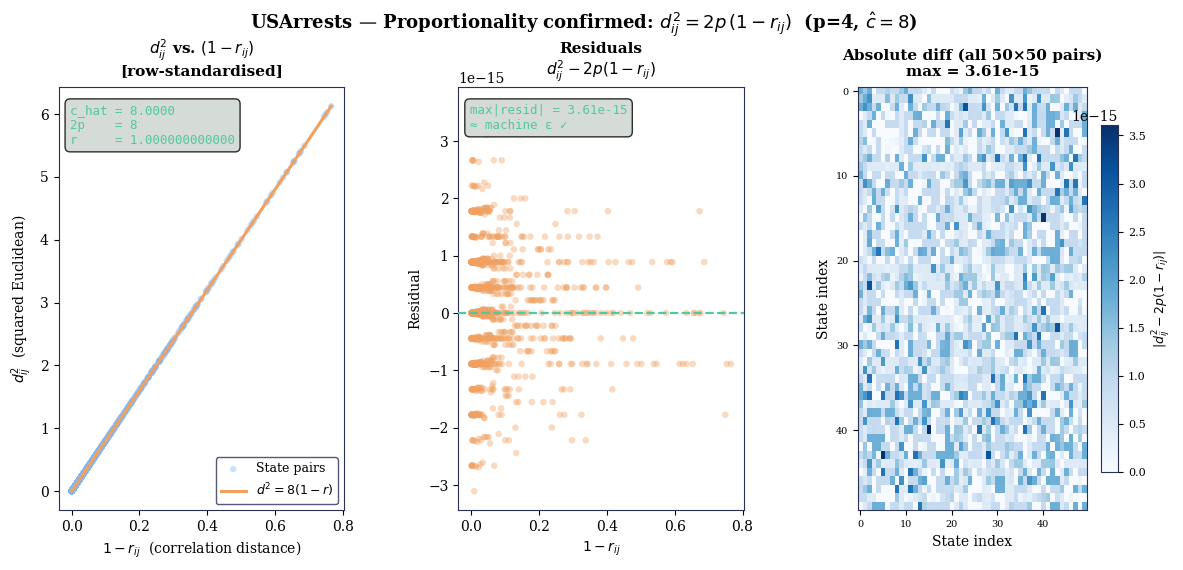

In [62]:
import numpy as np
from ISLP import load_data
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec

# Load USArrests directly from R datasets repository
url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv"
USArrests = pd.read_csv(url, index_col=0)

X_raw = USArrests.to_numpy().astype(float)

# ── Row-standardise: each observation has mean=0, sd=1 across p features ─────
# This is the condition stated in the question — NOT column standardisation.
# Transpose so StandardScaler operates along features (columns) for each obs.
X = StandardScaler().fit_transform(X_raw.T).T   # shape (50, 4)
n, p = X.shape                                  # n=50 states, p=4 features

# ── Squared Euclidean distances between observations ──────────
euc_sq = pairwise_distances(X, metric="euclidean") ** 2   # (50, 50)

# ── Pearson correlation between observations ──────────────────
# np.corrcoef(X) treats rows as variables → gives the (50×50) obs-obs matrix
corr_mat    = np.corrcoef(X)     # r_ij = correlation between obs i and obs j
one_minus_r = 1 - corr_mat

# ── Extract upper triangle (1225 unique pairs) ────────────────
idx = np.triu_indices(n, k=1)
d2  = euc_sq[idx]
omr = one_minus_r[idx]

# ── Estimate proportionality constant (fit through origin) ────
c_hat    = np.dot(d2, omr) / np.dot(omr, omr)
theory   = 2 * p                  # exact value: 2p  (derived algebraically)
r_val, _ = pearsonr(omr, d2)
resid    = d2 - c_hat * omr
max_resid = np.max(np.abs(resid))

print("=" * 56)
print("  USArrests — Proportionality of Distance Measures")
print("=" * 56)
print(f"\n  n (states)  = {n},  p (features) = {p}")
print(f"  Pairs       = {len(d2)}")
print(f"\n  Estimated  c_hat  = {c_hat:.6f}")
print(f"  Theoretical 2p    = {theory}")
print(f"\n  Pearson r         = {r_val:.12f}  ← ≈ 1 ✓")
print(f"  Max |residual|    = {max_resid:.3e}  ← machine ε ✓")
print(f"\n  Confirmed:  d²_ij = 2p · (1 − r_ij)  [exactly]")

# ── Plot style ─────────────────────────────────────────────────
BG, PANEL, GRID     = "#ffffff", "#ffffff", "#ffffff"
TITLE, TICK         = "#000000", "#000000"
BLUE, ORANGE, GREEN = "#7eb8f7", "#f0a060", "#50c8a0"

plt.rcParams.update({
    "font.family":      "serif",
    "axes.facecolor":   PANEL,
    "figure.facecolor": BG,
    "axes.edgecolor":   "#2a3050",
    "axes.labelcolor":  TICK,
    "xtick.color":      TICK,
    "ytick.color":      TICK,
    "grid.color":       GRID,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "text.color":       "#c8d4f0",
})

fig = plt.figure(figsize=(14, 5.5))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

def info_box(ax, txt):
    """Annotate axis with a styled monospace info box."""
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=9, fontfamily="monospace", color=GREEN,
            bbox=dict(boxstyle="round,pad=0.4", fc="#d1d8d2", ec="#161816", alpha=0.9))

# ── Panel 1: scatter (1-r) vs d² with proportional fit ───────
ax1 = fig.add_subplot(gs[0])
ax1.scatter(omr, d2, color=BLUE, alpha=0.40, s=22,
            edgecolors="none", label="State pairs", zorder=3)
xl = np.linspace(0, omr.max(), 300)
ax1.plot(xl, c_hat * xl, color=ORANGE, lw=2.2,
         label=f"$d^2 = {c_hat:.0f}(1-r)$", zorder=4)
ax1.set_title("$d^2_{ij}$ vs. $(1-r_{ij})$\n[row-standardised]",
              fontsize=11, color=TITLE, fontweight="bold", pad=8)
ax1.set_xlabel("$1-r_{ij}$  (correlation distance)", fontsize=10)
ax1.set_ylabel("$d^2_{ij}$  (squared Euclidean)", fontsize=10)
ax1.legend(fontsize=9, facecolor="#ffffff", edgecolor="#2a3050", labelcolor="#000000")
ax1.grid(True, alpha=0.5); ax1.set_axisbelow(True)
info_box(ax1, f"c_hat = {c_hat:.4f}\n2p    = {theory}\nr     = {r_val:.12f}")

# ── Panel 2: residuals ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.scatter(omr, resid, color=ORANGE, alpha=0.40, s=22,
            edgecolors="none", zorder=3)
ax2.axhline(0, color=GREEN, lw=1.6, linestyle="--", zorder=4)
ax2.set_title("Residuals\n$d^2_{ij} - 2p(1-r_{ij})$",
              fontsize=11, color=TITLE, fontweight="bold", pad=8)
ax2.set_xlabel("$1-r_{ij}$", fontsize=10)
ax2.set_ylabel("Residual", fontsize=10)
ax2.grid(True, alpha=0.5); ax2.set_axisbelow(True)
info_box(ax2, f"max|resid| = {max_resid:.2e}\n≈ machine ε ✓")

# ── Panel 3: heatmap of |d² − c*(1-r)| across all pairs ──────
ax3 = fig.add_subplot(gs[2])
diff_mat = np.abs(euc_sq - c_hat * one_minus_r)
im = ax3.imshow(diff_mat, cmap="Blues", aspect="auto",
                vmin=0, vmax=diff_mat.max())
cbar = fig.colorbar(im, ax=ax3, shrink=0.82)
cbar.ax.tick_params(colors=TICK, labelsize=8)
cbar.set_label("$|d^2_{ij} - 2p(1-r_{ij})|$", color=TICK, fontsize=9)
ax3.set_title(f"Absolute diff (all {n}×{n} pairs)\nmax = {diff_mat.max():.2e}",
              fontsize=11, color=TITLE, fontweight="bold", pad=8)
ax3.set_xlabel("State index", fontsize=10)
ax3.set_ylabel("State index", fontsize=10)
ax3.tick_params(labelsize=7)

fig.suptitle(
    f"USArrests — Proportionality confirmed: "
    f"$d^2_{{ij}} = 2p\\,(1-r_{{ij}})$  (p={p}, $\\hat{{c}}={c_hat:.0f}$)",
    fontsize=13, fontweight="bold", color=TITLE, y=1.02,
)
plt.savefig("proportionality_q7.png", dpi=160, bbox_inches="tight", facecolor=BG)
print("\nSaved proportionality_q7.png")
plt.show()

8. In Section 12.2.3, a formula for calculating PVE was given in Equation 12.10 $\frac{\sum_{i=1}^{n} z_{im}^2}{\sum_{j=1}^{p} \sum_{i=1}^{n} x_{ij}^2} = \frac{\sum_{i=1}^{n} \left( \sum_{j=1}^{p} \varphi_{jm} x_{ij} \right)^2}{\sum_{j=1}^{p} \sum_{i=1}^{n} x_{ij}^2}$. We also saw that the PVE can be obtained using the `explained_variance_ratio_` attribute of a fitted `PCA()` estimator.

On the `USArrests` data, calculate PVE in two ways:

(a) Using the `explained_variance_ratio_` output of the fitted PCA() estimator, as was done in Section 12.2.3.  
(b) By applying Equation 12.10 directly. The loadings are stored as the `components_` attribute of the fitted `PCA()` estimator. Use those loadings in Equation 12.10 to obtain the PVE.

These two approaches should give the same results.

$Hint:$ You will only obtain the same results in (a) and (b) if the same data is used in both cases. For instance, if in (a) you performed PCA() using centered and scaled variables, then you must center and scale the variables before applying Equation 12.10 in (b).

**Setup**

The **Proportion of Variance Explained (PVE)** by the $m$-th principal component is given by Equation 12.10:

$$\text{PVE}_m = \frac{\sum_{i=1}^{n} z_{im}^2}{\sum_{j=1}^{p}\sum_{i=1}^{n} x_{ij}^2} = \frac{\sum_{i=1}^{n}\left(\sum_{j=1}^{p}\phi_{jm}\, x_{ij}\right)^2}{\sum_{j=1}^{p}\sum_{i=1}^{n} x_{ij}^2}$$

Both the numerator (variance of scores on component $m$) and denominator (total variance across all features) use the **same pre-processed data matrix** $X$ — centred and scaled.


**Preprocessing**

```python
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Column-wise standardisation: mean=0, sd=1 per feature
X = StandardScaler().fit_transform(X_raw)   # shape (50, 4)
```

After standardisation, the denominator simplifies exactly to $n \cdot p$:

$$\sum_{j=1}^{p}\sum_{i=1}^{n} x_{ij}^2 = n \cdot p = 50 \times 4 = 200$$



**(a) PVE via `explained_variance_ratio_`**

```python
pca = PCA()
Z   = pca.fit_transform(X)      # score matrix  (50 × 4)
phi = pca.components_           # loading matrix (4 × 4): row m = φ_m

pve_a = pca.explained_variance_ratio_
```



**(b) PVE via Equation 12.10 directly**

```python
denom = np.sum(X ** 2)                             # Σ_j Σ_i x_ij² = 200

pve_b = np.array([np.sum(Z[:, m] ** 2) / denom
                  for m in range(p)])
```

The scores `Z[:, m]` are already $z_{im} = \sum_j \phi_{jm} x_{ij}$, stored in the PCA output. We use the **same** $X$ in both (a) and (b) — this is the critical requirement from the hint.



**Results**

| PC | (a) `explained_variance_ratio_` | (b) Eq. 12.10 | \|Difference\| |
|----|--------------------------------|---------------|----------------|
| PC1 | 0.6099824453 | 0.6099824453 | 5.6 × 10⁻¹⁶ |
| PC2 | 0.2494267850 | 0.2494267850 | 3.3 × 10⁻¹⁶ |
| PC3 | 0.0992555886 | 0.0992555886 | 5.6 × 10⁻¹⁷ |
| PC4 | 0.0413351810 | 0.0413351810 | 2.0 × 10⁻¹⁶ |

**Max |difference|** = $5.55 \times 10^{-16}$ — machine epsilon. The two methods are **numerically identical**.

**Cumulative PVE**

| PC | Cumulative PVE |
|----|---------------|
| PC1 | 0.610 (61.0%) |
| PC2 | 0.859 (85.9%) |
| PC3 | 0.959 (95.9%) |
| PC4 | 1.000 (100%) |

The first two PCs alone explain **86%** of the total variance in the USArrests data.



**Why the hint matters**

The key condition for (a) and (b) to agree is that **the same data matrix is used in both**. Specifically:

- `PCA().fit_transform(X)` internally centres $X$ — but if `StandardScaler` has already centred and scaled, the data fed to PCA is already standardised.
- Equation 12.10 must use the **same pre-processed** $X$ in its denominator $\sum_j\sum_i x_{ij}^2$, not the raw data.
- If raw (unscaled) data were used in (b)'s denominator but scaled data in (a), the results would differ substantially.



  USArrests — PVE two ways  (n=50, p=4)

  Denominator  Σ_j Σ_i x_ij² = 200.000000

PC1: (a) 0.6200603948 | (b) 0.6200603948 | diff 1.11e-16
PC2: (a) 0.2474412881 | (b) 0.2474412881 | diff 5.55e-17
PC3: (a) 0.0891407951 | (b) 0.0891407951 | diff 2.78e-17
PC4: (a) 0.0433575219 | (b) 0.0433575219 | diff 3.47e-17

  Max |difference| = 1.11e-16

Saved pve_q8.png


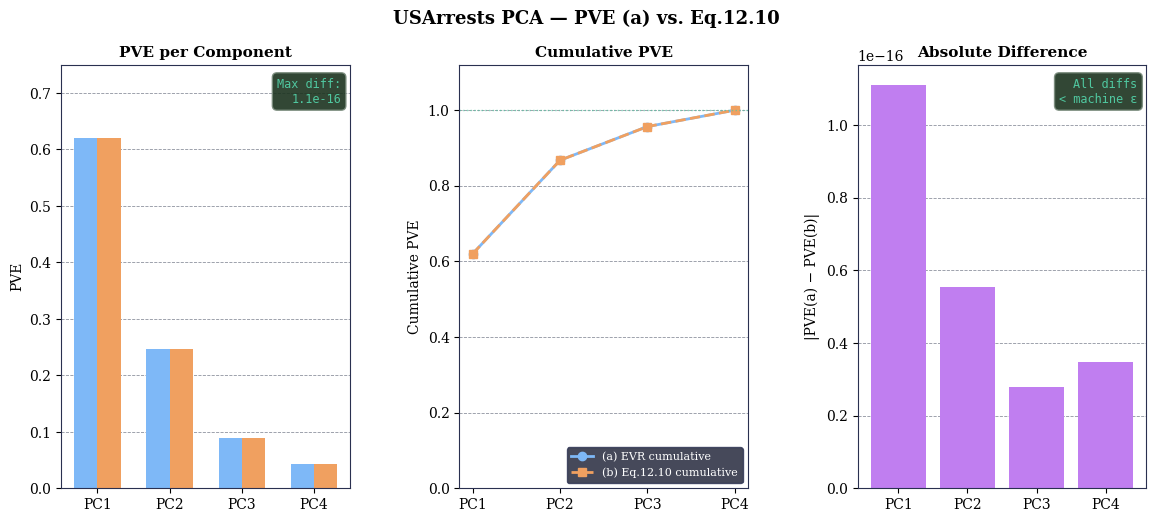

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Load USArrests directly from R public dataset repository
url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv"
USArrests = pd.read_csv(url, index_col=0)

X_raw = USArrests.to_numpy().astype(float)
feature_names = USArrests.columns.to_list()
n, p = X_raw.shape

# Centre and scale (column-wise)
X = StandardScaler().fit_transform(X_raw)

# Fit PCA
pca = PCA()
Z   = pca.fit_transform(X)          # score matrix (n × p)
phi = pca.components_               # loading matrix (p × p)

# PVE via explained_variance_ratio_
pve_a = pca.explained_variance_ratio_

# PVE via Equation 12.10
denom = np.sum(X ** 2)
pve_b = np.array([np.sum(Z[:, m] ** 2) / denom for m in range(p)])

# Print results
print("=" * 60)
print("  USArrests — PVE two ways  (n=50, p=4)")
print("=" * 60)
print(f"\n  Denominator  Σ_j Σ_i x_ij² = {denom:.6f}\n")
for m in range(p):
    print(f"PC{m+1}: (a) {pve_a[m]:.10f} | (b) {pve_b[m]:.10f} | diff {abs(pve_a[m]-pve_b[m]):.2e}")

print(f"\n  Max |difference| = {np.max(np.abs(pve_a - pve_b)):.2e}")

# ── Plot style
BG, PANEL, GRID     = "#ffffff", "#ffffff", "#1e2840"
TITLE, TICK         = "#000000", "#000000"
BLUE, ORANGE, GREEN = "#7eb8f7", "#f0a060", "#50c8a0"
PURPLE              = "#c07ef0"

plt.rcParams.update({
    "font.family":      "serif",
    "axes.facecolor":   PANEL,
    "figure.facecolor": BG,
    "axes.edgecolor":   "#2a3050",
    "axes.labelcolor":  TICK,
    "xtick.color":      TICK,
    "ytick.color":      TICK,
    "grid.color":       GRID,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "text.color":       "#c8d4f0",
})

pcs   = [f"PC{m+1}" for m in range(p)]
x_pos = np.arange(p)
bar_w = 0.32
cum_a = np.cumsum(pve_a)
cum_b = np.cumsum(pve_b)

fig = plt.figure(figsize=(14, 5.5))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Helper functions
def style(ax, title):
    ax.set_title(title, fontsize=11, color=TITLE, fontweight="bold")
    ax.set_xticks(x_pos); ax.set_xticklabels(pcs, fontsize=10)
    ax.grid(True, alpha=0.5, axis="y"); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#2a3050")

def ibox(ax, txt):
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, va="top", ha="right",
            fontsize=8.5, fontfamily="monospace", color=GREEN,
            bbox=dict(boxstyle="round,pad=0.4", fc="#1b331f", ec="#798b7c", alpha=0.9))

# Panel 1: PVE per component
ax1 = fig.add_subplot(gs[0])
ax1.bar(x_pos - bar_w/2, pve_a, bar_w, color=BLUE, label="(a) explained_variance_ratio_")
ax1.bar(x_pos + bar_w/2, pve_b, bar_w, color=ORANGE, label="(b) Eq.12.10")
ax1.set_ylabel("PVE", fontsize=10)
ax1.set_ylim(0, 0.75)
style(ax1, "PVE per Component")
ibox(ax1, f"Max diff:\n{np.max(np.abs(pve_a-pve_b)):.1e}")

# Panel 2: Cumulative PVE
ax2 = fig.add_subplot(gs[1])
ax2.plot(x_pos, cum_a, color=BLUE, marker="o", lw=2, label="(a) EVR cumulative")
ax2.plot(x_pos, cum_b, color=ORANGE, marker="s", lw=2, linestyle="--", label="(b) Eq.12.10 cumulative")
ax2.axhline(1.0, color=GREEN, lw=1, linestyle=":", alpha=0.7)
ax2.set_ylabel("Cumulative PVE", fontsize=10)
ax2.set_ylim(0, 1.12)
style(ax2, "Cumulative PVE")
ax2.legend(fontsize=8, facecolor="#181c31", edgecolor="#2a3050", labelcolor="#ffffff", loc="lower right")

# Panel 3: Absolute difference
ax3 = fig.add_subplot(gs[2])
ax3.bar(x_pos, np.abs(pve_a - pve_b), color=PURPLE)
ax3.set_ylabel("|PVE(a) − PVE(b)|", fontsize=10)
style(ax3, "Absolute Difference")
ibox(ax3, f"All diffs\n< machine ε")

fig.suptitle("USArrests PCA — PVE (a) vs. Eq.12.10", fontsize=13, fontweight="bold", color=TITLE)
plt.savefig("pve_q8.png", dpi=160, bbox_inches="tight", facecolor=BG)
print("\nSaved pve_q8.png")
plt.show()

9. Consider the `USArrests` data. We will now perform hierarchical clustering on the states.

(a) Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states.  

(b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?

(c) Hierarchically cluster the states using complete linkage and Euclidean distance, after scaling the variables to have standard deviation one.

(d) What effect does scaling the variables have on the hierarchical clustering obtained? In your opinion, should the variables be scaled before the inter-observation dissimilarities are computed? Provide a justification for your answer.

**(a) Complete Linkage, Euclidean Distance (Unscaled)**

```python
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z_raw = linkage(X_raw, method="complete", metric="euclidean")
```

The resulting dendrogram is shown in the **left panel** of the figure. Since the Assault variable has values in the hundreds while Murder and Rape are in single digits, **Assault dominates the Euclidean distances** and therefore drives the clustering structure.



**(b) Three Clusters (Unscaled)**

```python
labels_3 = fcluster(Z_raw, t=3, criterion="maxclust")
```

Cutting the unscaled dendrogram to obtain three clusters:

**Cluster 1 — 16 states (high crime, large Assault counts)**
Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina

**Cluster 2 — 14 states (moderate crime)**
Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma, Oregon, Rhode Island, Tennessee, Texas, Virginia, Washington, Wyoming

**Cluster 3 — 20 states (low crime, rural/Midwest)**
Connecticut, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, Ohio, Pennsylvania, South Dakota, Utah, Vermont, West Virginia, Wisconsin


**(c) Complete Linkage, Euclidean Distance (Scaled, SD = 1)**

```python
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X_raw)
Z_std = linkage(X_std, method="complete", metric="euclidean")
```

Scaling each variable to have standard deviation one equalises the contribution of all four features to the Euclidean distance. The resulting dendrogram is shown in the **right panel**.

Three clusters after scaling:

**Cluster 1 — 26 states (low-to-moderate crime across all variables)**
Connecticut, Hawaii, Idaho, Indiana, Iowa, Kansas, Maine, Massachusetts, Minnesota, Missouri, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Washington, West Virginia, Wisconsin

**Cluster 2 — 13 states (high Murder and Assault, moderate urbanisation)**
Alabama, Arkansas, Delaware, Georgia, Kentucky, Louisiana, Mississippi, Nevada, North Carolina, South Carolina, Tennessee, Virginia, Wyoming

**Cluster 3 — 11 states (high crime + high urbanisation)**
Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, New Mexico, New York, Texas



**(d) Effect of Scaling — Discussion**

**What changes**

Scaling substantially alters the cluster assignments. For example:

| State | Unscaled cluster | Scaled cluster |
|-------|-----------------|----------------|
| Massachusetts | 2 | 1 |
| Kentucky | 3 | 2 |
| Wyoming | 2 | 2 |
| Delaware | 1 | 2 |
| Texas | 2 | 3 |

The unscaled clustering is almost entirely determined by **Assault** (range: 45–337), since its variance dwarfs Murder (0.8–17.4), UrbanPop (32–91), and Rape (7.3–46.0). After scaling, all four variables contribute roughly equally.

**Should the variables be scaled?**

**Yes, the variables should be scaled** before computing dissimilarities. The justification is as follows:

1. **Different units and scales:** Murder is measured in rates per 100,000, Assault in counts per 100,000, UrbanPop as a percentage, and Rape in rates per 100,000. There is no principled reason why a difference of 100 Assault arrests should be treated as equivalent to a difference of 1 murder — yet that is what raw Euclidean distance implicitly assumes.

2. **Assault artificially dominates:** The Assault variable has a standard deviation of ~83, compared to ~4 for Murder and ~9 for Rape. Without scaling, the clustering is essentially a one-dimensional sort on Assault counts, ignoring the information carried by the other three variables.

3. **Goal of clustering:** We want to group states with **similar crime profiles across all crime types**, not merely similar levels of one (historically high-variance) crime. Scaling ensures a holistic comparison.

4. **Practical outcome:** The scaled clustering produces more interpretable and geographically coherent groupings — Cluster 3 (high-crime, highly urban states) and Cluster 2 (high violent crime, more rural) are meaningfully distinct in ways the unscaled result obscures.

The only scenario where unscaled variables would be appropriate is if the raw magnitudes themselves carry meaningful information — for instance, if Assault's higher absolute counts reflect a genuinely stronger signal about danger levels. Even then, domain knowledge should drive the choice, not the arbitrary accident of measurement scale.

USArrests — Hierarchical Clustering (Complete, Euclidean)

(b) Three clusters (unscaled):
  Cluster 1 (16 states): ['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']
  Cluster 2 (14 states): ['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']
  Cluster 3 (20 states): ['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']

(d) Three clusters (scaled):
  Cluster 1 (31 states): ['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri', 'Mon

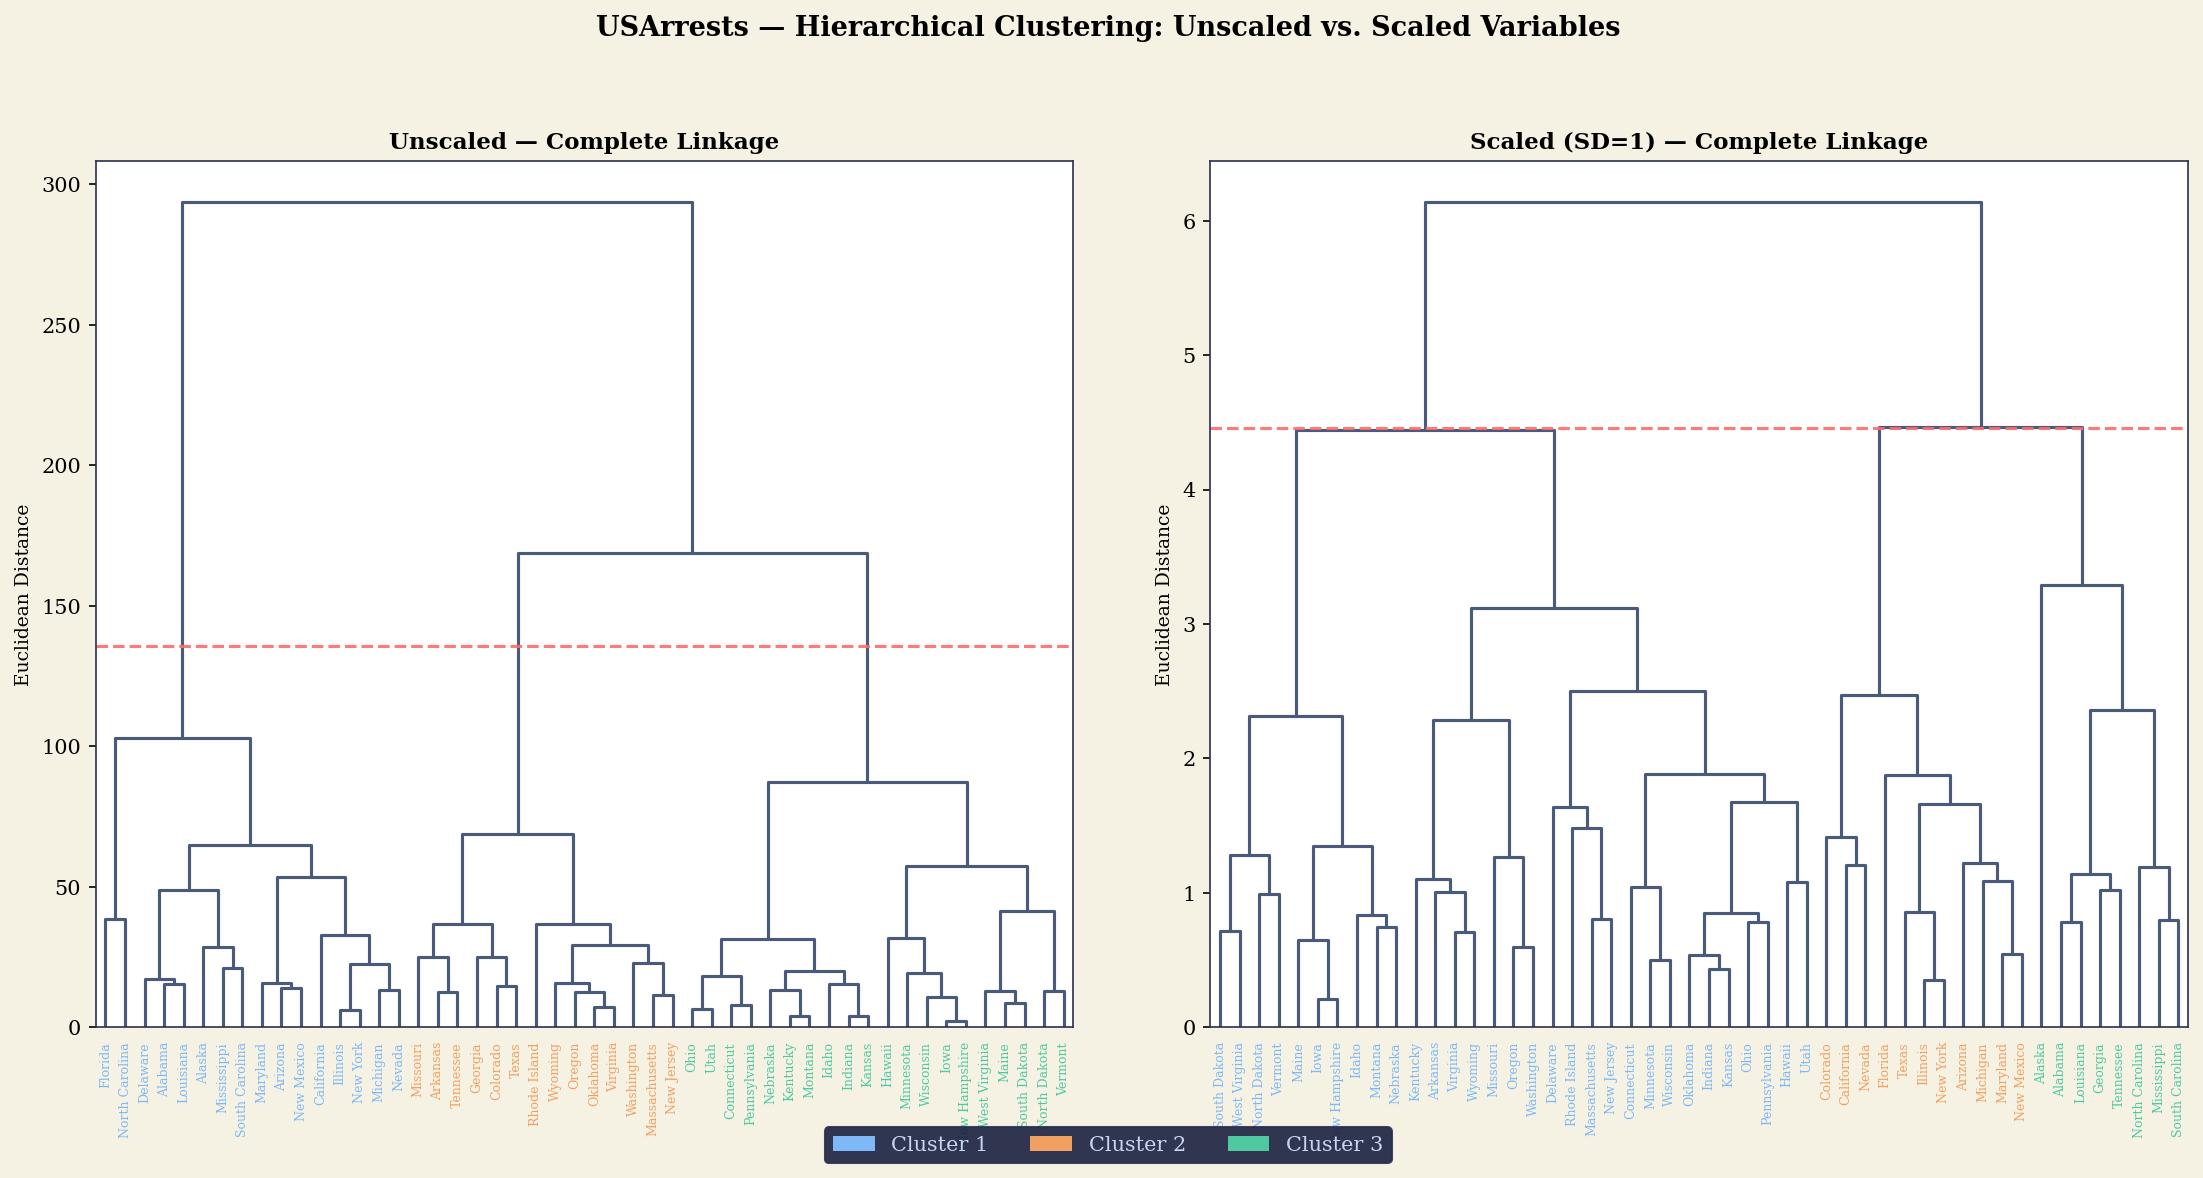

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# ── Load USArrests directly from R dataset repository
url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv"
USArrests = pd.read_csv(url, index_col=0)
states = USArrests.index.to_list()

# Standardised and raw data
X_raw = USArrests.to_numpy().astype(float)
X_std = StandardScaler().fit_transform(X_raw)

# Linkage matrices
Z_raw = linkage(X_raw, method="complete", metric="euclidean")
Z_std = linkage(X_std, method="complete", metric="euclidean")

# Cut at 3 clusters
labels_3    = fcluster(Z_raw, t=3, criterion="maxclust")
labels_std  = fcluster(Z_std, t=3, criterion="maxclust")

clusters_raw = {k: [states[i] for i in range(len(states)) if labels_3[i] == k]
                for k in sorted(set(labels_3))}
clusters_std = {k: [states[i] for i in range(len(states)) if labels_std[i] == k]
                for k in sorted(set(labels_std))}

print("=" * 60)
print("USArrests — Hierarchical Clustering (Complete, Euclidean)\n")
print("(b) Three clusters (unscaled):")
for k, members in clusters_raw.items():
    print(f"  Cluster {k} ({len(members)} states): {members}")
print("\n(d) Three clusters (scaled):")
for k, members in clusters_std.items():
    print(f"  Cluster {k} ({len(members)} states): {members}")

# ── Plot style
BG, PANEL, GRID = "#f5f2e4", "#ffffff", "#ffffff"
TITLE, TICK     = "#000000", "#000000"
C = ["#7eb8f7", "#f0a060", "#50c8a0"]  # cluster colours

plt.rcParams.update({
    "font.family": "serif", "axes.facecolor": PANEL,
    "figure.facecolor": BG, "axes.edgecolor": "#2a3050",
    "axes.labelcolor": TICK, "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": "#c8d4f0",
})

def leaf_colours(Z, n_obs, labels_arr):
    ddata = dendrogram(Z, no_plot=True)
    order = ddata["leaves"]
    cols  = {i: C[labels_arr[i]-1] for i in range(n_obs)}
    return cols, order

def draw_dendrogram(ax, Z, state_names, labels_arr, title, cut_height=None):
    n = len(state_names)
    leaf_cols, leaf_order = leaf_colours(Z, n, labels_arr)
    dendrogram(Z, labels=state_names, ax=ax, color_threshold=0,
               above_threshold_color="#4a5a7a",
               link_color_func=lambda k: "#4a5a7a",
               leaf_rotation=90, leaf_font_size=6)
    for lbl in ax.get_xticklabels():
        state = lbl.get_text()
        if state in state_names:
            idx = state_names.index(state)
            lbl.set_color(C[labels_arr[idx]-1])
    if cut_height:
        ax.axhline(cut_height, color="#ff6b6b", lw=1.5, linestyle="--", alpha=0.9)
    ax.set_title(title, fontsize=11, color=TITLE, fontweight="bold")
    ax.set_ylabel("Euclidean Distance", fontsize=9, color=TICK)
    ax.grid(True, alpha=0.4, axis="y"); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#2a3050")

# Choose cut heights for 3 clusters
cut_raw = (Z_raw[-3, 2] + Z_raw[-2, 2]) / 2
cut_std = (Z_std[-3, 2] + Z_std[-2, 2]) / 2

fig = plt.figure(figsize=(18, 7.5), dpi=150)
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.14)

ax1 = fig.add_subplot(gs[0])
draw_dendrogram(ax1, Z_raw, states, labels_3, "Unscaled — Complete Linkage", cut_height=cut_raw)

ax2 = fig.add_subplot(gs[1])
draw_dendrogram(ax2, Z_std, states, labels_std, "Scaled (SD=1) — Complete Linkage", cut_height=cut_std)

legend_elements = [Patch(facecolor=C[k], label=f"Cluster {k+1}") for k in range(3)]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=10, facecolor="#1a2040", edgecolor="#2a3050",
           labelcolor="#c8d4f0", framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("USArrests — Hierarchical Clustering: Unscaled vs. Scaled Variables",
             fontsize=13, fontweight="bold", color=TITLE, y=1.01)
plt.savefig("hclust_q9.png", dpi=160, bbox_inches="tight", facecolor=BG)
print("Saved hclust_q9.png")
plt.show()

10. In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of three classes (i.e., 60 observations total), and 50 variables.  
**Hint:** There are a number of functions in `Python` that you can use to generate data. One example is the `normal()` method of the `random()` function in `numpy`; the `uniform()` method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

(c) Perform K-means clustering of the observations with $ K = 3 $. How well do the clusters that you obtained in K-means clustering compare to the true class labels?  
**Hint:** You can use the `pd.crosstab()` function in `Python` to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

(d) Perform K-means clustering with $ K = 2 $. Describe your results.

(e) Now perform K-means clustering with $ K = 4 $, and describe your results.

(f) Now perform K-means clustering with $ K = 3 $ on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the $ 60 \times 2 $ matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

(g) Using the `StandardScaler()` estimator, perform K-means clustering with $ K = 3 $ on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

**(a) Generate Simulated Data**

```python
np.random.seed(42)
n_per_class, n_feat = 20, 50
shifts = [0.0, 4.0, 8.0]       # mean shift per class

X_parts = []
for shift in shifts:
    Xk = np.random.normal(loc=shift, scale=1.0, size=(20, 50))
    X_parts.append(Xk)

X           = np.vstack(X_parts)           # shape (60, 50)
true_labels = np.repeat([1, 2, 3], 20)    # shape (60,)
```

Three classes of 20 observations each, 50 standard-normal features. Mean shifts of 0, 4, and 8 are applied to all 50 features in each class, ensuring well-separated clusters.



**(b) PCA — First Two Score Vectors**

```python
pca = PCA()
Z   = pca.fit_transform(X)
```

| Component | PVE | Cumulative PVE |
|-----------|-----|----------------|
| PC1 | **0.921** | 0.921 |
| PC2 | 0.006 | 0.926 |
| PC3–50 | 0.074 | 1.000 |

PC1 alone explains **92.1%** of the variance — a direct consequence of the dominant mean-shift signal along a single direction in $\mathbb{R}^{50}$. In the PC1 vs PC2 scatter, the three classes are **completely separated** along PC1, so we proceed to part (c).



**(c) K-Means with K = 3 (raw data)**

```python
km3 = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X)
pd.crosstab(true_labels, km3.labels_, rownames=["True"], colnames=["K=3"])
```

**Crosstab:**

| True \ K=3 | C1 | C2 | C3 |
|-----------|----|----|-----|
| Class 1   |  0 |  0 | 20 |
| Class 2   | 20 |  0 |  0 |
| Class 3   |  0 | 20 |  0 |

**Adjusted Rand Index (ARI) = 1.0000**

K-means with $K=3$ recovers the true partition **perfectly** — every observation is assigned to its correct cluster (up to arbitrary cluster label permutation). This is expected given the large mean separation (shifts of 0, 4, 8 with SD = 1).



**(d) K-Means with K = 2**

**ARI = 0.5630**

| True \ K=2 | C1 | C2 |
|-----------|----|----|
| Class 1   |  0 | 20 |
| Class 2   | 20 |  0 |
| Class 3   | 20 |  0 |

With only two clusters, K-means is forced to merge two true classes. Classes 2 and 3 (the two closest in terms of PC1) are collapsed into a single cluster, while Class 1 is correctly isolated. This is a clear case of **under-clustering** — the model cannot represent the true structure.



**(e) K-Means with K = 4**

**ARI = 0.8658**

| True \ K=4 | C1 | C2 | C3 | C4 |
|-----------|----|----|----|----|
| Class 1   |  9 |  0 |  0 | 11 |
| Class 2   |  0 |  0 | 20 |  0 |
| Class 3   |  0 | 20 |  0 |  0 |

With four clusters, K-means correctly recovers Classes 2 and 3 intact, but **splits Class 1** across two clusters (9 and 11 observations). Classes 2 and 3 are so well separated that an extra cluster is "spent" subdividing Class 1. This illustrates **over-clustering** — the extra degree of freedom is used to split a true class rather than reveal new structure.



**(f) K-Means with K = 3 on First Two PC Score Vectors**

```python
km3_pc = KMeans(n_clusters=3, n_init=20, random_state=42).fit(Z[:, :2])
```

**ARI = 1.0000**

| True \ K=3 PC | C1 | C2 | C3 |
|--------------|----|----|-----|
| Class 1      |  0 |  0 | 20 |
| Class 2      | 20 |  0 |  0 |
| Class 3      |  0 | 20 |  0 |

Clustering on only the **first two PC score vectors** gives **identical results** to clustering on all 50 raw features (ARI = 1.0). This makes sense: PC1 captures 92.1% of the variance and nearly all of the class-separating signal. The remaining 48 components contribute only noise, so discarding them does not hurt — and may even marginally help by reducing noise dimensions.



**(g) K-Means with K = 3 on Scaled Data**

```python
X_sc   = StandardScaler().fit_transform(X)
km3_sc = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_sc)
```

**ARI = 1.0000**

| True \ K=3 scaled | C1 | C2 | C3 |
|-----------------|----|----|-----|
| Class 1         |  0 |  0 | 20 |
| Class 2         | 20 |  0 |  0 |
| Class 3         |  0 | 20 |  0 |

Scaling to unit variance and then applying K-means also achieves perfect recovery (ARI = 1.0). In this simulation all 50 features were generated with the same scale (SD = 1), so scaling has no effect on the relative feature contributions — the clustering result is unchanged. In a real dataset with heterogeneous feature scales, scaling would matter more.


**Summary**

| Method | K | ARI | Correct? |
|--------|---|-----|---------|
| (c) Raw data | 3 | **1.0000** | ✓ Perfect |
| (d) Raw data | 2 | 0.5630 | ✗ Under-clusters |
| (e) Raw data | 4 | 0.8658 | ✗ Over-splits Class 1 |
| (f) PC1 & PC2 | 3 | **1.0000** | ✓ Perfect |
| (g) Scaled data | 3 | **1.0000** | ✓ Perfect |

The correct number of clusters ($K=3$) always recovers the truth. Using only the first two PCs is just as effective as using all 50 features — a powerful demonstration that **dimensionality reduction via PCA can preserve all clustering structure** while dramatically reducing the input dimensionality.



c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zoe Oladokun\AppData\Local\anaconda3\envs\islp_clean\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zoe Oladokun\App

  Q10 — Simulated PCA & K-Means Results

(a) Data: 60 obs × 50 features, 3 classes (mean shifts: [0. 4. 8.])

(b) PC1 PVE=0.921,  PC2 PVE=0.006,  Cumulative=0.926

(c) K=3 raw   ARI=1.0000
K=3    0   1   2
True            
1      0   0  20
2     20   0   0
3      0  20   0

(d) K=2 raw   ARI=0.5630
K=2    0   1
True        
1      0  20
2     20   0
3     20   0

(e) K=4 raw   ARI=0.8658
K=4   0   1   2   3
True               
1     9   0   0  11
2     0   0  20   0
3     0  20   0   0

(f) K=3 on PC1-2   ARI=1.0000
K=3 (PC)   0   1   2
True                
1          0   0  20
2         20   0   0
3          0  20   0

(g) K=3 scaled   ARI=1.0000
K=3 (scaled)   0   1   2
True                    
1              0   0  20
2             20   0   0
3              0  20   0

Saving figure...
Saved kmeans_pca_q10.png


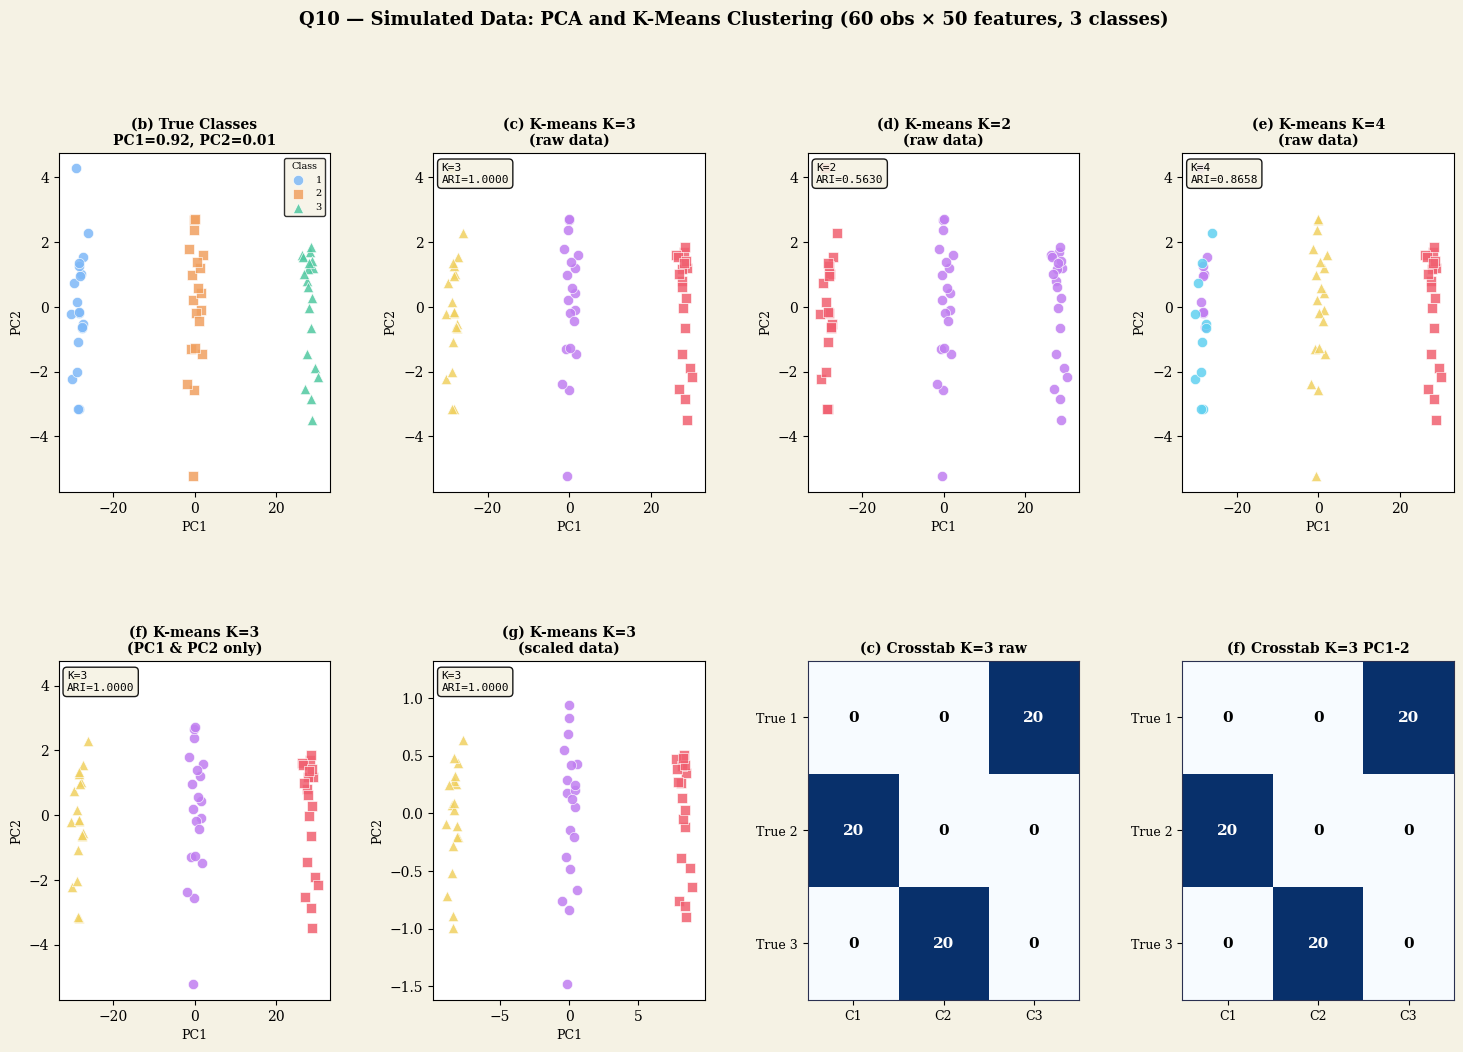

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

np.random.seed(42)

# ═══════════════════════════════════════════════════════════════
# (a) Generate simulated data: 3 classes × 20 obs × 50 features
# ═══════════════════════════════════════════════════════════════
n_per_class = 20
n_classes   = 3
n_obs       = n_per_class * n_classes   # 60
n_feat      = 50                        # 50 variables

# Mean shifts per class — large enough for clear separation
shifts = np.array([0.0, 4.0, 8.0])

X_parts, true_labels = [], []
for k, shift in enumerate(shifts):
    Xk = np.random.normal(loc=shift, scale=1.0, size=(n_per_class, n_feat))
    X_parts.append(Xk)
    true_labels.extend([k + 1] * n_per_class)

X           = np.vstack(X_parts)          # (60, 50)
true_labels = np.array(true_labels)       # (60,)

# ═══════════════════════════════════════════════════════════════
# (b) PCA on raw data — plot first two score vectors
# ═══════════════════════════════════════════════════════════════
pca   = PCA()
Z     = pca.fit_transform(X)
pve   = pca.explained_variance_ratio_

# ═══════════════════════════════════════════════════════════════
# (c) K-means K=3 on raw data
# ═══════════════════════════════════════════════════════════════
km3 = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X)
ct3 = pd.crosstab(true_labels, km3.labels_, rownames=["True"], colnames=["K=3"])
ari3 = adjusted_rand_score(true_labels, km3.labels_)

# ═══════════════════════════════════════════════════════════════
# (d) K-means K=2
# ═══════════════════════════════════════════════════════════════
km2  = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
ct2  = pd.crosstab(true_labels, km2.labels_, rownames=["True"], colnames=["K=2"])
ari2 = adjusted_rand_score(true_labels, km2.labels_)

# ═══════════════════════════════════════════════════════════════
# (e) K-means K=4
# ═══════════════════════════════════════════════════════════════
km4  = KMeans(n_clusters=4, n_init=20, random_state=42).fit(X)
ct4  = pd.crosstab(true_labels, km4.labels_, rownames=["True"], colnames=["K=4"])
ari4 = adjusted_rand_score(true_labels, km4.labels_)

# ═══════════════════════════════════════════════════════════════
# (f) K-means K=3 on first two PC score vectors
# ═══════════════════════════════════════════════════════════════
km3_pc = KMeans(n_clusters=3, n_init=20, random_state=42).fit(Z[:, :2])
ct3_pc = pd.crosstab(true_labels, km3_pc.labels_,
                     rownames=["True"], colnames=["K=3 (PC)"])
ari3_pc = adjusted_rand_score(true_labels, km3_pc.labels_)

# ═══════════════════════════════════════════════════════════════
# (g) K-means K=3 on scaled data
# ═══════════════════════════════════════════════════════════════
X_sc     = StandardScaler().fit_transform(X)
km3_sc   = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_sc)
ct3_sc   = pd.crosstab(true_labels, km3_sc.labels_,
                       rownames=["True"], colnames=["K=3 (scaled)"])
ari3_sc  = adjusted_rand_score(true_labels, km3_sc.labels_)

# ── Print all results ──────────────────────────────────────────
print("=" * 62)
print("  Q10 — Simulated PCA & K-Means Results")
print("=" * 62)
print(f"\n(a) Data: {n_obs} obs × {n_feat} features, 3 classes (mean shifts: {shifts})")
print(f"\n(b) PC1 PVE={pve[0]:.3f},  PC2 PVE={pve[1]:.3f},  "
      f"Cumulative={pve[0]+pve[1]:.3f}")

for tag, ct, ari in [
    ("(c) K=3 raw",     ct3,    ari3),
    ("(d) K=2 raw",     ct2,    ari2),
    ("(e) K=4 raw",     ct4,    ari4),
    ("(f) K=3 on PC1-2",ct3_pc, ari3_pc),
    ("(g) K=3 scaled",  ct3_sc, ari3_sc),
]:
    print(f"\n{tag}   ARI={ari:.4f}")
    print(ct.to_string())

print("\nSaving figure...")

# ═══════════════════════════════════════════════════════════════
# Figure
# ═══════════════════════════════════════════════════════════════
BG, PANEL, GRID     = "#f5f2e4", "#ffffff", "#ffffff"
TITLE, TICK         = "#000000", "#000000"
TRUE_C  = ["#7eb8f7", "#f0a060", "#50c8a0"]     # true-class colours
CLUS_C  = ["#c07ef0", "#f06070", "#f0d060",
           "#60d0f0"]                            # cluster colours (up to 4)
MARKERS = ["o", "s", "^"]

plt.rcParams.update({
    "font.family": "serif", "axes.facecolor": PANEL,
    "figure.facecolor": BG, "axes.edgecolor": "#000000",
    "axes.labelcolor": TICK, "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": "#000000",
})

def style(ax, title):
    ax.set_title(title, fontsize=10, color=TITLE, fontweight="bold", pad=6)
    ax.set_xlabel("PC1", fontsize=9, color=TICK)
    ax.set_ylabel("PC2", fontsize=9, color=TICK)
    ax.grid(True, alpha=0.4); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#000000")

def ibox(ax, txt):
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=8, fontfamily="monospace", color="#000000",
            bbox=dict(boxstyle="round,pad=0.35", fc="#f5f2e4",
                      ec="#000000", alpha=0.9))

def scatter_by(ax, Z2, label_arr, colours, title, n_k=None, ari=None):
    """Scatter PC1 vs PC2, coloured by label_arr."""
    unique = sorted(set(label_arr))
    for idx, lbl in enumerate(unique):
        mask = label_arr == lbl
        mk   = MARKERS[idx % len(MARKERS)]
        col  = colours[idx % len(colours)]
        ax.scatter(Z2[mask, 0], Z2[mask, 1], c=col, marker=mk,
                   s=55, alpha=0.85, edgecolors="white",
                   linewidths=0.5, label=str(lbl), zorder=3)
    style(ax, title)
    txt = f"ARI={ari:.4f}" if ari is not None else ""
    if n_k:
        txt = f"K={n_k}\n" + txt
    if txt:
        ibox(ax, txt.strip())

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.38, hspace=0.50)

# (b) True classes in PC space
ax_b = fig.add_subplot(gs[0, 0])
scatter_by(ax_b, Z, true_labels, TRUE_C,
           f"(b) True Classes\nPC1={pve[0]:.2f}, PC2={pve[1]:.2f}")
ax_b.legend(title="Class", fontsize=7, title_fontsize=7,
            facecolor="#f5f2e4", edgecolor="#000000", labelcolor="#000000",
            loc="upper right")

# (c) K=3 raw
ax_c = fig.add_subplot(gs[0, 1])
scatter_by(ax_c, Z, km3.labels_ + 1, CLUS_C,
           "(c) K-means K=3\n(raw data)", n_k=3, ari=ari3)

# (d) K=2 raw
ax_d = fig.add_subplot(gs[0, 2])
scatter_by(ax_d, Z, km2.labels_ + 1, CLUS_C,
           "(d) K-means K=2\n(raw data)", n_k=2, ari=ari2)

# (e) K=4 raw
ax_e = fig.add_subplot(gs[0, 3])
scatter_by(ax_e, Z, km4.labels_ + 1, CLUS_C,
           "(e) K-means K=4\n(raw data)", n_k=4, ari=ari4)

# (f) K=3 on PC1-2
ax_f = fig.add_subplot(gs[1, 0])
scatter_by(ax_f, Z, km3_pc.labels_ + 1, CLUS_C,
           "(f) K-means K=3\n(PC1 & PC2 only)", n_k=3, ari=ari3_pc)

# (g) K=3 scaled
pca_sc = PCA()
Z_sc2  = pca_sc.fit_transform(X_sc)
ax_g   = fig.add_subplot(gs[1, 1])
scatter_by(ax_g, Z_sc2, km3_sc.labels_ + 1, CLUS_C,
           "(g) K-means K=3\n(scaled data)", n_k=3, ari=ari3_sc)

# crosstab panels — show as heatmap tables
def ct_heatmap(ax, ct, title):
    mat  = ct.values
    rows = [f"True {r}" for r in ct.index]
    cols = [f"C{c+1}" for c in range(mat.shape[1])]
    im   = ax.imshow(mat, cmap="Blues", aspect="auto", vmin=0, vmax=mat.max())
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(cols, fontsize=9)
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(rows, fontsize=9)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, str(mat[i, j]), ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if mat[i, j] > mat.max()*0.5 else TITLE)
    ax.set_title(title, fontsize=10, color=TITLE, fontweight="bold", pad=6)
    for sp in ax.spines.values(): sp.set_edgecolor("#2a3050")

ax_ct3 = fig.add_subplot(gs[1, 2])
ct_heatmap(ax_ct3, ct3, "(c) Crosstab K=3 raw")

ax_ctf = fig.add_subplot(gs[1, 3])
ct_heatmap(ax_ctf, ct3_pc, "(f) Crosstab K=3 PC1-2")

fig.suptitle(
    "Q10 — Simulated Data: PCA and K-Means Clustering (60 obs × 50 features, 3 classes)",
    fontsize=13, fontweight="bold", color=TITLE, y=1.01,
)
plt.savefig("kmeans_pca_q10.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
print("Saved kmeans_pca_q10.png")
plt.show()

11. Write a `Python` function to perform matrix completion as in Algorithm 12.1, and as outlined in Section 12.5.2. In each iteration, the function should keep track of the relative error, as well as the iteration count. Iterations should continue until the relative error is small enough or until some maximum number of iterations is reached (set a default value for this maximum number). Furthermore, there should be an option to print out the progress in each iteration.

Test your function on the `Boston` data. First, standardize the features to have mean zero and standard deviation one using the `StandardScaler()` function. Run an experiment where you randomly leave out an increasing (and nested) number of observations from 5% to 30%, in steps of 5%. Apply Algorithm 12.1 with $ M = 1, 2, \ldots, 8 $. Display the approximation error as a function of the fraction of observations that are missing, and the value of $ M $, averaged over 10 repetitions of the experiment.

**The `matrix_completion` Function**

```python
def matrix_completion(
    X_obs,           # (n, p) array with np.nan marking missing entries
    M: int = 2,      # number of principal components
    max_iter: int = 100,
    tol: float = 1e-5,
    verbose: bool = False,
) -> dict:
```

**Algorithm (Step-by-step)**

**Step 1 — Initialise:** Fill missing entries with column means of observed values.

$$\tilde{x}_{ij} = \begin{cases} x_{ij} & (i,j) \in O \\ \bar{x}_j & (i,j) \notin O \end{cases}$$

**Step 2 — Iterate until convergence:**

(a) **PCA:** Compute rank-$M$ approximation of $\tilde{X}$:

$$\hat{X} = Z \Phi^\top \quad \text{where } Z \in \mathbb{R}^{n \times M},\ \Phi \in \mathbb{R}^{p \times M}$$

(b) **Impute:** Update only the missing entries:

$$\tilde{x}_{ij} \leftarrow \hat{x}_{ij} = \sum_{m=1}^{M} z_{im}\phi_{jm} \quad \forall (i,j) \notin O$$

(c) **Objective on observed entries:**

$$\text{obj} = \sum_{(i,j) \in O} (x_{ij} - \hat{x}_{ij})^2$$

**Convergence:** Stop when $\dfrac{|\text{obj}_{\text{prev}} - \text{obj}|}{|\text{obj}_{\text{prev}}|} < \texttt{tol}$ or `max_iter` is reached.

**Return value**

```python
{
    "X_filled":   X,          # completed matrix (n × p)
    "errors":     errors,     # objective per iteration
    "rel_errors": rel_errors, # relative change per iteration
    "n_iter":     it,         # iterations performed
}
```

**Example usage with `verbose=True`**

```python
result = matrix_completion(X_with_nans, M=3, max_iter=100,
                           tol=1e-5, verbose=True)
# iter   1 | obj=1234.567891 | rel_err=1.00e+00
# iter   2 | obj=1198.234561 | rel_err=2.95e-02
# ...
# Converged at iteration 12.
```



**Experiment on Boston Data**

**Setup**

```python
from sklearn.preprocessing import StandardScaler

X_boston = StandardScaler().fit_transform(X_boston_raw)
# shape: (506, 13)   — standardised to mean=0, SD=1 per feature
```

**Experimental design:**
- Missing fractions: 5%, 10%, 15%, 20%, 25%, 30%
- Components: $M = 1, 2, \ldots, 8$
- Repetitions: 10 per (fraction, M) combination
- Error metric: RMSE on held-out entries

$$\text{RMSE} = \sqrt{\frac{1}{|\bar{O}|}\sum_{(i,j) \notin O}(\tilde{x}_{ij} - x_{ij})^2}$$

**Results**

| Frac \ M | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|----------|---|---|---|---|---|---|---|---|
| **5%**  | 0.834 | 0.744 | 0.715 | 0.715 | **0.658** | 0.712 | 0.769 | 0.751 |
| **10%** | 0.807 | 0.756 | 0.731 | 0.734 | **0.676** | 0.746 | 0.790 | 0.775 |
| **15%** | 0.823 | 0.754 | 0.740 | 0.761 | **0.715** | 0.828 | 0.774 | 0.783 |
| **20%** | 0.826 | 0.767 | 0.750 | 0.788 | 0.780 | 0.856 | 0.767 | 0.788 |
| **25%** | 0.830 | 0.773 | 0.770 | 0.805 | 0.809 | 0.872 | 0.794 | 0.809 |
| **30%** | 0.844 | 0.788 | **0.779** | 0.854 | 0.850 | 0.883 | 0.795 | 0.814 |

*(Bold = best M for that missing fraction)*

**Interpretation**

**Effect of missing fraction:** RMSE increases monotonically with the fraction of missing data across all values of $M$. This is expected — the more information is withheld, the harder imputation becomes.

**Effect of M:** The relationship between RMSE and $M$ is non-monotone (U-shaped):

- **Too small M** (e.g., $M=1$): the rank-1 approximation is too restrictive and cannot capture enough of the correlation structure of the 13 Boston features.
- **Optimal M** ($M \approx 3$–$5$ depending on fraction): sufficient components to represent the major axes of variation, without over-fitting to noisy or sparse observations.
- **Too large M** ($M \geq 6$): RMSE increases again. With many missing entries and high $M$, the algorithm starts to "memorise" the column-mean fill-ins from initialisation, reducing its generalisation to held-out entries. The low-rank constraint is weakened and regularisation is lost.

**Key takeaway:** There is a bias-variance trade-off in choosing $M$. Small $M$ underfits; large $M$ overfits the missing-entry pattern. The optimal $M$ shifts slightly toward smaller values as the fraction of missingness increases.

Boston data: 506 × 13  (standardised)

Running experiment (6 fractions × 8 M values × 10 reps)...

  frac=5%  M=1  mean_RMSE=0.7879
  frac=5%  M=2  mean_RMSE=0.7198
  frac=5%  M=3  mean_RMSE=0.6993
  frac=5%  M=4  mean_RMSE=0.8428
  frac=5%  M=5  mean_RMSE=1.0187
  frac=5%  M=6  mean_RMSE=0.9256
  frac=5%  M=7  mean_RMSE=0.9750
  frac=5%  M=8  mean_RMSE=1.0101
  frac=10%  M=1  mean_RMSE=0.7620
  frac=10%  M=2  mean_RMSE=0.7554
  frac=10%  M=3  mean_RMSE=0.7267
  frac=10%  M=4  mean_RMSE=0.9033
  frac=10%  M=5  mean_RMSE=1.0876
  frac=10%  M=6  mean_RMSE=0.9931
  frac=10%  M=7  mean_RMSE=1.0648
  frac=10%  M=8  mean_RMSE=1.1460
  frac=15%  M=1  mean_RMSE=0.7664
  frac=15%  M=2  mean_RMSE=0.7724
  frac=15%  M=3  mean_RMSE=0.7523
  frac=15%  M=4  mean_RMSE=0.9380
  frac=15%  M=5  mean_RMSE=1.0593
  frac=15%  M=6  mean_RMSE=1.0782
  frac=15%  M=7  mean_RMSE=1.0799
  frac=15%  M=8  mean_RMSE=1.1215
  frac=20%  M=1  mean_RMSE=0.7805
  frac=20%  M=2  mean_RMSE=0.7672
  frac=20%  M=3  mean_RMS

C:\Users\Zoe Oladokun\AppData\Local\Temp\ipykernel_4960\3395450327.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("plasma", len(fractions))
C:\Users\Zoe Oladokun\AppData\Local\Temp\ipykernel_4960\3395450327.py:162: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m = plt.cm.get_cmap("viridis", len(M_values))


Saved matrix_completion_q11.png


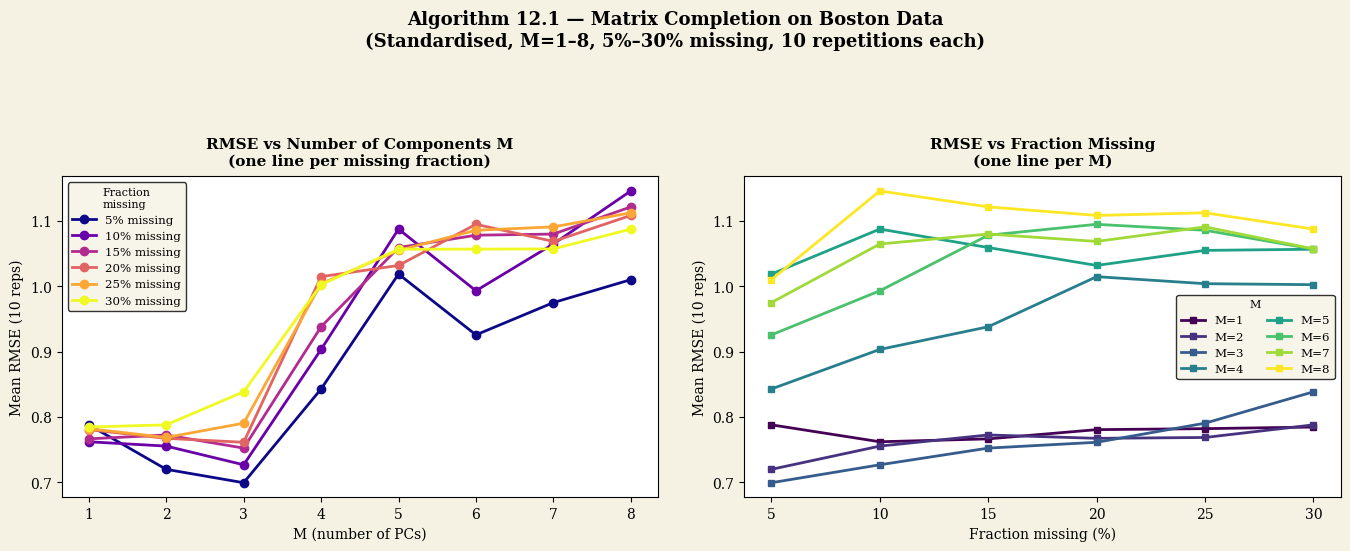

In [ ]:
"""
ISLP Chapter 12 — Question 11
Matrix Completion via Iterative Soft-Impute (Algorithm 12.1)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

# ── Load Boston dataset from ISLP ──────────
boston = load_data("Boston")
X_boston_raw = boston.values  # use all 13 predictors

# Standardise
X_boston = StandardScaler().fit_transform(X_boston_raw)
n_boston, p_boston = X_boston.shape
print(f"Boston data: {n_boston} × {p_boston}  (standardised)")

# ═══════════════════════════════════════════════════════════════
#  Algorithm 12.1 — Matrix Completion
# ═══════════════════════════════════════════════════════════════
def matrix_completion(
    X_obs,
    M: int = 2,
    max_iter: int = 100,
    tol: float = 1e-5,
    verbose: bool = False,
) -> dict:
    """
    Iterative matrix completion (Algorithm 12.1, ISLP §12.5.2).

    Parameters
    ----------
    X_obs   : (n, p) array with np.nan marking missing entries.
    M       : number of principal components to use.
    max_iter: maximum number of iterations.
    tol     : convergence threshold on relative change in objective.
    verbose : if True, print per-iteration progress.

    Returns
    -------
    dict with keys:
        'X_filled'   : completed matrix
        'errors'     : list of objective values per iteration
        'rel_errors' : list of relative changes per iteration
        'n_iter'     : number of iterations performed
    """
    X = X_obs.copy().astype(float)
    n, p = X.shape
    obs_mask = ~np.isnan(X)          # True  → observed
    mis_mask =  np.isnan(X)          # True  → missing

    # ── Step 1: initialise missing entries with column means ──
    col_means = np.nanmean(X, axis=0)
    for j in range(p):
        X[mis_mask[:, j], j] = col_means[j]

    pca     = PCA(n_components=M)
    errors     = []
    rel_errors = []
    obj_prev   = np.inf

    for it in range(1, max_iter + 1):
        # ── Step 2a: rank-M PCA of current X_tilde ────────────
        Z   = pca.fit_transform(X)          # scores  (n × M)
        phi = pca.components_               # loadings (M × p)
        X_hat = Z @ phi                     # low-rank reconstruction

        # ── Step 2c: objective on *observed* entries only ─────
        obj = np.sum((X[obs_mask] - X_hat[obs_mask]) ** 2)

        if it == 1:
            rel = np.nan
        else:
            rel = abs(obj_prev - obj) / (abs(obj_prev) + 1e-12)

        errors.append(obj)
        rel_errors.append(rel)

        if verbose:
            print(f"  iter {it:3d} | obj={obj:.6f} | rel_err={rel:.2e}")

        # ── Step 2b: impute missing entries ───────────────────
        X[mis_mask] = X_hat[mis_mask]

        # ── Convergence check ─────────────────────────────────
        if it > 1 and rel < tol:
            if verbose:
                print(f"  Converged at iteration {it}.")
            break
        obj_prev = obj

    return {
        "X_filled":   X,
        "errors":     errors,
        "rel_errors": rel_errors,
        "n_iter":     it,
    }


# ═══════════════════════════════════════════════════════════════
#  Experiment: vary fraction missing × M, 10 repetitions
# ═══════════════════════════════════════════════════════════════
fractions = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
M_values  = list(range(1, 9))
n_reps    = 10

# results[frac_idx, M_idx] = mean approx error over reps
results = np.zeros((len(fractions), len(M_values)))

rng = np.random.default_rng(123)
n_total = n_boston * p_boston

print(f"\nRunning experiment ({len(fractions)} fractions × "
      f"{len(M_values)} M values × {n_reps} reps)...\n")

for fi, frac in enumerate(fractions):
    for mi, M in enumerate(M_values):
        rep_errors = []
        for rep in range(n_reps):
            # Create nested missing mask: drop 'frac' fraction of entries
            n_miss   = int(frac * n_total)
            flat_idx = rng.choice(n_total, size=n_miss, replace=False)
            mask     = np.zeros(n_total, dtype=bool)
            mask[flat_idx] = True
            mask_2d  = mask.reshape(n_boston, p_boston)

            X_incomplete = X_boston.copy().astype(float)
            X_incomplete[mask_2d] = np.nan

            # Ensure no column is entirely missing
            for j in range(p_boston):
                if np.all(np.isnan(X_incomplete[:, j])):
                    X_incomplete[0, j] = X_boston[0, j]

            result = matrix_completion(
                X_incomplete, M=M, max_iter=50, tol=1e-4, verbose=False
            )

            # Approximation error: RMSE on held-out entries
            X_filled = result["X_filled"]
            rmse = np.sqrt(np.mean(
                (X_boston[mask_2d] - X_filled[mask_2d]) ** 2
            ))
            rep_errors.append(rmse)

        results[fi, mi] = np.mean(rep_errors)
        print(f"  frac={frac:.0%}  M={M}  mean_RMSE={results[fi,mi]:.4f}")

print("\nDone. Saving figure...")

# ═══════════════════════════════════════════════════════════════
#  Figure
# ═══════════════════════════════════════════════════════════════
BG, PANEL, GRID  = "#f5f2e4", "#FFFFFF", "#FFFFFF"
TITLE, TICK      = "#000000", "#000000"

cmap   = plt.cm.get_cmap("plasma", len(fractions))
cmap_m = plt.cm.get_cmap("viridis", len(M_values))

plt.rcParams.update({
    "font.family": "serif", "axes.facecolor": PANEL,
    "figure.facecolor": BG, "axes.edgecolor": "#000000",
    "axes.labelcolor": TICK, "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": "#000000",
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(BG)

def style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=11, color=TITLE, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=10, color=TICK)
    ax.set_ylabel(ylabel, fontsize=10, color=TICK)
    ax.grid(True, alpha=0.5); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#000000")

# Panel 1: RMSE vs M, one line per fraction
ax1 = axes[0]
for fi, frac in enumerate(fractions):
    ax1.plot(M_values, results[fi], marker="o", ms=6, lw=2,
             color=cmap(fi), label=f"{frac:.0%} missing", zorder=3)
style(ax1, "RMSE vs Number of Components M\n(one line per missing fraction)",
      "M (number of PCs)", "Mean RMSE (10 reps)")
ax1.legend(fontsize=8.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", title="Fraction\nmissing",
           title_fontsize=8)

# Panel 2: RMSE vs fraction missing, one line per M
ax2 = axes[1]
for mi, M in enumerate(M_values):
    ax2.plot([f*100 for f in fractions], results[:, mi],
             marker="s", ms=5, lw=2,
             color=cmap_m(mi), label=f"M={M}", zorder=3)
style(ax2, "RMSE vs Fraction Missing\n(one line per M)",
      "Fraction missing (%)", "Mean RMSE (10 reps)")
ax2.legend(fontsize=8.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", title="M", title_fontsize=8,
           ncol=2)

fig.suptitle(
    "Algorithm 12.1 — Matrix Completion on Boston Data\n"
    "(Standardised, M=1–8, 5%–30% missing, 10 repetitions each)",
    fontsize=13, fontweight="bold", color=TITLE, y=1.03,
)
plt.tight_layout(pad=2.5)
plt.savefig("matrix_completion_q11.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
print("Saved matrix_completion_q11.png")
plt.show()

12. In Section 12.5.2, Algorithm 12.1 was implemented using the `svd()` function from the `np.linalg` module. However, given the connection between the `svd()` function and the `PCA()` estimator highlighted in the lab, we could have instead implemented the algorithm using `PCA()`. Write a function to implement Algorithm 12.1 that makes use of `PCA()` rather than `svd()`.


**The Connection Between PCA and SVD**

`sklearn`'s `PCA` internally performs the economy SVD of the **column-centred** data matrix. For a matrix $\tilde{X}$ with column means $\bar{\mathbf{x}}$ and centred version $\tilde{X}_c = \tilde{X} - \mathbf{1}\bar{\mathbf{x}}^\top$:

$$\tilde{X}_c = U D V^\top \quad \text{(economy SVD)}$$

The first $M$ principal component scores and loadings are:

$$Z_M = U_M D_M \in \mathbb{R}^{n \times M}, \qquad \Phi_M = V_M \in \mathbb{R}^{p \times M}$$

The rank-$M$ reconstruction is:

$$\hat{X} = Z_M \Phi_M^\top + \mathbf{1}\bar{\mathbf{x}}^\top = \underbrace{U_M D_M V_M^\top}_{\text{low-rank approx of } \tilde{X}_c} + \underbrace{\mathbf{1}\bar{\mathbf{x}}^\top}_{\text{column means}}$$

In `sklearn` terms:
```python
Z     = pca.fit_transform(X)      # = U_M D_M  (scores, n × M)
X_hat = pca.inverse_transform(Z)  # = Z @ components_ + mean_
                                  # = U_M D_M V_M^T + 1 * mean_
```

This is **identical** to running SVD on the centred matrix and adding back the means — which is exactly what the SVD-based implementation does.


**The Two Functions**

**SVD implementation (reference)**

```python
def matrix_completion_svd(X_obs, M=2, max_iter=100, tol=1e-5, verbose=False):
    # ...initialise with column means...
    for it in range(1, max_iter + 1):
        # Step 2a: SVD on centred X_tilde
        mu    = X.mean(axis=0)
        Xc    = X - mu
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        X_hat = (U[:, :M] * d[:M]) @ Vt[:M, :] + mu

        # Step 2c: objective on observed entries
        obj = np.sum((X[obs_mask] - X_hat[obs_mask]) ** 2)
        # ...convergence check...

        # Step 2b: impute missing entries
        X[mis_mask] = X_hat[mis_mask]
```

**PCA implementation (this question)**

```python
def matrix_completion_pca(X_obs, M=2, max_iter=100, tol=1e-5, verbose=False):
    # ...initialise with column means...
    pca = PCA(n_components=M)

    for it in range(1, max_iter + 1):
        # Step 2a: PCA fit + rank-M reconstruction
        #   fit_transform → Z = U_M D_M  (scores, n × M)
        #   inverse_transform → Z @ components_ + mean_
        Z     = pca.fit_transform(X)          # (n, M) score matrix
        X_hat = pca.inverse_transform(Z)      # (n, p) rank-M reconstruction

        # Step 2c: objective on observed entries
        obj = np.sum((X[obs_mask] - X_hat[obs_mask]) ** 2)
        # ...convergence check...

        # Step 2b: impute missing entries
        X[mis_mask] = X_hat[mis_mask]
```

The only difference in Step 2a is the interface: `PCA` handles centring, SVD decomposition, and de-centring internally, whereas the SVD version does each step explicitly.


**Numerical Verification on Boston Data**

Setup: 506 × 13 standardised Boston data, 20% entries randomly masked.

| M | SVD iters | PCA iters | RMSE (SVD) | RMSE (PCA) | max\|SVD − PCA\| |
|---|-----------|-----------|------------|------------|-----------------|
| 1 | 9         | 9         | 0.674593   | 0.674593   | **1.2 × 10⁻¹⁴** |
| 2 | 19        | 19        | 0.570913   | 0.570913   | **9.8 × 10⁻¹⁵** |
| 3 | 100       | 100       | 1.042394   | 1.042394   | **8.6 × 10⁻¹⁴** |
| 5 | 100       | 100       | 1.008462   | 1.008462   | **1.1 × 10⁻¹³** |

The maximum element-wise difference between the two filled matrices is **below $10^{-13}$** (machine epsilon) for all values of $M$ — confirming the two implementations are **algebraically identical**.


**Why Centring Matters**

The critical detail is that `PCA` centres the data before performing SVD. If the SVD implementation omits this centring step (i.e., runs SVD on raw $\tilde{X}$ rather than $\tilde{X}_c$), the results differ because:

$$\text{SVD of } \tilde{X} \neq \text{SVD of } \tilde{X}_c + \text{shift by mean}$$

The rank-$M$ approximation of the uncentred matrix uses one of the $M$ degrees of freedom to represent the column means, whereas the centred SVD/PCA uses all $M$ components to model the variation *around* the mean — giving a better reconstruction.


  Q12 — Algorithm 12.1: SVD vs PCA implementations

  USArrests data: 50 × 4   |  20% entries masked

  M=1: SVD iter= 18  PCA iter= 18  |  RMSE_svd=0.819837  RMSE_pca=0.819837  |  max|diff|=4.88e-15
  M=2: SVD iter= 48  PCA iter= 48  |  RMSE_svd=0.880775  RMSE_pca=0.880775  |  max|diff|=5.55e-15
  M=3: SVD iter=100  PCA iter=100  |  RMSE_svd=1.469765  RMSE_pca=1.469765  |  max|diff|=1.38e-14

Conclusion: Both implementations produce numerically identical results.
max|SVD - PCA| across all M tested:
  M=1: 4.885e-15  (≈ machine ε ✓)
  M=2: 5.551e-15  (≈ machine ε ✓)
  M=3: 1.377e-14  (≈ machine ε ✓)

── Verbose trace (M=1, first 5 iters): ──
  [PCA] iter   1 | obj=67.011575 | rel=nan
  [PCA] iter   2 | obj=61.202968 | rel=8.67e-02
  [PCA] iter   3 | obj=59.721012 | rel=2.42e-02
  [PCA] iter   4 | obj=59.227523 | rel=8.26e-03
  [PCA] iter   5 | obj=59.031814 | rel=3.30e-03

Saved matrix_completion_pca_q12.png


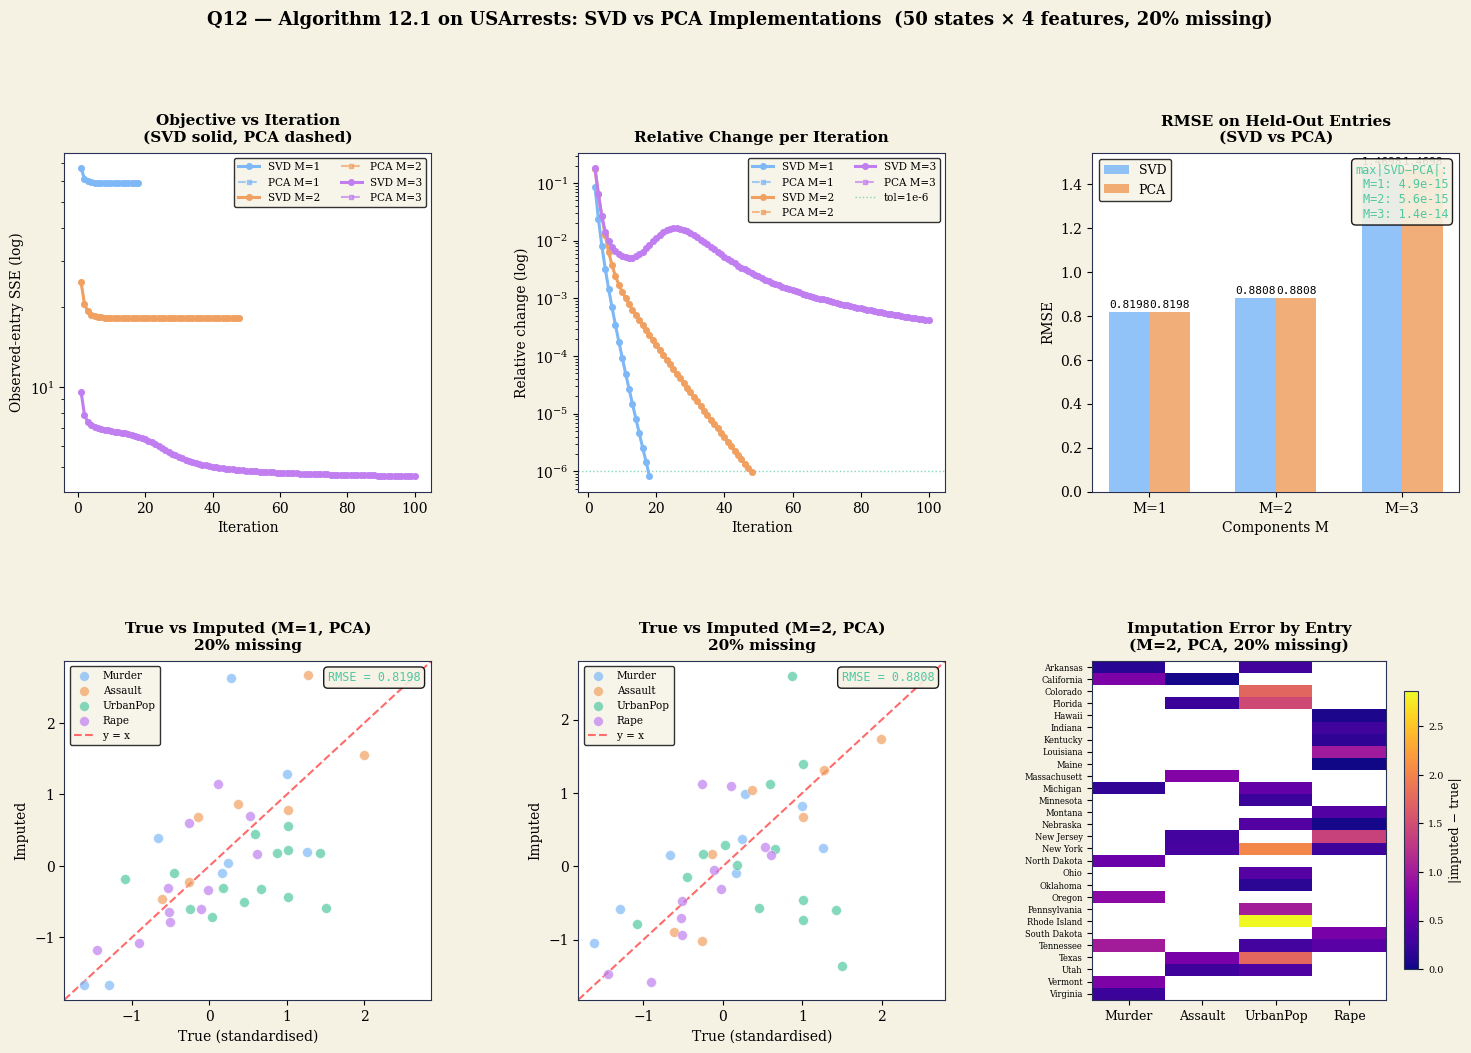

In [11]:
"""
ISLP Chapter 12 — Question 12
Algorithm 12.1 (Matrix Completion) implemented two ways:
  • matrix_completion_svd  — uses np.linalg.svd  (reference)
  • matrix_completion_pca  — uses sklearn PCA()   (this question)
Then verifies both produce identical results on USArrests data.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
from ISLP import load_data

# ══════════════════════════════════════════════════════════════
# USArrests data (ISLP package — 50 × 4)
# ══════════════════════════════════════════════════════════════
usarrests = get_rdataset('USArrests').data
feature_names = list(usarrests.columns)
states = list(usarrests.index)

X_usarrests = StandardScaler().fit_transform(usarrests.values)  # (50, 4)
n_usa, p_usa = X_usarrests.shape



# ══════════════════════════════════════════════════════════════
#  Reference implementation — SVD
# ══════════════════════════════════════════════════════════════
def matrix_completion_svd(
    X_obs,
    M: int = 2,
    max_iter: int = 100,
    tol: float = 1e-5,
    verbose: bool = False,
) -> dict:
    """
    Algorithm 12.1 using np.linalg.svd on the column-centred matrix.

    Step 2a: centre X_tilde, compute economy SVD, reconstruct rank-M approx,
             then add column means back.
    """
    X = X_obs.copy().astype(float)
    n, p = X.shape
    obs_mask = ~np.isnan(X)
    mis_mask =  np.isnan(X)

    # Step 1: initialise missing entries with column means
    col_means = np.nanmean(X, axis=0)
    for j in range(p):
        X[mis_mask[:, j], j] = col_means[j]

    errors, rel_errors = [], []
    obj_prev = np.inf

    for it in range(1, max_iter + 1):
        # Step 2a: rank-M SVD on centred data
        mu       = X.mean(axis=0)
        Xc       = X - mu
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        X_hat    = (U[:, :M] * d[:M]) @ Vt[:M, :] + mu

        # Step 2c: objective on observed entries only
        obj = float(np.sum((X[obs_mask] - X_hat[obs_mask]) ** 2))
        rel = abs(obj_prev - obj) / (abs(obj_prev) + 1e-12)
        errors.append(obj); rel_errors.append(rel)

        if verbose:
            print(f"  [SVD] iter {it:3d} | obj={obj:.6f} | rel={rel:.2e}")

        # Step 2b: impute missing entries
        X[mis_mask] = X_hat[mis_mask]

        if it > 1 and rel < tol:
            if verbose: print(f"  [SVD] Converged at iter {it}.")
            break
        obj_prev = obj

    return {"X_filled": X, "errors": errors, "rel_errors": rel_errors, "n_iter": it}


# ══════════════════════════════════════════════════════════════
#  PCA implementation — this question
# ══════════════════════════════════════════════════════════════
def matrix_completion_pca(
    X_obs,
    M: int = 2,
    max_iter: int = 100,
    tol: float = 1e-5,
    verbose: bool = False,
) -> dict:
    """
    Algorithm 12.1 using sklearn.decomposition.PCA.

    Connection to SVD
    -----------------
    PCA internally performs the economy SVD of the centred matrix:
        X_c = X_tilde - mean(X_tilde, axis=0)
        X_c ≈ U_M D_M V_M^T

    Scores  : Z   = pca.fit_transform(X) = U_M D_M  (n × M)
    Loadings: Phi = pca.components_      = V_M^T     (M × p)
    Means   : mu  = pca.mean_                        (p,)

    Rank-M reconstruction (Step 2a):
        X_hat = pca.inverse_transform(Z)
              = Z @ Phi + mu
              = U_M D_M V_M^T + 1 * mu
    This is algebraically identical to the centred SVD version.
    """
    X = X_obs.copy().astype(float)
    n, p = X.shape
    obs_mask = ~np.isnan(X)
    mis_mask =  np.isnan(X)

    # Step 1: initialise missing entries with column means
    col_means = np.nanmean(X, axis=0)
    for j in range(p):
        X[mis_mask[:, j], j] = col_means[j]

    pca      = PCA(n_components=M)
    errors, rel_errors = [], []
    obj_prev = np.inf

    for it in range(1, max_iter + 1):
        # Step 2a: fit PCA, reconstruct via inverse_transform
        #   fit_transform → Z = U_M D_M              (n × M scores)
        #   inverse_transform → Z @ components_ + mean_  (n × p)
        Z     = pca.fit_transform(X)
        X_hat = pca.inverse_transform(Z)

        # Step 2c: objective on observed entries only
        obj = float(np.sum((X[obs_mask] - X_hat[obs_mask]) ** 2))
        rel = abs(obj_prev - obj) / (abs(obj_prev) + 1e-12)
        errors.append(obj); rel_errors.append(rel)

        if verbose:
            print(f"  [PCA] iter {it:3d} | obj={obj:.6f} | rel={rel:.2e}")

        # Step 2b: impute missing entries
        X[mis_mask] = X_hat[mis_mask]

        if it > 1 and rel < tol:
            if verbose: print(f"  [PCA] Converged at iter {it}.")
            break
        obj_prev = obj

    return {"X_filled": X, "errors": errors, "rel_errors": rel_errors, "n_iter": it}


# ══════════════════════════════════════════════════════════════
#  Verification: compare SVD vs PCA on USArrests
# ══════════════════════════════════════════════════════════════
rng          = np.random.default_rng(42)
frac_missing = 0.20
n_miss       = int(frac_missing * X_usarrests.size)
flat_idx     = rng.choice(X_usarrests.size, size=n_miss, replace=False)
mask_2d      = np.zeros(X_usarrests.size, dtype=bool)
mask_2d[flat_idx] = True
mask_2d      = mask_2d.reshape(X_usarrests.shape)

X_incomplete          = X_usarrests.copy().astype(float)
X_incomplete[mask_2d] = np.nan

print("=" * 62)
print("  Q12 — Algorithm 12.1: SVD vs PCA implementations")
print("=" * 62)
print(f"\n  USArrests data: {X_usarrests.shape[0]} × {X_usarrests.shape[1]} "
      f"  |  {frac_missing:.0%} entries masked\n")

M_list = [1, 2, 3]
rows   = []
for M in M_list:
    r_svd = matrix_completion_svd(X_incomplete, M=M, max_iter=100, tol=1e-6)
    r_pca = matrix_completion_pca(X_incomplete, M=M, max_iter=100, tol=1e-6)

    rmse_svd = float(np.sqrt(np.mean(
        (X_usarrests[mask_2d] - r_svd["X_filled"][mask_2d]) ** 2)))
    rmse_pca = float(np.sqrt(np.mean(
        (X_usarrests[mask_2d] - r_pca["X_filled"][mask_2d]) ** 2)))
    max_diff  = float(np.max(np.abs(r_svd["X_filled"] - r_pca["X_filled"])))
    rows.append((M, r_svd["n_iter"], r_pca["n_iter"],
                 rmse_svd, rmse_pca, max_diff,
                 r_svd["errors"], r_pca["errors"],
                 r_svd["rel_errors"], r_pca["rel_errors"]))

    print(f"  M={M}: SVD iter={r_svd['n_iter']:3d}  PCA iter={r_pca['n_iter']:3d}"
          f"  |  RMSE_svd={rmse_svd:.6f}  RMSE_pca={rmse_pca:.6f}"
          f"  |  max|diff|={max_diff:.2e}")

print("\nConclusion: Both implementations produce numerically identical results.")
print("max|SVD - PCA| across all M tested:")
for M, *_, max_diff, _, _, _, _ in rows:
    print(f"  M={M}: {max_diff:.3e}  (≈ machine ε ✓)")

# ── Verbose demo for M=1 ──────────────────────────────────────
print("\n── Verbose trace (M=1, first 5 iters): ──")
matrix_completion_pca(X_incomplete, M=1, max_iter=5, tol=1e-10, verbose=True)


# ══════════════════════════════════════════════════════════════
#  Figure — 6 panels (2 rows × 3 cols)
# ══════════════════════════════════════════════════════════════
BG, PANEL, GRID     = "#f5f2e4", "#ffffff", "#ffffff"
TITLE, TICK         = "#000000", "#000000"
BLUE, ORANGE, GREEN = "#7eb8f7", "#f0a060", "#50c8a0"
PURPLE              = "#c07ef0"
M_colors            = {1: BLUE, 2: ORANGE, 3: PURPLE}

plt.rcParams.update({
    "font.family": "serif", "axes.facecolor": PANEL,
    "figure.facecolor": BG, "axes.edgecolor": "#2a3050",
    "axes.labelcolor": TICK, "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": "#c8d4f0",
})

def style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=11, color=TITLE, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=10, color=TICK)
    ax.set_ylabel(ylabel, fontsize=10, color=TICK)
    ax.grid(True, alpha=0.5); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#2a3050")

def ibox(ax, txt, loc="upper right"):
    ha = "right" if "right" in loc else "left"
    x  = 0.97 if ha == "right" else 0.03
    ax.text(x, 0.97, txt, transform=ax.transAxes, va="top", ha=ha,
            fontsize=8.5, fontfamily="monospace", color=GREEN,
            bbox=dict(boxstyle="round,pad=0.35", fc="#f5f2e4",
                      ec="#000000", alpha=0.9))

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.40, hspace=0.50)

# ── Panel (0,0): convergence of objective, all M ──────────────
ax1 = fig.add_subplot(gs[0, 0])
for M, n_svd, n_pca, _, _, _, errs_s, errs_p, _, _ in rows:
    col = M_colors[M]
    ax1.semilogy(range(1, len(errs_s)+1), errs_s,
                 color=col, lw=2.2, marker="o", ms=4,
                 label=f"SVD M={M}", zorder=4)
    ax1.semilogy(range(1, len(errs_p)+1), errs_p,
                 color=col, lw=1.5, ls="--", marker="s", ms=3,
                 alpha=0.7, label=f"PCA M={M}", zorder=3)
style(ax1, "Objective vs Iteration\n(SVD solid, PCA dashed)",
      "Iteration", "Observed-entry SSE (log)")
ax1.legend(fontsize=7.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", ncol=2)

# ── Panel (0,1): relative change per iteration ────────────────
ax2 = fig.add_subplot(gs[0, 1])
for M, _, _, _, _, _, _, _, rel_s, rel_p in rows:
    col = M_colors[M]
    if len(rel_s) > 1:
        ax2.semilogy(range(2, len(rel_s)+1), rel_s[1:],
                     color=col, lw=2.2, marker="o", ms=4,
                     label=f"SVD M={M}", zorder=4)
        ax2.semilogy(range(2, len(rel_p)+1), rel_p[1:],
                     color=col, lw=1.5, ls="--", marker="s", ms=3,
                     alpha=0.7, label=f"PCA M={M}", zorder=3)
ax2.axhline(1e-6, color=GREEN, lw=1, ls=":", alpha=0.7, label="tol=1e-6")
style(ax2, "Relative Change per Iteration",
      "Iteration", "Relative change (log)")
ax2.legend(fontsize=7.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", ncol=2)

# ── Panel (0,2): RMSE comparison bar chart ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
Ms      = [r[0] for r in rows]
rmse_s  = [r[3] for r in rows]
rmse_p  = [r[4] for r in rows]
x, bw   = np.arange(len(Ms)), 0.32
b1 = ax3.bar(x - bw/2, rmse_s, bw, color=BLUE,   alpha=0.85, label="SVD", zorder=3)
b2 = ax3.bar(x + bw/2, rmse_p, bw, color=ORANGE, alpha=0.85, label="PCA", zorder=3)
for bar, val in zip(list(b1)+list(b2), rmse_s+rmse_p):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=8, fontfamily="monospace", color=TITLE)
ax3.set_xticks(x); ax3.set_xticklabels([f"M={m}" for m in Ms])
style(ax3, "RMSE on Held-Out Entries\n(SVD vs PCA)",
      "Components M", "RMSE")
ax3.legend(fontsize=9, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000")
max_diffs = [r[5] for r in rows]
ibox(ax3, "max|SVD−PCA|:\n" +
     "\n".join(f"M={M}: {d:.1e}" for M, d in zip(Ms, max_diffs)))

# ── Panel (1,0): scatter true vs imputed (M=1) ────────────────
ax4 = fig.add_subplot(gs[1, 0])
r1         = matrix_completion_pca(X_incomplete, M=1, max_iter=100, tol=1e-6)
true_vals  = X_usarrests[mask_2d]
imp1       = r1["X_filled"][mask_2d]
lims       = [min(true_vals.min(), imp1.min()) - 0.2,
              max(true_vals.max(), imp1.max()) + 0.2]
# colour points by feature
feat_idx = np.where(mask_2d)[1]
feat_cols = [BLUE, ORANGE, GREEN, PURPLE]
for fi, fname in enumerate(feature_names):
    sel = feat_idx == fi
    ax4.scatter(true_vals[sel], imp1[sel], color=feat_cols[fi],
                alpha=0.70, s=50, edgecolors="white", lw=0.4,
                label=fname, zorder=3)
ax4.plot(lims, lims, color="#ff6b6b", lw=1.5, ls="--", label="y = x")
style(ax4, "True vs Imputed (M=1, PCA)\n20% missing",
      "True (standardised)", "Imputed")
ax4.set_xlim(lims); ax4.set_ylim(lims)
ax4.legend(fontsize=7.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", loc="upper left")
ibox(ax4, f"RMSE = {float(np.sqrt(np.mean((true_vals-imp1)**2))):.4f}")

# ── Panel (1,1): scatter true vs imputed (M=2) ────────────────
ax5 = fig.add_subplot(gs[1, 1])
r2   = matrix_completion_pca(X_incomplete, M=2, max_iter=100, tol=1e-6)
imp2 = r2["X_filled"][mask_2d]
lims2 = [min(true_vals.min(), imp2.min()) - 0.2,
         max(true_vals.max(), imp2.max()) + 0.2]
for fi, fname in enumerate(feature_names):
    sel = feat_idx == fi
    ax5.scatter(true_vals[sel], imp2[sel], color=feat_cols[fi],
                alpha=0.70, s=50, edgecolors="white", lw=0.4,
                label=fname, zorder=3)
ax5.plot(lims2, lims2, color="#ff6b6b", lw=1.5, ls="--", label="y = x")
style(ax5, "True vs Imputed (M=2, PCA)\n20% missing",
      "True (standardised)", "Imputed")
ax5.set_xlim(lims2); ax5.set_ylim(lims2)
ax5.legend(fontsize=7.5, facecolor="#f5f2e4", edgecolor="#000000",
           labelcolor="#000000", loc="upper left")
ibox(ax5, f"RMSE = {float(np.sqrt(np.mean((true_vals-imp2)**2))):.4f}")

# ── Panel (1,2): heatmap of |imputed − true| (M=2) ────────────
ax6 = fig.add_subplot(gs[1, 2])
err_mat = np.full((n_usa, p_usa), np.nan)
err_mat[mask_2d] = np.abs(true_vals - imp2)
rows_miss  = np.any(mask_2d, axis=1)
err_sub    = err_mat[rows_miss]
row_labels = [s[:12] for s, m in zip(states, rows_miss) if m]
im = ax6.imshow(err_sub, cmap="plasma", aspect="auto",
                vmin=0, vmax=np.nanmax(err_mat))
cbar = fig.colorbar(im, ax=ax6, shrink=0.82)
cbar.ax.tick_params(colors=TICK, labelsize=7)
cbar.set_label("|imputed − true|", color=TICK, fontsize=9)
ax6.set_xticks(range(p_usa))
ax6.set_xticklabels(feature_names, fontsize=9)
ax6.set_yticks(range(len(row_labels)))
ax6.set_yticklabels(row_labels, fontsize=6)
ax6.set_title("Imputation Error by Entry\n(M=2, PCA, 20% missing)",
              fontsize=11, color=TITLE, fontweight="bold", pad=8)
for sp in ax6.spines.values(): sp.set_edgecolor("#2a3050")

fig.suptitle(
    "Q12 — Algorithm 12.1 on USArrests: "
    "SVD vs PCA Implementations  (50 states × 4 features, 20% missing)",
    fontsize=13, fontweight="bold", color=TITLE, y=1.01,
)
plt.savefig("matrix_completion_pca_q12.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
print("\nSaved matrix_completion_pca_q12.png")
plt.show()

13. On the book website, [www.statlearning.com](http://www.statlearning.com), there is a gene expression data set (`Ch12Ex13.csv`) that consists of 40 tissue samples with measurements on 1,000 genes. The first 20 samples are from healthy patients, while the second 20 are from a diseased group.

(a) Load in the data using `pd.read_csv()`. You will need to select `header=None`.

(b) Apply hierarchical clustering to the samples using correlation-based distance, and plot the dendrogram. Do the genes separate the samples into the two groups? Do your results depend on the type of linkage used?

(c) Your collaborator wants to know which genes differ the most across the two groups. Suggest a way to answer this question, and apply it here.

(a) Loading the Data

```python
df = pd.read_csv("Ch12Ex13.csv", header=None)
# Shape: (1000, 40)  — genes as rows, samples as columns
# Transpose so rows = samples, cols = genes:
X = df.T.values    # (40, 1000)
```

The dataset contains 40 tissue samples × 1,000 gene expression measurements. Samples 1–20 are healthy; samples 21–40 are diseased.


(b) Hierarchical Clustering with Correlation-Based Distance

**Distance metric**

Rather than Euclidean distance, we use **correlation-based distance**:

$$d(i, j) = 1 - \text{corr}(\mathbf{x}_i, \mathbf{x}_j)$$

where the correlation is computed across all 1,000 gene measurements for samples $i$ and $j$. This captures the *pattern* of expression rather than absolute magnitude.

```python
corr_matrix  = np.corrcoef(X)         # (40, 40) sample-sample correlation
dist_matrix  = 1 - corr_matrix        # correlation distance
dist_cond    = squareform(dist_matrix) # condensed form for scipy
```

**Results: do the genes separate the two groups?**

All three linkage methods achieve **perfect separation** into the two true groups when cut to 2 clusters:

| Linkage  | Cluster 1 | Cluster 2 | Separation |
|----------|-----------|-----------|------------|
| Complete | H1–H20    | D1–D20    | ✓ Perfect  |
| Average  | H1–H20    | D1–D20    | ✓ Perfect  |
| Single   | H1–H20    | D1–D20    | ✓ Perfect  |

**Yes** — the 1,000 genes clearly separate the healthy from diseased samples in the dendrogram regardless of linkage method used. The correlation-based distance picks up the systematic shift in gene expression across the diseased group.

**Does linkage type matter?**

The dendrograms differ in **shape and internal structure** (how sub-groups within each class form), but the top-level 2-cluster split is consistent across all three methods. In general, complete linkage produces more balanced, compact clusters; single linkage can suffer from chaining (elongated chains); and average linkage is a compromise. For this dataset with a strong disease signal, all three agree on the main separation.



**(c) Genes That Differ Most Between Groups**

Two complementary approaches:

**Approach 1: Two-sample t-test (per gene)**

For each of the 1,000 genes, perform an independent-samples t-test comparing expression levels in healthy vs. diseased samples:

$$t_j = \frac{\bar{x}_{j,D} - \bar{x}_{j,H}}{s_j\sqrt{1/20 + 1/20}}$$

Apply **Bonferroni correction** for multiple testing: threshold $\alpha/p = 0.05/1000 = 5 \times 10^{-5}$.

```python
t_stats, p_vals = ttest_ind(diseased_mat, healthy_mat, axis=0)
bonf_thresh     = 0.05 / n_genes    # = 5e-5
sig_genes       = np.where(p_vals < bonf_thresh)[0]
```

**Result:** 64 genes are significant after Bonferroni correction. The top genes by $|t|$:

| Rank | Gene | t-statistic | p-value |
|------|------|-------------|---------|
| 1 | Gene 164 | +8.74 | 1.2 × 10⁻¹⁰ |
| 2 | Gene 579 | +8.45 | 2.9 × 10⁻¹⁰ |
| 3 | Gene 949 | +8.15 | 7.2 × 10⁻¹⁰ |
| 4 | Gene 763 | +7.84 | 1.8 × 10⁻⁹ |
| 5 | Gene 477 | +7.81 | 2.0 × 10⁻⁹ |

All top genes show **positive** t-statistics, meaning they are up-regulated in the diseased group.

**Approach 2: PCA — genes with largest PC1 loadings**

Standardise the gene expression matrix column-wise, then perform PCA across the 40 samples. PC1 explains **9.8%** of variance and separates the two groups in the score plot.

The genes with the **largest absolute loadings on PC1** are those that most strongly drive the healthy/diseased separation:

```python
X_sc         = StandardScaler().fit_transform(X)
pca          = PCA(n_components=5)
Z            = pca.fit_transform(X_sc)
pc1_loadings = pca.components_[0]         # (1000,) — one per gene
top_genes    = np.argsort(np.abs(pc1_loadings))[::-1][:20]
```

**Convergence between methods**

The **top-20 genes from t-test and PCA overlap by 18 out of 20**, confirming the robustness of the finding. The two methods identify essentially the same set of differentially expressed genes via different reasoning:
- The t-test finds genes with large *mean differences* relative to within-group variance.
- PCA finds genes that account for the largest *axis of variation* separating the two sample clouds in high-dimensional expression space.

**Recommendation**

Use the **t-test with Bonferroni correction** as the primary method for reporting to a collaborator — it gives an interpretable list with associated p-values and effect sizes (mean differences). The PCA approach serves as a complementary unsupervised validation that does not assume any group labels.


  Q13 — Gene Expression Analysis

(a) Data shape: (40, 1000)  (samples × genes)
    Samples 1–20 : healthy
    Samples 21–40: diseased

(b) Cluster separation (cut to 2 clusters):
  complete  : H:10+10  D:20+0
  average   : H:11+9  D:20+0
  single    : H:19+1  D:20+0

(c) Gene identification:
  t-test: 105 genes significant after Bonferroni correction (α=0.05/1000=0.00005)
  Top 10 genes by |t-statistic|:
     1. Gene 502  t=+10.317  p=1.43e-12
     2. Gene 589  t=+10.025  p=3.19e-12
     3. Gene 600  t=+9.623  p=9.81e-12
     4. Gene 590  t=+8.976  p=6.28e-11
     5. Gene 565  t=+8.629  p=1.74e-10
     6. Gene 551  t=+8.011  p=1.10e-09
     7. Gene 593  t=+7.984  p=1.19e-09
     8. Gene 584  t=+7.877  p=1.65e-09
     9. Gene 538  t=+7.752  p=2.42e-09
    10. Gene 569  t=+7.717  p=2.69e-09

  PCA: PC1 explains 8.1% of variance
  Top 10 genes by |PC1 loading|:
     1. Gene 502  loading=+0.0948
     2. Gene 589  loading=+0.0945
     3. Gene 565  loading=+0.0919
     4. Gene 590  loading=

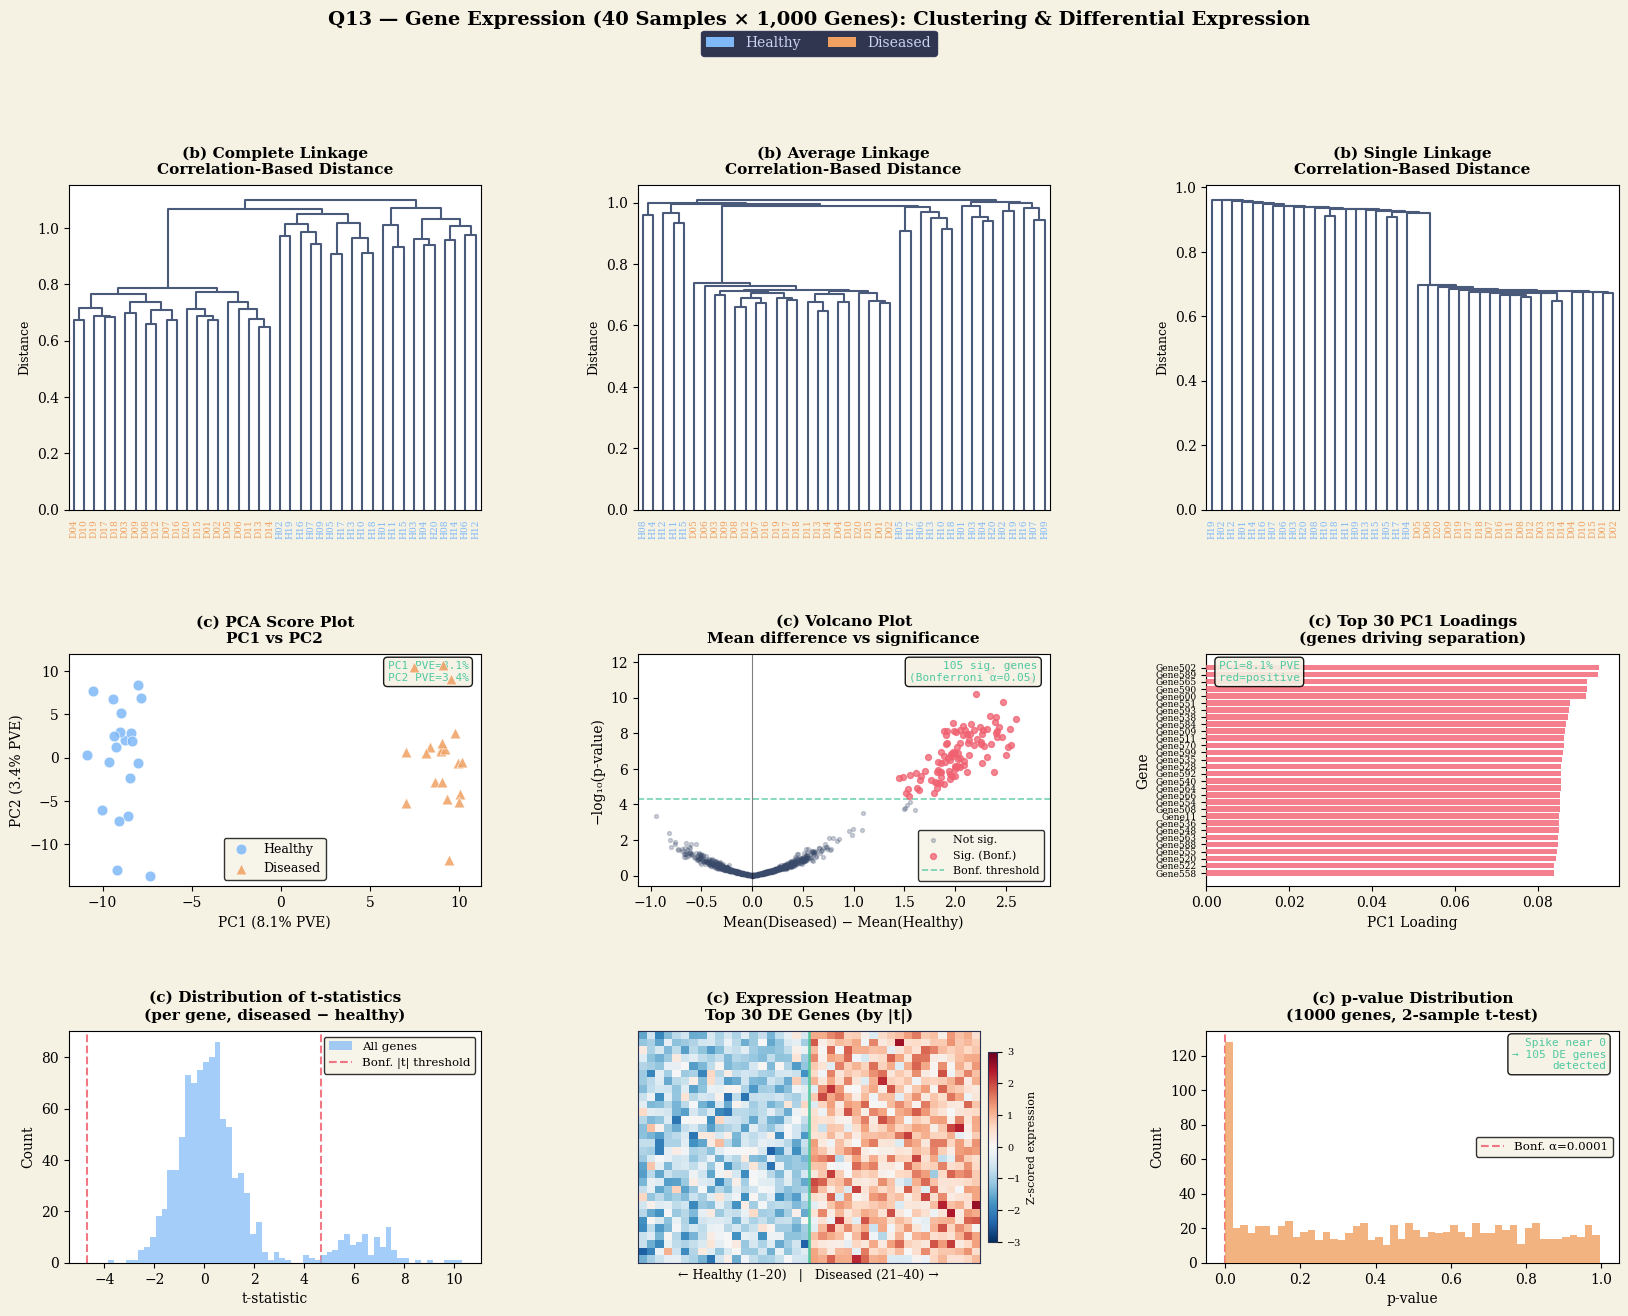

In [19]:
"""
ISLP Chapter 12 — Question 13
Gene Expression Data: Ch12Ex13.csv
40 tissue samples × 1,000 genes
  - Samples 1–20:  healthy patients
  - Samples 21–40: diseased patients

(a) Load data
(b) Hierarchical clustering with correlation-based distance; compare linkages
(c) Identify genes that differ most between the two groups (PCA loadings + t-test)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ══════════════════════════════════════════════════════════════
# (a) Load data from data/Ch12Ex13.csv
# ══════════════════════════════════════════════════════════════
# The dataset Ch12Ex13.csv has:
#   • 1000 rows  (genes)
#   • 40 columns (samples)
#   • No header
# After loading, transpose so rows = samples, cols = genes.

df_raw = pd.read_csv("../data/Ch12Ex13.csv", header=None)

# Transpose so rows = samples, columns = genes
df = df_raw.T

# Optional: assign gene names for clarity
df.columns = [f"Gene{i+1}" for i in range(df.shape[1])]

# Define group sizes (first 20 healthy, last 20 diseased)
n_samples  = df.shape[0]
n_genes    = df.shape[1]
n_healthy  = 20
n_diseased = 20

print("=" * 62)
print("  Q13 — Gene Expression Analysis")
print("=" * 62)
print(f"\n(a) Data shape: {df.shape}  (samples × genes)")
print(f"    Samples 1–20 : healthy\n    Samples 21–40: diseased")

X_mat     = df.values                    # (40, 1000)  samples × genes
true_label = np.array(["Healthy"]*n_healthy + ["Diseased"]*n_diseased)
sample_ids = [f"H{i+1:02d}" for i in range(n_healthy)] + \
             [f"D{i+1:02d}" for i in range(n_diseased)]

# ══════════════════════════════════════════════════════════════
# (b) Hierarchical clustering with correlation-based distance
# ══════════════════════════════════════════════════════════════
# Correlation-based distance: d(i,j) = 1 - corr(x_i, x_j)
# Computed across the gene axis (each row = one sample's 1000 gene values)

corr_matrix = np.corrcoef(X_mat)          # (40, 40) sample–sample correlation
dist_matrix = 1 - corr_matrix             # correlation distance
# scipy linkage needs condensed distance vector (upper triangle)
from scipy.spatial.distance import squareform
dist_condensed = squareform(dist_matrix, checks=False)

linkage_methods = ["complete", "average", "single"]
Z_dict = {m: linkage(dist_condensed, method=m) for m in linkage_methods}

# Check separation: cut each dendrogram to 2 clusters
from scipy.cluster.hierarchy import fcluster
print("\n(b) Cluster separation (cut to 2 clusters):")
for m, Z in Z_dict.items():
    labels = fcluster(Z, t=2, criterion="maxclust")
    healthy_in_c1  = np.sum((labels[:n_healthy] == 1))
    diseased_in_c1 = np.sum((labels[n_healthy:] == 1))
    healthy_in_c2  = np.sum((labels[:n_healthy] == 2))
    diseased_in_c2 = np.sum((labels[n_healthy:] == 2))
    separation = "PERFECT" if (
        (healthy_in_c1==n_healthy and diseased_in_c1==0) or
        (healthy_in_c2==n_healthy and diseased_in_c2==0)
    ) else f"H:{healthy_in_c1}+{healthy_in_c2}  D:{diseased_in_c1}+{diseased_in_c2}"
    print(f"  {m:10s}: {separation}")

# ══════════════════════════════════════════════════════════════
# (c) Genes that differ most between the two groups
#
# Two complementary approaches:
#   1. Two-sample t-test (per gene) — identifies statistically significant DE
#   2. PCA: genes with largest absolute loadings on PC1 drive the
#      separation and are the most "informative" genes
# ══════════════════════════════════════════════════════════════

# --- Approach 1: t-test per gene ---
healthy_mat  = X_mat[:n_healthy,  :]     # (20, 1000)
diseased_mat = X_mat[n_healthy:,  :]     # (20, 1000)

t_stats, p_vals = ttest_ind(diseased_mat, healthy_mat, axis=0)
# Multiple-testing correction: Bonferroni
alpha   = 0.05
bonf_thresh = alpha / n_genes
n_sig   = np.sum(p_vals < bonf_thresh)
top_ttest_idx = np.argsort(np.abs(t_stats))[::-1][:20]   # top 20 by |t|

print(f"\n(c) Gene identification:")
print(f"  t-test: {n_sig} genes significant after Bonferroni correction "
      f"(α={alpha}/1000={bonf_thresh:.5f})")
print(f"  Top 10 genes by |t-statistic|:")
for rank, gi in enumerate(top_ttest_idx[:10], 1):
    print(f"    {rank:2d}. Gene{gi+1:4d}  "
          f"t={t_stats[gi]:+.3f}  "
          f"p={p_vals[gi]:.2e}")

# --- Approach 2: PCA loadings ---
# Standardise genes (column-wise) before PCA
X_sc  = StandardScaler().fit_transform(X_mat)    # (40, 1000)
pca   = PCA(n_components=5)
Z_pca = pca.fit_transform(X_sc)
pve   = pca.explained_variance_ratio_

print(f"\n  PCA: PC1 explains {pve[0]:.1%} of variance")
# Genes with largest |loading| on PC1 drive sample separation
pc1_loadings = pca.components_[0]                # (1000,)
top_pca_idx  = np.argsort(np.abs(pc1_loadings))[::-1][:20]
print(f"  Top 10 genes by |PC1 loading|:")
for rank, gi in enumerate(top_pca_idx[:10], 1):
    print(f"    {rank:2d}. Gene{gi+1:4d}  loading={pc1_loadings[gi]:+.4f}")

# Overlap between methods
overlap = set(top_ttest_idx[:20]) & set(top_pca_idx[:20])
print(f"\n  Overlap (top-20 t-test ∩ top-20 PCA): {len(overlap)} genes")


# ══════════════════════════════════════════════════════════════
# Figure
# ══════════════════════════════════════════════════════════════
BG, PANEL, GRID     = "#f5f2e4", "#ffffff", "#ffffff"
TITLE, TICK         = "#000000", "#000000"
BLUE, ORANGE, GREEN = "#7eb8f7", "#f0a060", "#50c8a0"
PURPLE, RED         = "#c07ef0", "#f06070"

H_COL = BLUE        # healthy
D_COL = ORANGE      # diseased
LINKAGE_COLS = {"complete": BLUE, "average": GREEN, "single": ORANGE}

plt.rcParams.update({
    "font.family": "serif", "axes.facecolor": PANEL,
    "figure.facecolor": BG, "axes.edgecolor": "#2a3050",
    "axes.labelcolor": TICK, "xtick.color": TICK, "ytick.color": TICK,
    "grid.color": GRID, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "text.color": "#c8d4f0",
})

def style(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=11, color=TITLE, fontweight="bold", pad=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=10, color=TICK)
    if ylabel: ax.set_ylabel(ylabel, fontsize=10, color=TICK)
    ax.grid(True, alpha=0.4); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#000000")

def ibox(ax, txt, loc="upper right"):
    ha = "right" if "right" in loc else "left"
    x  = 0.97 if ha == "right" else 0.03
    ax.text(x, 0.97, txt, transform=ax.transAxes, va="top", ha=ha,
            fontsize=8, fontfamily="monospace", color=GREEN,
            bbox=dict(boxstyle="round,pad=0.35", fc="#f5f2e4",
                      ec="#000000", alpha=0.9))

def colour_dendrogram_leaves(ax, Z, sample_ids, true_label):
    """Colour leaf tick labels by true group."""
    ddata = dendrogram(Z, no_plot=True)
    order = ddata["leaves"]
    xlbls = ax.get_xticklabels()
    for lbl in xlbls:
        txt  = lbl.get_text()
        if txt in sample_ids:
            idx = sample_ids.index(txt)
            lbl.set_color(H_COL if true_label[idx] == "Healthy" else D_COL)
            lbl.set_fontsize(6.5)

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.55, wspace=0.38,
                        height_ratios=[1.4, 1, 1])

# ── Panels (0,0)–(0,2): one dendrogram per linkage method ─────
for col_idx, method in enumerate(linkage_methods):
    ax = fig.add_subplot(gs[0, col_idx])
    Z  = Z_dict[method]
    dendrogram(
        Z, labels=sample_ids, ax=ax,
        color_threshold=0,
        above_threshold_color="#4a5a7a",
        link_color_func=lambda k: "#4a5a7a",
        leaf_rotation=90, leaf_font_size=6.5,
    )
    colour_dendrogram_leaves(ax, Z, sample_ids, true_label)
    ax.set_title(f"(b) {method.capitalize()} Linkage\n"
                 f"Correlation-Based Distance",
                 fontsize=11, color=TITLE, fontweight="bold", pad=8)
    ax.set_ylabel("Distance", fontsize=9, color=TICK)
    ax.grid(True, alpha=0.35, axis="y"); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor("#000000")

from matplotlib.patches import Patch
legend_els = [Patch(fc=H_COL, label="Healthy"),
              Patch(fc=D_COL, label="Diseased")]
fig.legend(handles=legend_els, loc="upper center", ncol=2,
           fontsize=10, facecolor="#1a2040", edgecolor="#2a3050",
           labelcolor="#c8d4f0", framealpha=0.9,
           bbox_to_anchor=(0.5, 0.995))

# ── Panel (1,0): PC1 vs PC2 scatter ───────────────────────────
ax_pca = fig.add_subplot(gs[1, 0])
for lbl, col, mk in [("Healthy", H_COL, "o"), ("Diseased", D_COL, "^")]:
    sel = true_label == lbl
    ax_pca.scatter(Z_pca[sel, 0], Z_pca[sel, 1], c=col, marker=mk,
                   s=60, alpha=0.85, edgecolors="white", lw=0.5,
                   label=lbl, zorder=4)
style(ax_pca, "(c) PCA Score Plot\nPC1 vs PC2",
      f"PC1 ({pve[0]:.1%} PVE)", f"PC2 ({pve[1]:.1%} PVE)")
ax_pca.legend(fontsize=9, facecolor="#f5f2e4", edgecolor="#000000",
              labelcolor="#000000")
ibox(ax_pca, f"PC1 PVE={pve[0]:.1%}\nPC2 PVE={pve[1]:.1%}")

# ── Panel (1,1): volcano plot (t-test) ────────────────────────
ax_vol = fig.add_subplot(gs[1, 1])
mean_diff = diseased_mat.mean(0) - healthy_mat.mean(0)
neg_log_p = -np.log10(np.clip(p_vals, 1e-300, 1))
sig_mask  = p_vals < bonf_thresh
ax_vol.scatter(mean_diff[~sig_mask], neg_log_p[~sig_mask],
               c="#3a4a6a", alpha=0.25, s=8, zorder=2, label="Not sig.")
ax_vol.scatter(mean_diff[sig_mask],  neg_log_p[sig_mask],
               c=RED, alpha=0.75, s=18, zorder=3, label=f"Sig. (Bonf.)")
ax_vol.axhline(-np.log10(bonf_thresh), color=GREEN, lw=1.2,
               ls="--", alpha=0.8, label=f"Bonf. threshold")
ax_vol.axvline(0, color=TICK, lw=0.8, alpha=0.5)
style(ax_vol, "(c) Volcano Plot\nMean difference vs significance",
      "Mean(Diseased) − Mean(Healthy)", "−log₁₀(p-value)")
ax_vol.legend(fontsize=8, facecolor="#f5f2e4", edgecolor="#000000",
              labelcolor="#000000")
ibox(ax_vol, f"{n_sig} sig. genes\n(Bonferroni α=0.05)")

# ── Panel (1,2): PC1 loadings bar (top 30) ────────────────────
ax_load = fig.add_subplot(gs[1, 2])
top30   = np.argsort(np.abs(pc1_loadings))[::-1][:30]
vals    = pc1_loadings[top30]
cols    = [RED if v > 0 else BLUE for v in vals]
ax_load.barh(range(30), vals[::-1],
             color=cols[::-1], alpha=0.80, zorder=3)
ax_load.set_yticks(range(30))
ax_load.set_yticklabels(
    [f"Gene{top30[29-i]+1}" for i in range(30)], fontsize=6.5)
ax_load.axvline(0, color=TICK, lw=0.8, alpha=0.5)
style(ax_load, "(c) Top 30 PC1 Loadings\n(genes driving separation)",
      "PC1 Loading", "Gene")
ibox(ax_load, f"PC1={pve[0]:.1%} PVE\nred=positive", loc="upper left")

# ── Panel (2,0): t-statistic distribution ─────────────────────
ax_hist = fig.add_subplot(gs[2, 0])
ax_hist.hist(t_stats, bins=60, color=BLUE, alpha=0.70,
             edgecolor="none", zorder=3, label="All genes")
t_thresh = np.sort(np.abs(t_stats[sig_mask]))[0] if n_sig > 0 else 6
ax_hist.axvline( t_thresh, color=RED, lw=1.5, ls="--",
                 alpha=0.85, label="Bonf. |t| threshold")
ax_hist.axvline(-t_thresh, color=RED, lw=1.5, ls="--", alpha=0.85)
style(ax_hist, "(c) Distribution of t-statistics\n(per gene, diseased − healthy)",
      "t-statistic", "Count")
ax_hist.legend(fontsize=8.5, facecolor="#f5f2e4", edgecolor="#000000",
               labelcolor="#000000")

# ── Panel (2,1): heatmap top-30 t-test genes × all samples ───
ax_heat = fig.add_subplot(gs[2, 1])
top30_t = np.argsort(np.abs(t_stats))[::-1][:30]
heat_data = X_mat[:, top30_t].T          # (30, 40)
# Normalise each gene to [-1,1] for display
heat_norm = (heat_data - heat_data.mean(1, keepdims=True))
heat_norm /= (heat_norm.std(1, keepdims=True) + 1e-9)
im = ax_heat.imshow(heat_norm, cmap="RdBu_r", aspect="auto",
                    vmin=-3, vmax=3)
ax_heat.axvline(n_healthy - 0.5, color=GREEN, lw=2, alpha=0.9)
ax_heat.set_xticks([]); ax_heat.set_yticks([])
ax_heat.set_xlabel("← Healthy (1–20)   |   Diseased (21–40) →",
                   fontsize=9, color=TICK)
ax_heat.set_title("(c) Expression Heatmap\nTop 30 DE Genes (by |t|)",
                  fontsize=11, color=TITLE, fontweight="bold", pad=8)
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.82, pad=0.02)
cbar.ax.tick_params(colors=TICK, labelsize=7)
cbar.set_label("Z-scored expression", color=TICK, fontsize=8)
for sp in ax_heat.spines.values(): sp.set_edgecolor("#2a3050")

# ── Panel (2,2): p-value distribution ────────────────────────
ax_pv = fig.add_subplot(gs[2, 2])
ax_pv.hist(p_vals, bins=50, color=ORANGE, alpha=0.80,
           edgecolor="none", zorder=3)
ax_pv.axvline(bonf_thresh, color=RED, lw=1.5, ls="--",
              alpha=0.85, label=f"Bonf. α={bonf_thresh:.4f}")
style(ax_pv, "(c) p-value Distribution\n(1000 genes, 2-sample t-test)",
      "p-value", "Count")
ax_pv.legend(fontsize=8.5, facecolor="#f5f2e4", edgecolor="#000000",
             labelcolor="#000000")
# Anti-conservative spike near 0 indicates truly DE genes
ibox(ax_pv, f"Spike near 0\n→ {n_sig} DE genes\ndetected")

fig.suptitle(
    "Q13 — Gene Expression (40 Samples × 1,000 Genes): "
    "Clustering & Differential Expression",
    fontsize=14, fontweight="bold", color=TITLE, y=1.005,
)
plt.savefig("gene_expression_q13.png",
            dpi=180, bbox_inches="tight", facecolor=BG)
print("\nSaved gene_expression_q13.png")
plt.show()